<a href="https://colab.research.google.com/github/kecosz/FASTexELA/blob/main/amed_FAST_rELA0_74_2__genus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Codes for Suzuki et al. "Major microbiota transitions across liver disease progression are linked by key mediator taxa connecting host environments and microbial community structures"


**\*\*This notebool performs genus-level analysis\*\***

This Colab notebook performs the analysis by cloning a GitHub repository that contains the required data, package files, support scripts, and related resources.

The notebook can be run in a standard Google Colab runtime. However, it is primarily intended to be executed in a local runtime with sufficient computational resources. When using the standard Colab runtime, some computationally intensive steps may take a long time to complete.

For instructions on how to use a local runtime, please refer to the following page:

https://research.google.com/colaboratory/local-runtimes.html

## Environment setup

In [ ]:
# Mount Google Drive and load data
## Google Drive cannot be mounted in Local Runtime.
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
from IPython.display import Image, display

In [ ]:
## rpy2 version specification
### Required to successfully execute "%load_ext rpy2.ipython" as of 2023/1
!pip install rpy2==3.5.1
#!pip install --upgrade ipykernel
%load_ext rpy2.ipython

###The following codes is just for not showing rpy2 messages related to R package installation on google colab
from rpy2.rinterface_lib.callbacks import logger as rpy2_logger
import logging
rpy2_logger.setLevel(logging.ERROR)   # will display errors, but not warnings

## Doanload rELA package
!git clone https://github.com/kecosz/FASTexELA.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.7/201.7 kB 11.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rpy2: filename=rpy2-3.5.1-cp312-cp312-linux_x86_64.whl size=316570 sha256=9733dda48f9e6b094e184e96e70d7e336f40fd1294626c04a7fe395e16bab7b4
  Stored in directory: /root/.cache/pip/wheels/00/26/d5/d5e8c0b039915e785be870270e4a9263e5058168a03513d8cc
Successfully built rpy2
  Attempting uninstall: rpy2
    Found existing installation: rpy2 3.5.17
    Uninstalling rpy2-3.5.17:
      Successfully uninstalled rpy2-3.5.17
Cloning into 'FASTexELA'...
remote: Enumerating objects: 155, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 155 (delta 52), reused 38 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (155/155), 41.01 MiB | 18.30 MiB/s, done.
Resolving deltas: 100% (52/52), done.


In [ ]:
%%R
## package instllation
install.packages("Rcpp")
install.packages("RcppArmadillo")
install.packages("doParallel")
install.packages('tidyverse')
install.packages('gsubfn')
install.packages('zoo')
install.packages('dplyr')
install.packages('tidyr')
install.packages('ggplot2')
install.packages('gtools')
install.packages('ggsci')
install.packages('igraph')
install.packages('tidygraph')
install.packages('RColorBrewer')
install.packages("stringdist")
install.packages("purrr")
install.packages("plot3D")
install.packages("devtools")
library("Rcpp")
library("RcppArmadillo")
library("doParallel")
library('tidyverse')
library('gsubfn')
library('zoo')
library('dplyr')
library('tidyr')
library('ggplot2')
library('gtools')
library('ggsci')
library('igraph')
library('tidygraph')
library('RColorBrewer')
library("stringdist")
library("purrr")
library("plot3D")
library("devtools")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ purrr::accumulate() masks foreach::accumulate()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
✖ purrr::when()       masks foreach::when()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

In [ ]:
!ls FASTexELA

amed_FAST_rELA0_74_2_.ipynb   rds			results
data			      README.md
ela_fast_support_functions.R  rELA.v0.74.2_fast.tar.gz


In [ ]:
%%R
install.packages("FASTexELA/rELA.v0.74.2_fast.tar.gz",type = "source")
#install_local("FASTexELA/rEL/rELA.v0.74.2.tar.gz",type="source")

library("rELA")

In [ ]:
%%R
source("FASTexELA/ela_fast_support_functions.R")
install_ela_visualization_dependencies()
load_ela_visualization_packages()

Create a folder for saving results.

In [ ]:
%%R
out <- "outputs"

if (!dir.exists(out)) {
  dir.create(out, recursive = TRUE)
}

In [ ]:
# for python
out = "outputs/"

## Data preparation


In [ ]:
#%%R
#baseabtable <- read.csv('/content/drive/MyDrive/data/amed/080823/level-7e.csv', sep=',', fileEncoding='utf-8') %>%
#  column_to_rownames(., var = "index")
#basemetadata <- read.csv('/content/drive/MyDrive/data/amed/080823/metadata_080823.csv', sep=',', fileEncoding='utf-8') %>%
#  column_to_rownames(., var = "Name")

In [ ]:
%%R
# use mouted local drive
baseabtable <- read.csv('FASTexELA/data/abundance_table_fast.csv', sep=',', fileEncoding='utf-8') %>%
  column_to_rownames(., var = "index")
baseabtable_g <- read.csv('FASTexELA/data/abundance_table_fast_genus.csv', sep=',', fileEncoding='utf-8') %>%
  column_to_rownames(., var = "index")
basemetadata <- read.csv('FASTexELA/data/metadata_fast.csv', sep=',', fileEncoding='utf-8') %>%
  column_to_rownames(., var = "Name")

In [ ]:
%%R
readcounts <- rowSums(baseabtable)

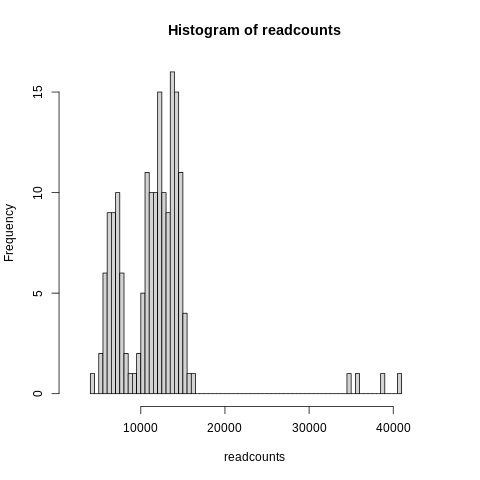

In [ ]:
%%R
hist(readcounts, xlim = c(2000, 45000), breaks = 100)

fitting ...
  |======================================================================| 100%
  gmm_cluster   n
1           1   4
2           2 121
3           3  46
Selected number of GMM clusters: 3 
Selected covariance model: EEE 


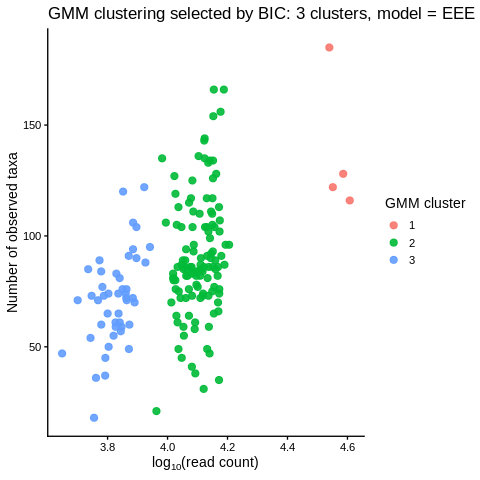

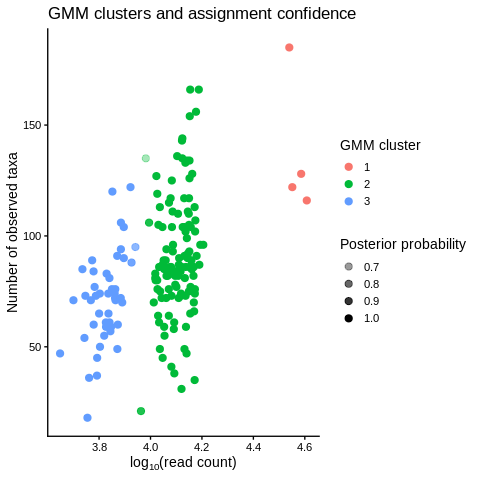

In [ ]:
%%R
## ------------------------------------------------------------
## GMM clustering of read count x observed taxa using BIC
## ------------------------------------------------------------

## Install packages if needed
if (!requireNamespace("mclust", quietly = TRUE)) install.packages("mclust")
if (!requireNamespace("ggplot2", quietly = TRUE)) install.packages("ggplot2")

library(mclust)
library(ggplot2)

## ------------------------------------------------------------
## 1. Prepare data
## ------------------------------------------------------------
nonzero_counts <- apply(baseabtable, 1, function(row) sum(row != 0))
qc_df <- data.frame(
  sample_id = if (!is.null(names(readcounts))) names(readcounts) else seq_along(readcounts),
  read_count = as.numeric(readcounts),
  observed_taxa = as.numeric(nonzero_counts),
  stringsAsFactors = FALSE
)

## Remove invalid rows
qc_df <- qc_df[
  !is.na(qc_df$read_count) &
    !is.na(qc_df$observed_taxa) &
    qc_df$read_count > 0,
]

rownames(qc_df) <- qc_df$sample_id

## log10-transform read count
qc_df$log10_read_count <- log10(qc_df$read_count)

## Standardize variables for GMM fitting
qc_scaled <- scale(qc_df[, c("log10_read_count", "observed_taxa")])

## ------------------------------------------------------------
## 2. Fit GMM and select model by BIC
## ------------------------------------------------------------

set.seed(123)

gmm_fit <- Mclust(
  data = qc_scaled,
  G = 1:6
)

## Show selected model
summary(gmm_fit)

## Add GMM cluster assignments
qc_df$gmm_cluster <- factor(gmm_fit$classification)

## Add posterior probability and uncertainty for diagnostics
qc_df$gmm_max_posterior <- apply(gmm_fit$z, 1, max)
qc_df$gmm_uncertainty <- gmm_fit$uncertainty

## ------------------------------------------------------------
## 3. Cluster summary
## ------------------------------------------------------------

cluster_summary <- as.data.frame(table(qc_df$gmm_cluster))
colnames(cluster_summary) <- c("gmm_cluster", "n")

print(cluster_summary)

write.csv(
  qc_df,
  file.path(out, "GMM_cluster_assignment.csv"),
  row.names = FALSE
)

write.csv(
  cluster_summary,
  file.path(out, "GMM_cluster_summary.csv"),
  row.names = FALSE
)

cat("Selected number of GMM clusters:", gmm_fit$G, "\n")
cat("Selected covariance model:", gmm_fit$modelName, "\n")

## ------------------------------------------------------------
## 4. Plot BIC values
## ------------------------------------------------------------

png(file.path(out, "GMM_BIC_plot.png"), width = 1800, height = 1400, res = 300)
plot(gmm_fit, what = "BIC")
dev.off()

## ------------------------------------------------------------
## 5. Visualize GMM clusters on original interpretable axes
## ------------------------------------------------------------

p_gmm <- ggplot(
  qc_df,
  aes(
    x = log10_read_count,
    y = observed_taxa,
    color = gmm_cluster
  )
) +
  geom_point(size = 3, alpha = 0.9) +
  labs(
    x = expression(log[10] * "(read count)"),
    y = "Number of observed taxa",
    color = "GMM cluster",
    title = paste0(
      "GMM clustering selected by BIC: ",
      gmm_fit$G, " clusters, model = ", gmm_fit$modelName
    )
  ) +
  theme_classic(base_size = 14)

print(p_gmm)

ggsave(
  filename = file.path(out, "GMM_BIC_clustered.png"),
  plot = p_gmm,
  width = 6.5,
  height = 5.5,
  dpi = 300
)

## ------------------------------------------------------------
## 6. Optional: visualize posterior assignment confidence
## ------------------------------------------------------------

p_gmm_confidence <- ggplot(
  qc_df,
  aes(
    x = log10_read_count,
    y = observed_taxa,
    color = gmm_cluster,
    alpha = gmm_max_posterior
  )
) +
  geom_point(size = 3) +
  scale_alpha_continuous(range = c(0.35, 1)) +
  labs(
    x = expression(log[10] * "(read count)"),
    y = "Number of observed taxa",
    color = "GMM cluster",
    alpha = "Posterior probability",
    title = "GMM clusters and assignment confidence"
  ) +
  theme_classic(base_size = 14)

print(p_gmm_confidence)

ggsave(
  filename = file.path(out, "GMM_BIC_clustered_with_posterior.png"),
  plot = p_gmm_confidence,
  width = 6.5,
  height = 5.5,
  dpi = 300
)

In [ ]:
%%R
## ------------------------------------------------------------
## GMM-based outlier flag
## Retain the largest GMM cluster and exclude smaller clusters
## ------------------------------------------------------------

## GMM cluster assignment
gmm_cluster <- gmm_fit$classification

## sample labels
names(gmm_cluster) <- qc_df$sample_id

## Count samples in each GMM cluster
gmm_cluster_sizes <- table(gmm_cluster)

print(gmm_cluster_sizes)

## Identify the largest GMM cluster
largest_gmm_cluster <- as.numeric(names(gmm_cluster_sizes)[which.max(gmm_cluster_sizes)])

cat("Largest GMM cluster:", largest_gmm_cluster, "\n")

## Create outlier flag
## 0 = retained
## 1 = excluded
outlier_flag_gmm <- ifelse(
  gmm_cluster == largest_gmm_cluster,
  0,
  1
)

## Add sample labels
names(outlier_flag_gmm) <- names(gmm_cluster)

## Show result
outlier_flag_gmm

## Check numbers
table(outlier_flag_gmm)

gmm_cluster
  1   2   3 
  4 121  46 
Largest GMM cluster: 2 
outlier_flag_gmm
  0   1 
121  50 


In [ ]:
%%R
## ------------------------------------------------------------
## Test whether FAST_score differs among GMM clusters
## ------------------------------------------------------------

## gmm_cluster: named vector
## basemetadata: data frame with rownames = sample IDs and column FAST_score

# Match sample IDs between gmm_cluster and basemetadata
common_ids <- intersect(names(gmm_cluster), rownames(basemetadata))

# Build analysis data frame
df_gmm_fast <- data.frame(
  sample_id = common_ids,
  gmm_cluster = factor(gmm_cluster[common_ids]),
  FAST_score = as.numeric(basemetadata[common_ids, "FAST_score"]),
  stringsAsFactors = FALSE
)

# Remove samples with missing FAST_score
df_gmm_fast <- df_gmm_fast[!is.na(df_gmm_fast$FAST_score), , drop = FALSE]

# Check sample size per cluster
table(df_gmm_fast$gmm_cluster)

# Summary statistics
aggregate(
  FAST_score ~ gmm_cluster,
  data = df_gmm_fast,
  FUN = function(x) {
    c(
      n = length(x),
      mean = mean(x),
      sd = sd(x),
      median = median(x),
      IQR = IQR(x)
    )
  }
)

# Kruskal-Wallis test
kw_res <- kruskal.test(
  FAST_score ~ gmm_cluster,
  data = df_gmm_fast
)

print(kw_res)

# Simple interpretation
if (kw_res$p.value < 0.05) {
  message(
    "FAST_score differs significantly among GMM clusters: p = ",
    signif(kw_res$p.value, 3)
  )
} else {
  message(
    "No significant difference in FAST_score was detected among GMM clusters: p = ",
    signif(kw_res$p.value, 3)
  )
}


	Kruskal-Wallis rank sum test

data:  FAST_score by gmm_cluster
Kruskal-Wallis chi-squared = 3.6686, df = 2, p-value = 0.1597



In [ ]:
%%R
shorten_genus_labels <- function(taxon_vec, make_unique = TRUE) {
  raw_labels <- sapply(taxon_vec, function(label) {
    label <- as.character(label)
    label <- sub("__$", "__uc", label)

    parts <- unlist(strsplit(label, "(^|\\.)[dpcofgs]__"))
    parts <- parts[parts != ""]
    if (length(parts) == 0) return(NA_character_)

    parts_rev <- rev(parts)

    invalids <- c("uncultured", "human_gut", "gut_metagenome", "unclassified")

    is_valid <- function(x) {
      x <- gsub("__", "", x)
      x <- sub("^\\.", "", x)
      !(nchar(x) <= 4 || tolower(x) %in% invalids)
    }

    valid_pos <- which(sapply(parts_rev, is_valid))
    if (length(valid_pos) == 0) return(NA_character_)

    keep_parts <- parts_rev[1:valid_pos[1]]

    final <- paste(rev(keep_parts), collapse = ".")
    final <- gsub("__", "", final)
    final <- sub("^\\.", "", final)
    final <- gsub("\\.{2,}", ".", final)

    final
  }, USE.NAMES = FALSE)

  if (!make_unique) return(raw_labels)

  counts <- ave(seq_along(raw_labels), raw_labels, FUN = seq_along)

  ifelse(
    is.na(raw_labels),
    NA_character_,
    ifelse(counts == 1, raw_labels, paste0(raw_labels, ".", counts))
  )
}

Apply short taxon name

In [ ]:
%%R
colnames(baseabtable_g) <- shorten_genus_labels(colnames(baseabtable_g))

Data formatting for data analysis

In [ ]:
%%R
# To group species with the same presence/absence pattern into one group,
#set grouping to 1 and specify a number between 0 and 1 for grouping_th.
# If 0, only species with the same presence/absence pattern will be grouped together.
## Make sure that the same classification labels do not appear in the abundance table. ##
list[ocmat, abmat, enmat, samplelabel, specieslabel, factorlabel, group_table] <-
  Formatting(baseabtable_g, basemetadata, normalize=1, parameters=c(0.01, 0.05, 0.95, 0.05), grouping=1, grouping_th=0.)

Processed 171 samples.
Threshold method: global 
Threshold value (ath): 0.01 
Occurrence threshold range: 0.05 ~ 0.95 
0  groups were found.
Selected 41 of 303 species.


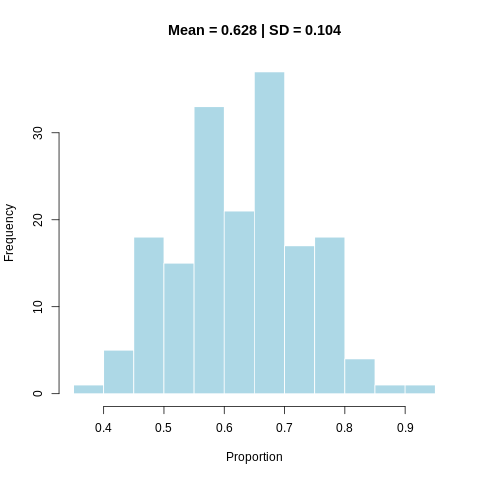

In [ ]:
%%R
# calculate taxon cover
ratios <- apply(baseabtable_g, 1, function(row) {
  sum(row[specieslabel]) / sum(row)
})
hist(ratios,
     main = paste("Mean =", round(mean(ratios), 3),
                  "| SD =", round(sd(ratios), 3)),
     xlab = "Proportion",
     col = "lightblue",
     border = "white")

pick up FAST_score and PPI row and combine as a new matrix

In [ ]:
%%R
enmat_p <- data.frame(FAST_score = scale(as.numeric(enmat[, 1]) ** 0.5), PPI = as.numeric(enmat[, 2]), outlier_flag = outlier_flag_gmm)
rownames(enmat_p) <- samplelabel

In [ ]:
%%R
print(0.33**0.5)
print(0.67**0.5)

[1] 0.5744563
[1] 0.8185353


In [ ]:
%%R
mm <- as.numeric(enmat[, 1])**0.5
(c(0.574, 0.8185) - mean(mm[!is.na(mm)]))/(sd(mm[!is.na(mm)]))

[1] 0.1612675 1.2131652


**Since the distribution is flatter than the raw values, the square root of FAST_score is used for analysis.**

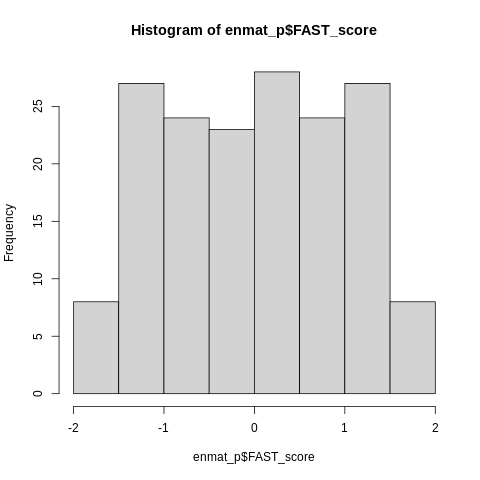

In [ ]:
%%R
hist(enmat_p$FAST_score)

In [ ]:
%%R
dim(enmat_p)

[1] 171   3


remove FAST_score=NA and PPI=1

In [ ]:
%%R
print(length(enmat_p[,2]) - sum(enmat_p[, 2] == 0))
print(length(enmat_p[,3]) - sum(enmat_p[, 3] == 0))

[1] 22
[1] 50


In [ ]:
%%R
rows_to_keep <- !is.na(enmat_p[, 1]) & enmat_p[, 2] == 0 & enmat_p[, 3] == 0

# remove the corresponding columns from data matrices
enmat_p_filtered <- enmat_p[rows_to_keep, ]
enmat_fastscore_filtered <- as.matrix(enmat_p_filtered[, 1, drop = FALSE])
enmat_fastscore_filtered <- ceiling(10*enmat_fastscore_filtered)/10 ####
ocmat_filtered <- ocmat[rows_to_keep, , drop = FALSE]
abmat_filtered <- abmat[rows_to_keep, , drop = FALSE]
samplelabel_filtered <- samplelabel[rows_to_keep]

In [ ]:
%%R
## ------------------------------------------------------------
## Prepare logical flags from enmat_p
## enmat_p columns:
##   [,1] = FAST score
##   [,2] = PPI
##   [,3] = outlier_flag
## ------------------------------------------------------------

sample_ids <- if (!is.null(rownames(enmat_p))) {
  rownames(enmat_p)
} else {
  paste0("Sample_", seq_len(nrow(enmat_p)))
}

filter_df <- data.frame(
  sample_id = sample_ids,
  FAST_missing     = is.na(enmat_p[, 1]),
  PPI_excluded     = is.na(enmat_p[, 2]) | enmat_p[, 2] != 0,
  Outlier_excluded = is.na(enmat_p[, 3]) | enmat_p[, 3] != 0,
  stringsAsFactors = FALSE
)

## Final inclusion flag
filter_df$rows_to_keep <- !filter_df$FAST_missing &
                          !filter_df$PPI_excluded &
                          !filter_df$Outlier_excluded

## Check counts
cat("Total samples:", nrow(filter_df), "\n")
cat("Included samples:", sum(filter_df$rows_to_keep), "\n")
cat("Excluded samples:", sum(!filter_df$rows_to_keep), "\n")

## Optional: inspect table
print(head(filter_df))

Total samples: 171 
Included samples: 106 
Excluded samples: 65 
  sample_id FAST_missing PPI_excluded Outlier_excluded rows_to_keep
1      F286        FALSE        FALSE            FALSE         TRUE
2      F287        FALSE        FALSE            FALSE         TRUE
3      F288        FALSE         TRUE            FALSE        FALSE
4      F289        FALSE         TRUE            FALSE        FALSE
5      F290        FALSE        FALSE            FALSE         TRUE
6      F300        FALSE        FALSE             TRUE        FALSE


FAST_available       PPI_free    Non_outlier   rows_to_keep 
           169            149            121            106 

FALSE  TRUE 
   65   106 
  FAST_available PPI_free Non_outlier Freq combination_id
1          FALSE    FALSE       FALSE    2              1
2           TRUE    FALSE       FALSE    5              2
4           TRUE     TRUE       FALSE   43              3
6           TRUE    FALSE        TRUE   15              4
8           TRUE     TRUE        TRUE  106              5
                              combination_label   status
1 FAST=FALSE\nPPI-free=FALSE\nNon-outlier=FALSE Excluded
2  FAST=TRUE\nPPI-free=FALSE\nNon-outlier=FALSE Excluded
4   FAST=TRUE\nPPI-free=TRUE\nNon-outlier=FALSE Excluded
6   FAST=TRUE\nPPI-free=FALSE\nNon-outlier=TRUE Excluded
8    FAST=TRUE\nPPI-free=TRUE\nNon-outlier=TRUE Retained
[1] TRUE
[1] 147240


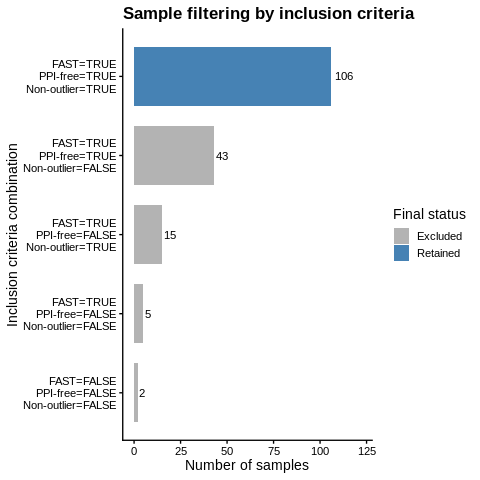

In [ ]:
%%R

library(ggplot2)

## ------------------------------------------------------------
## 1. Prepare condition table
## ------------------------------------------------------------

sample_ids <- rownames(enmat_p)
if (is.null(sample_ids)) {
  sample_ids <- paste0("S", seq_len(nrow(enmat_p)))
}

cond_df <- data.frame(
  sample_id = sample_ids,
  FAST_available = !is.na(enmat_p[, 1]),
  PPI_free       = !is.na(enmat_p[, 2]) & enmat_p[, 2] == 0,
  Non_outlier    = !is.na(enmat_p[, 3]) & enmat_p[, 3] == 0,
  stringsAsFactors = FALSE
)

cond_df$rows_to_keep <- with(
  cond_df,
  FAST_available & PPI_free & Non_outlier
)

print(colSums(cond_df[, c("FAST_available", "PPI_free", "Non_outlier", "rows_to_keep")]))
print(table(cond_df$rows_to_keep))

## ------------------------------------------------------------
## 2. Count all condition combinations
## ------------------------------------------------------------

comb_table <- as.data.frame(table(
  FAST_available = cond_df$FAST_available,
  PPI_free       = cond_df$PPI_free,
  Non_outlier    = cond_df$Non_outlier
))

comb_table <- comb_table[comb_table$Freq > 0, ]

comb_table$combination_id <- seq_len(nrow(comb_table))

comb_table$combination_label <- paste0(
  "FAST=", comb_table$FAST_available,
  "\nPPI-free=", comb_table$PPI_free,
  "\nNon-outlier=", comb_table$Non_outlier
)

## retained combinationを分かりやすく表示
comb_table$status <- ifelse(
  comb_table$FAST_available == TRUE &
    comb_table$PPI_free == TRUE &
    comb_table$Non_outlier == TRUE,
  "Retained",
  "Excluded"
)

print(comb_table)

#write.csv(
#  comb_table,
#  "/content/sample_filter_combination_table.csv",
#  row.names = FALSE
#)

## ------------------------------------------------------------
## 3. Simple combination bar plot
## ------------------------------------------------------------

p_comb <- ggplot(
  comb_table,
  aes(
    x = reorder(combination_label, Freq),
    y = Freq,
    fill = status
  )
) +
  geom_col(width = 0.75) +
  coord_flip() +
  geom_text(aes(label = Freq), hjust = -0.2, size = 4) +
  scale_fill_manual(values = c(
    "Retained" = "steelblue",
    "Excluded" = "grey70"
  )) +
  labs(
    x = "Inclusion criteria combination",
    y = "Number of samples",
    fill = "Final status",
    title = "Sample filtering by inclusion criteria"
  ) +
  theme_classic(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold")
  ) +
  expand_limits(y = max(comb_table$Freq) * 1.15)

print(p_comb)

png(
  filename = "/content/sample_filter_combination_barplot.png",
  width = 2400,
  height = 1600,
  res = 300,
  bg = "white"
)

print(p_comb)

dev.off()

print(file.exists("/content/sample_filter_combination_barplot.png"))
print(file.info("/content/sample_filter_combination_barplot.png")$size)

In [ ]:
%%R
mmf <- enmat_p_filtered$FAST_score
length(mmf[mmf>1.21])/length(mmf)

[1] 0.1981132


In [ ]:
%%R
mmf <- enmat_p_filtered$FAST_score
length(mmf[mmf<0.16])/length(mmf)

[1] 0.5566038


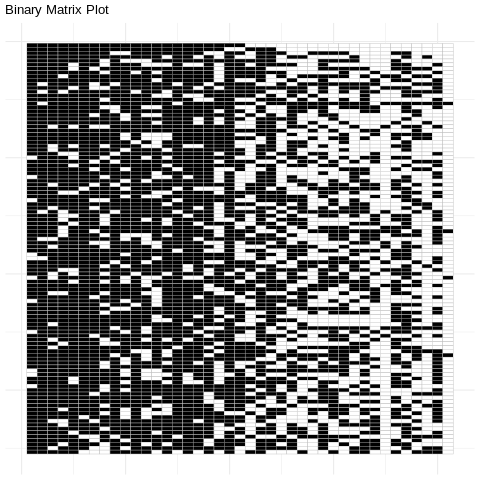

In [ ]:
%%R
plot_binary_matrix(ocmat_filtered)

## Reference data analysis

### Association between microbiome and FAST score

The `microbiome_continuous_analysis` function is designed to comprehensively evaluate and visualize the relationship between microbial community composition (`community_matrix`) and a continuous environmental variable (specified by `env_name` in `env_matrix`). It performs the following analyses:

* **Alpha diversity analysis** using the Shannon index, plotted against the environmental variable, with correlation statistics (Spearman correlation and p-value).
* **Correlation analysis** between each taxon's relative abundance and the environmental variable, visualized as a bar plot (positive in blue, negative in red).
* **Multivariate ordination methods** including RDA (Redundancy Analysis), CCA (Canonical Correspondence Analysis), NMDS (Non-metric Multidimensional Scaling), and db-RDA (distance-based RDA), each with environmental vectors shown as arrows and colored sample points based on the environmental value.
* **Variance explanation** for db-RDA shown as a bar chart, indicating the proportion of variance explained by the environmental factor.
* **PERMANOVA (adonis2)** to test for statistical significance of the environmental effect on community composition.

The function returns a list of ggplot2 visualizations and data frames, providing both statistical and visual insights into how the microbiome varies along a continuous environmental gradient.


     Sample Observed   Simpson  Shannon    Pielou  Env
F286   F286       27 0.9330017 2.935936 0.8908015  1.0
F287   F287       26 0.9277085 2.867675 0.8801687  0.9
F290   F290       28 0.8704354 2.615901 0.7850363  0.1
F703   F703       24 0.9156885 2.746107 0.8640844  1.4
F705   F705       28 0.8978303 2.812001 0.8438861 -0.9
F707   F707       26 0.8999358 2.717790 0.8341648 -1.0
F708   F708       22 0.9085933 2.666073 0.8625159 -1.4
F715   F715       28 0.9232680 2.813082 0.8442105  0.9
F716   F716       21 0.8374830 2.277851 0.7481801  1.3
F721   F721       24 0.9216722 2.765425 0.8701631 -1.0
F723   F723       21 0.8641415 2.361319 0.7755958 -0.6
F724   F724       22 0.8870326 2.480901 0.8026099 -0.7
F725   F725       31 0.9163600 2.864161 0.8340627 -0.8
F746   F746       27 0.9310520 2.874151 0.8720550  0.1
F747   F747       24 0.9193934 2.764462 0.8698599 -0.2
F749   F749        9 0.7160184 1.403266 0.6386538 -0.5
F750   F750       26 0.9024278 2.728695 0.8375121 -1.5
F752   F75

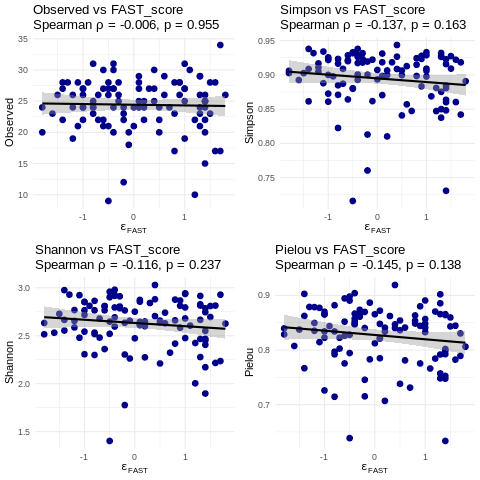

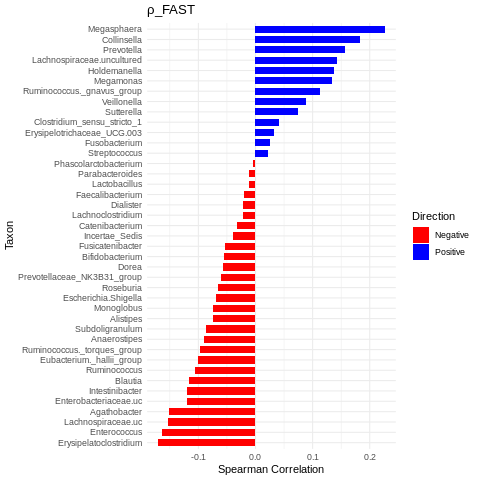

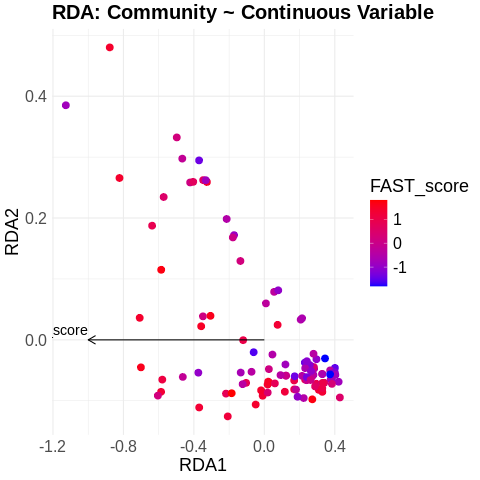

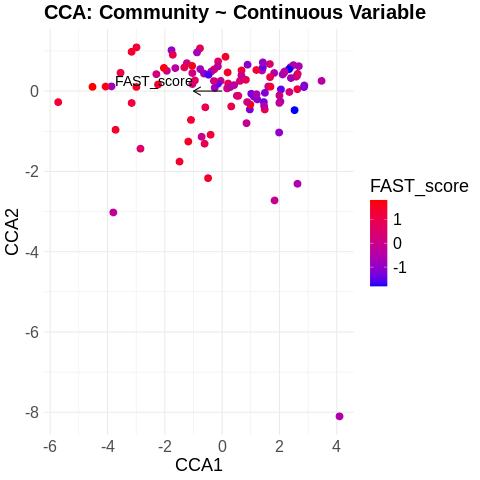

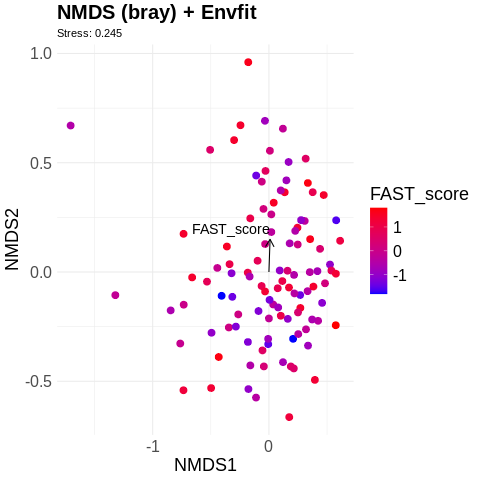

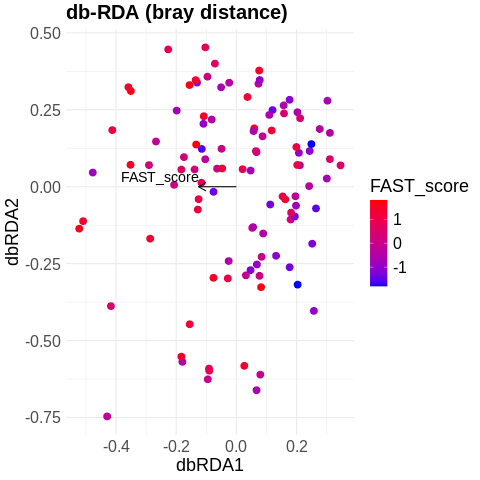

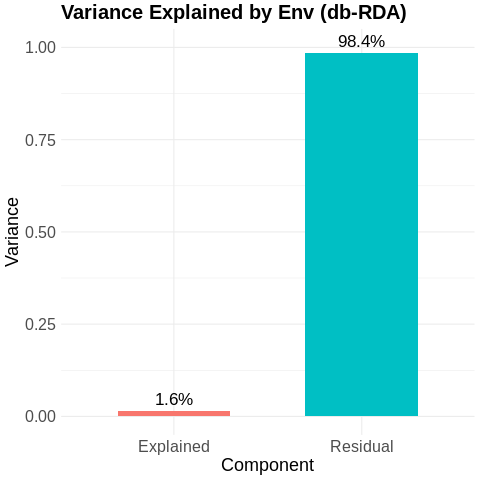

In [ ]:
%%R
colnames(abmat_filtered) <- colnames(abmat_filtered)
result <- microbiome_base_analysis(abmat_filtered, enmat_fastscore_filtered, "FAST_score")
result

In [ ]:
%%R
# 1. Beta diversity matrix (e.g., Bray-Curtis distance)
beta_dist <- vegdist(abmat_filtered, method = "bray")

# 2. FAST_score maximum matrix
# Create a matrix where each entry is max(FAST_i, FAST_j)
fast_scores <- enmat_fastscore_filtered[,1]
n <- length(fast_scores)
fast_max_matrix <- outer(fast_scores, fast_scores, pmax)  # pmax = pairwise max

# Convert to 'dist' object to match beta_dist
fast_max_dist <- as.dist(fast_max_matrix)

# 3. Mantel test between community distance and FAST_score maximum distance
mantel_result <- mantel(beta_dist, fast_max_dist, method = "spearman", permutations = 999)

# Output result
print(mantel_result)


Mantel statistic based on Spearman's rank correlation rho 

Call:
mantel(xdis = beta_dist, ydis = fast_max_dist, method = "spearman",      permutations = 999) 

Mantel statistic r: 0.1056 
      Significance: 0.051 

Upper quantiles of permutations (null model):
   90%    95%  97.5%    99% 
0.0759 0.1034 0.1244 0.1435 
Permutation: free
Number of permutations: 999



## ELA based data analysis

### Parameter fitting

By default, the saved RDS file is loaded. To perform a new calculation, uncomment the following lines.

In [ ]:
%%R
set.seed(42)
list[bp,allresults] <-Findbp(ocmat_filtered, enmat = enmat_fastscore_filtered, ssize=0.75, we = c(0.00001), totalit = 12000,
    lmd = c(0.001, 0.01,0.02,0.05,0.1,0.2,0.5,1.0,2.0), rep = 1, nboot=1001, intv = 200,
    threads = 64, runadamW = TRUE, sparse = TRUE, fastfitting = FALSE)

In [ ]:
%%R
#saveRDS(bp, file = "bp_083026_genus.rds")
#saveRDS(allresults, file = "allresults_bp_083026_genus.rds")
bp <- readRDS("FASTexELA/rds/bp_083026_genus.rds")
allresults <- readRDS("FASTexELA/rds/allresults_083026_genus.rds")

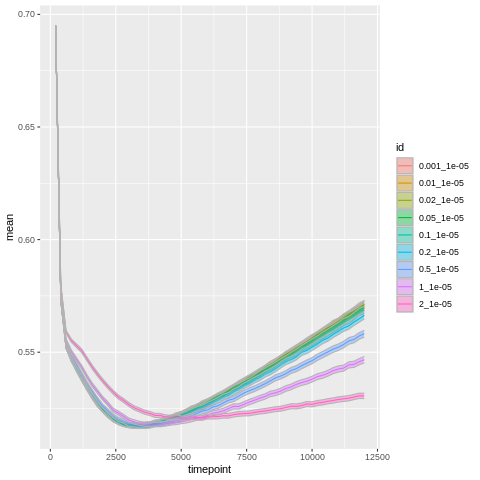

In [ ]:
%%R
plotSAtest(allresults)

Here, "id" corresponds to the tested parameter sets (lambda, we), which are key hyper parameters for Sparse matrix and adamW. The results explain lambda should be set to high for preventing overfitting in the optimization.

In [ ]:
%%R
# Then use the parameter set giving the best fitted result
list[lmd,we,totalit] <- as.numeric(unlist(strsplit(names(bp)[1], split = "_")))
print(lmd)
print(we)
print(totalit)

[1] 0.01
[1] 1e-05
[1] 3400


In [ ]:
#%%R
#set.seed(42)
## Then use the parameter set giving the best fitted result
#list[lmd,we,totalit] <- as.numeric(unlist(strsplit(names(bp)[1], split = "_")))
##runSA: ocmatrix, env (environmental parameters; with>SA / without>fullSA), qth (threshold for stopping computation), rep (number of fitting processes to compute mean parameter value), threads (number of parallel threads)
#sa <- runSA(ocmat_filtered, enmat = enmat_fastscore_filtered, rep = 1024, threads=64, getall=FALSE, intv=200,
#            totalit=totalit,lambda = lmd, we = we)

Start parameter fitting
SA: elapsed time 9.49 sec



In [ ]:
%%R
#saveRDS(sa, file = "sa_083026_genus.rds")
sa <- readRDS("FASTexELA/rds/sa_083026_genus.rds")

In [ ]:
%%R
# Theese parameters are the same except for hge. hge0 corresponds to FAST_score=0, and hge1 corresponds to FAST_score=1.
list[he0,je0,ge0,hge0] <- sa2params(sa,0)
list[he1,je1,ge1,hge1] <- sa2params(sa,1)

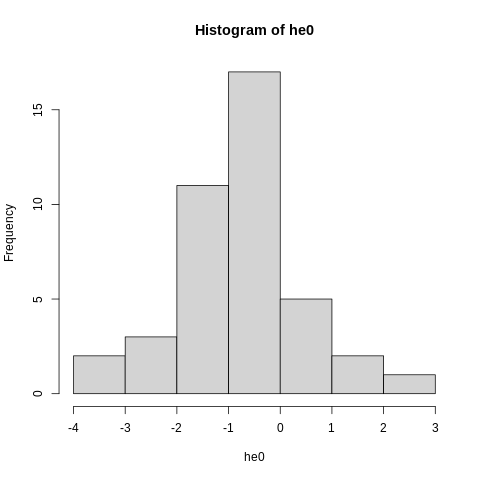

In [ ]:
%%R
hist(he0)

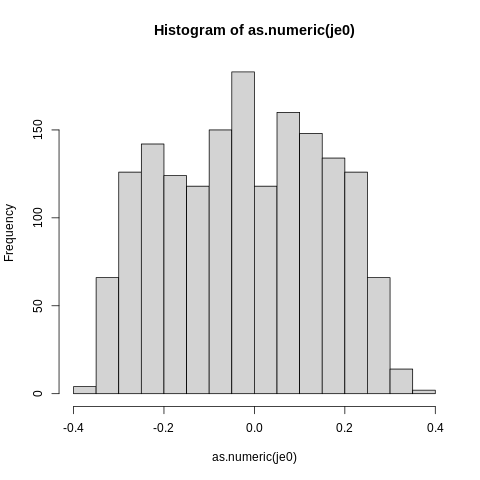

In [ ]:
%%R
hist(as.numeric(je0))

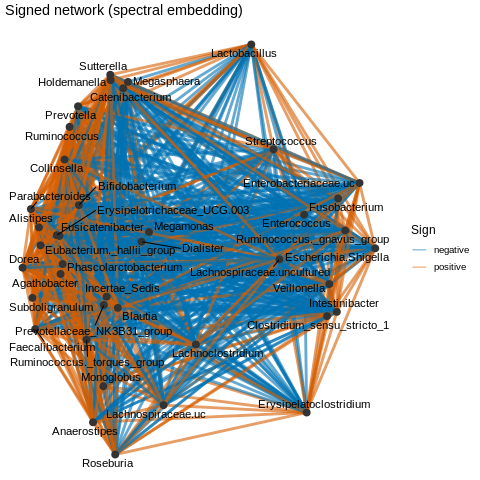

In [ ]:
%%R
plot_signed_network_spectral(sign(je0), label_size=4)

### Energy landscape analysis

In [ ]:
#%%R
#gela <- GradELA(sa=sa, eid="FAST_score", # Specify the label or position of an environmental factor
#  enmat=enmat_fastscore_filtered, env=NULL, range=c(-2., 2.), steps=41, th=0.1, threads=64) #[[1]]: return value of ELA function for each step, [[2]]: value of environmental factor for each step, [[3]]: specified environmental factor

env not specified, the mean of enmat is used
processing(41) |=========================================|
Elapsed time 76.01 sec


In [ ]:
#%%R
#gstab <- gStability(sa=sa, ocmat=ocmat_filtered, enmat = enmat_fastscore_filtered, th=0.1, threads=64, reporting=TRUE)

Start gStability:
gStability: elapsed time 29.28 sec



In [ ]:
%%R
#saveRDS(gela, file = "gela_083026_genus.rds")
#saveRDS(gstab, file = "gstab_083026_genus.rds")
gela <- readRDS("FASTexELA/rds/gela_083026_genus.rds")
gstab <- readRDS("FASTexELA/rds/gstab_083026_genus.rds")

### Stable state diagram

In [ ]:
%%R
ssd2 <- showSSD2(
  gela,
  sa,
  gstab = gstab,
  filter_by_gstab = TRUE,
  grouping = TRUE,
  min_group_size = 3,
  min_distance = 3,
  xlab = expression(epsilon[FAST]),
  device = c("png", "eps"),
  file = file.path(out, "ssd"),
  width_px = 1800,
  height_px = 1800,
  res_dpi = 300
)

ssd_grouping <- ssd2[[1]]

## Check mapping from new group IDs to original group IDs
print(attr(ssd_grouping, "original_group_id"))


Keeping groups represented by observed samples in gstab:
  old C1 -> new C1
  old C2 -> new C2
  old C3 -> new C3
  old C4 -> new C4 
[1] 1 2 3 4


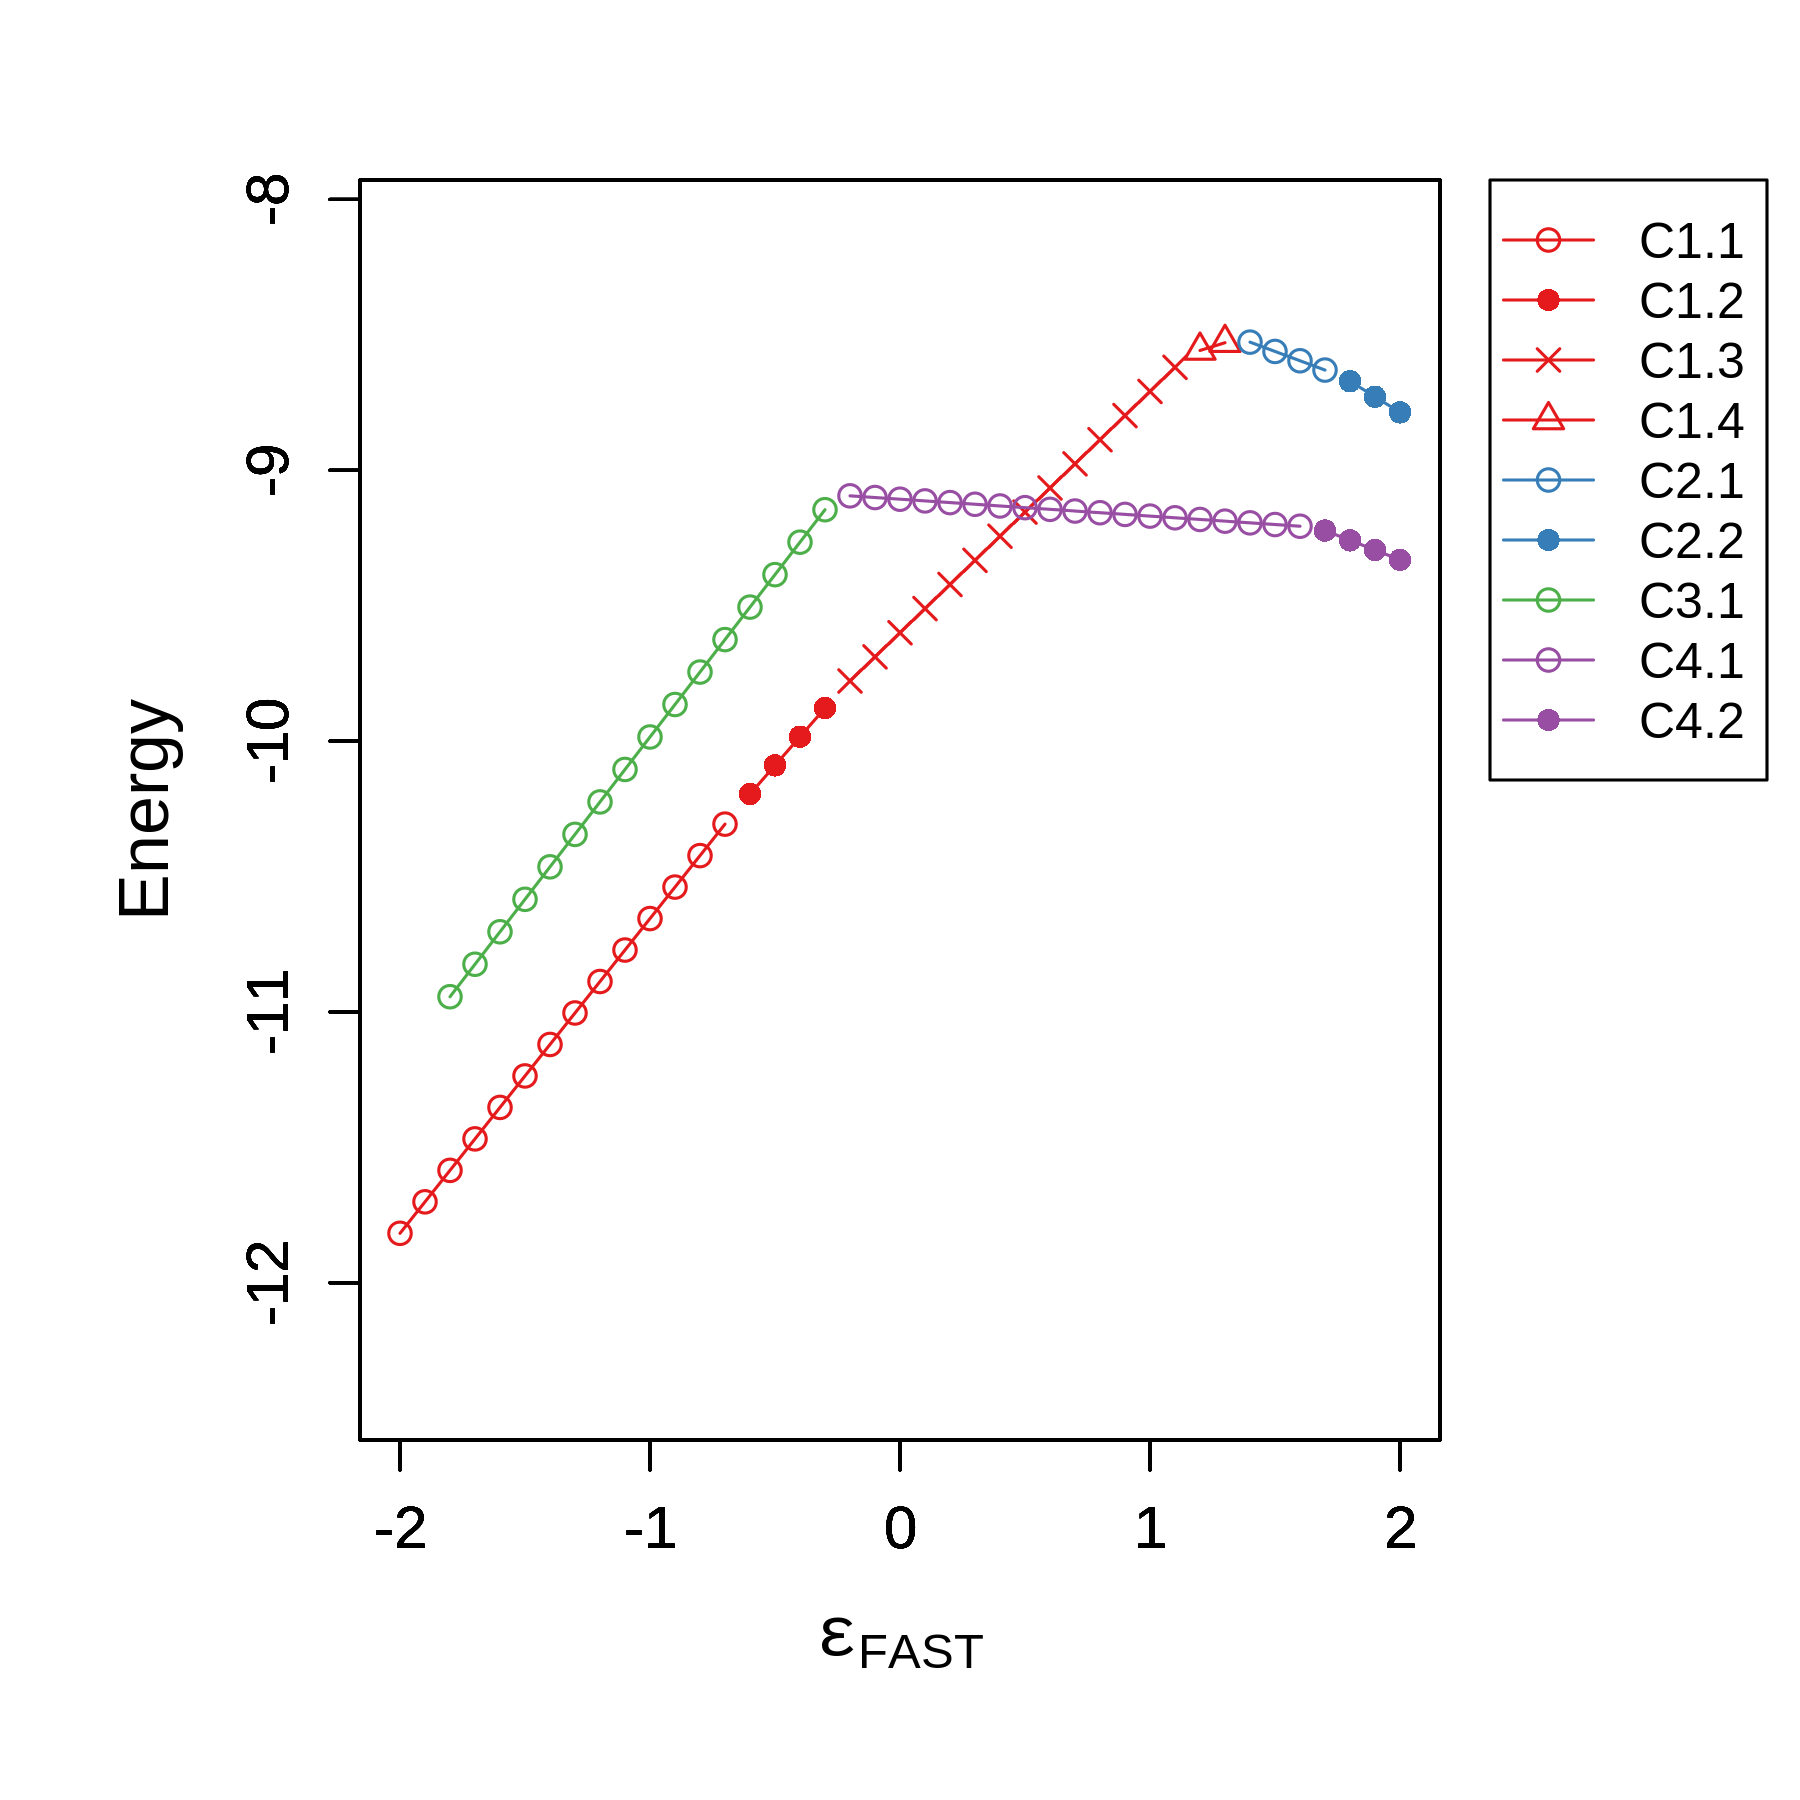

In [ ]:
## Show saved image in Colab
display(Image(filename = out+"ssd.png", width = 600))

In [ ]:
%%R
ssd_grouping <- ssd2[[1]]
p <- ss_group_plot(ssd_grouping, order=order(ge0),
  device = c("png", "eps"),
  file = file.path(out,"ss_group_plot"),
  width_px = 1800,
  height_px = 1800,
  res_dpi = 300)

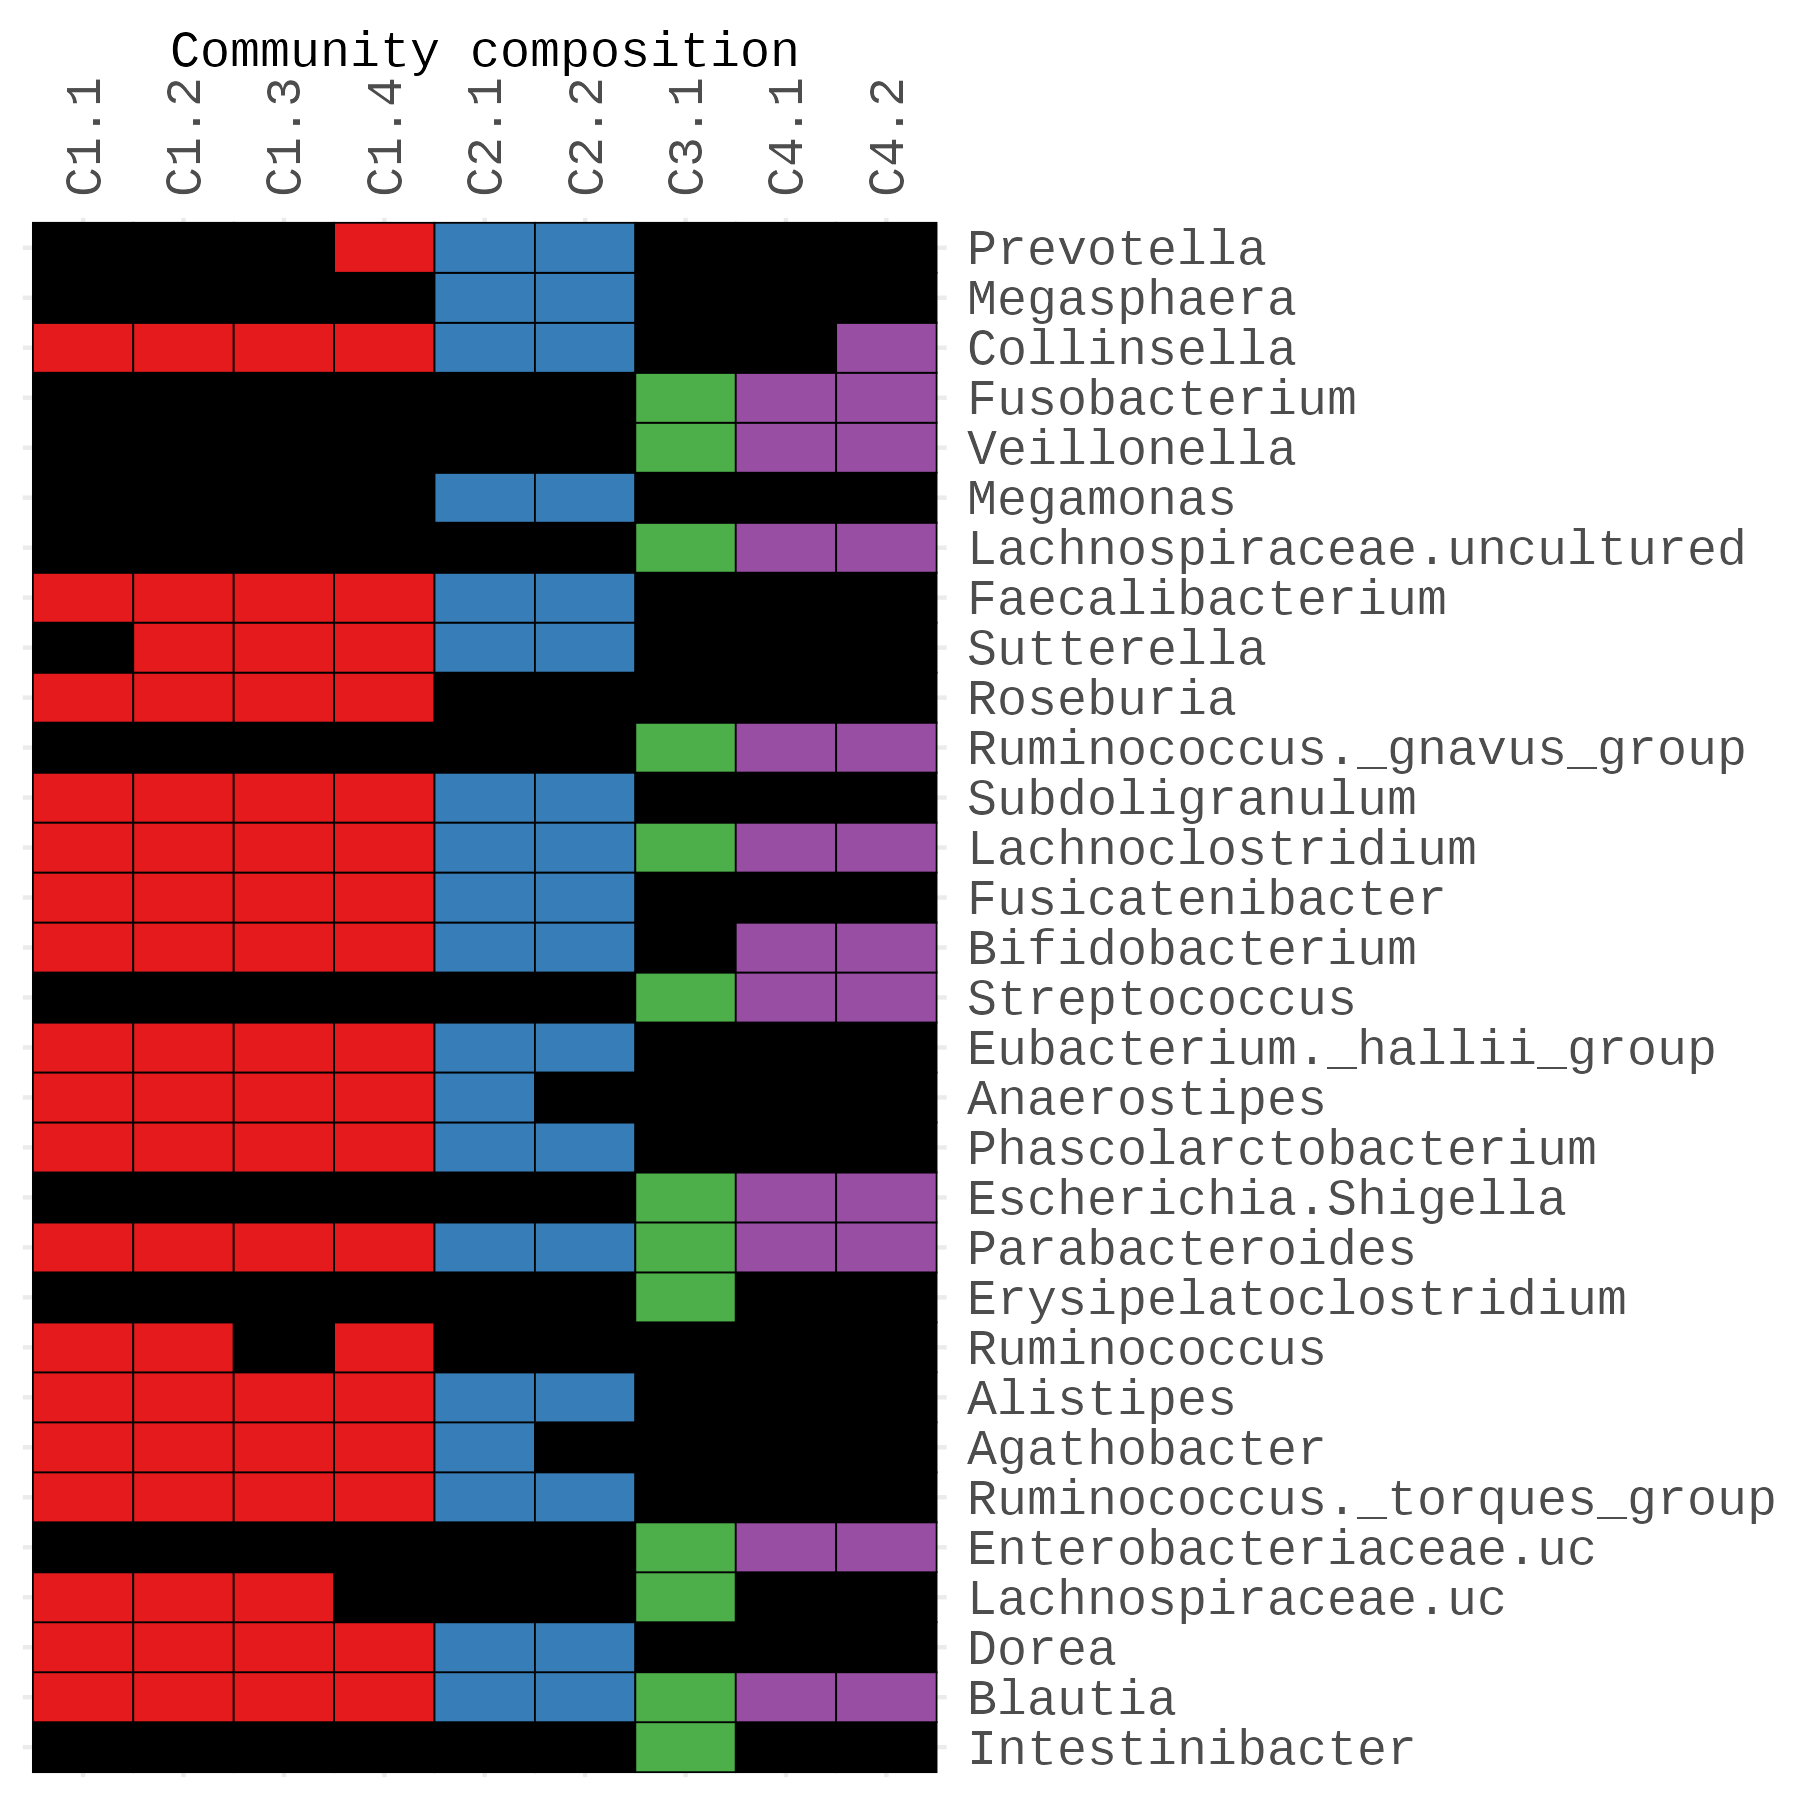

In [ ]:
display(Image(filename= out+"ss_group_plot.png", width=600))

### Gropup heatmap

In [ ]:
%%R
ht_res <- ssd_group_heatmap(
  ssd_grouping,
  mode = "distance",
  device = c("png", "eps"),
  file = file.path(out,"group_dist_map"),
  width_px = 1600,
  height_px = 1400,
  res_dpi = 300
)

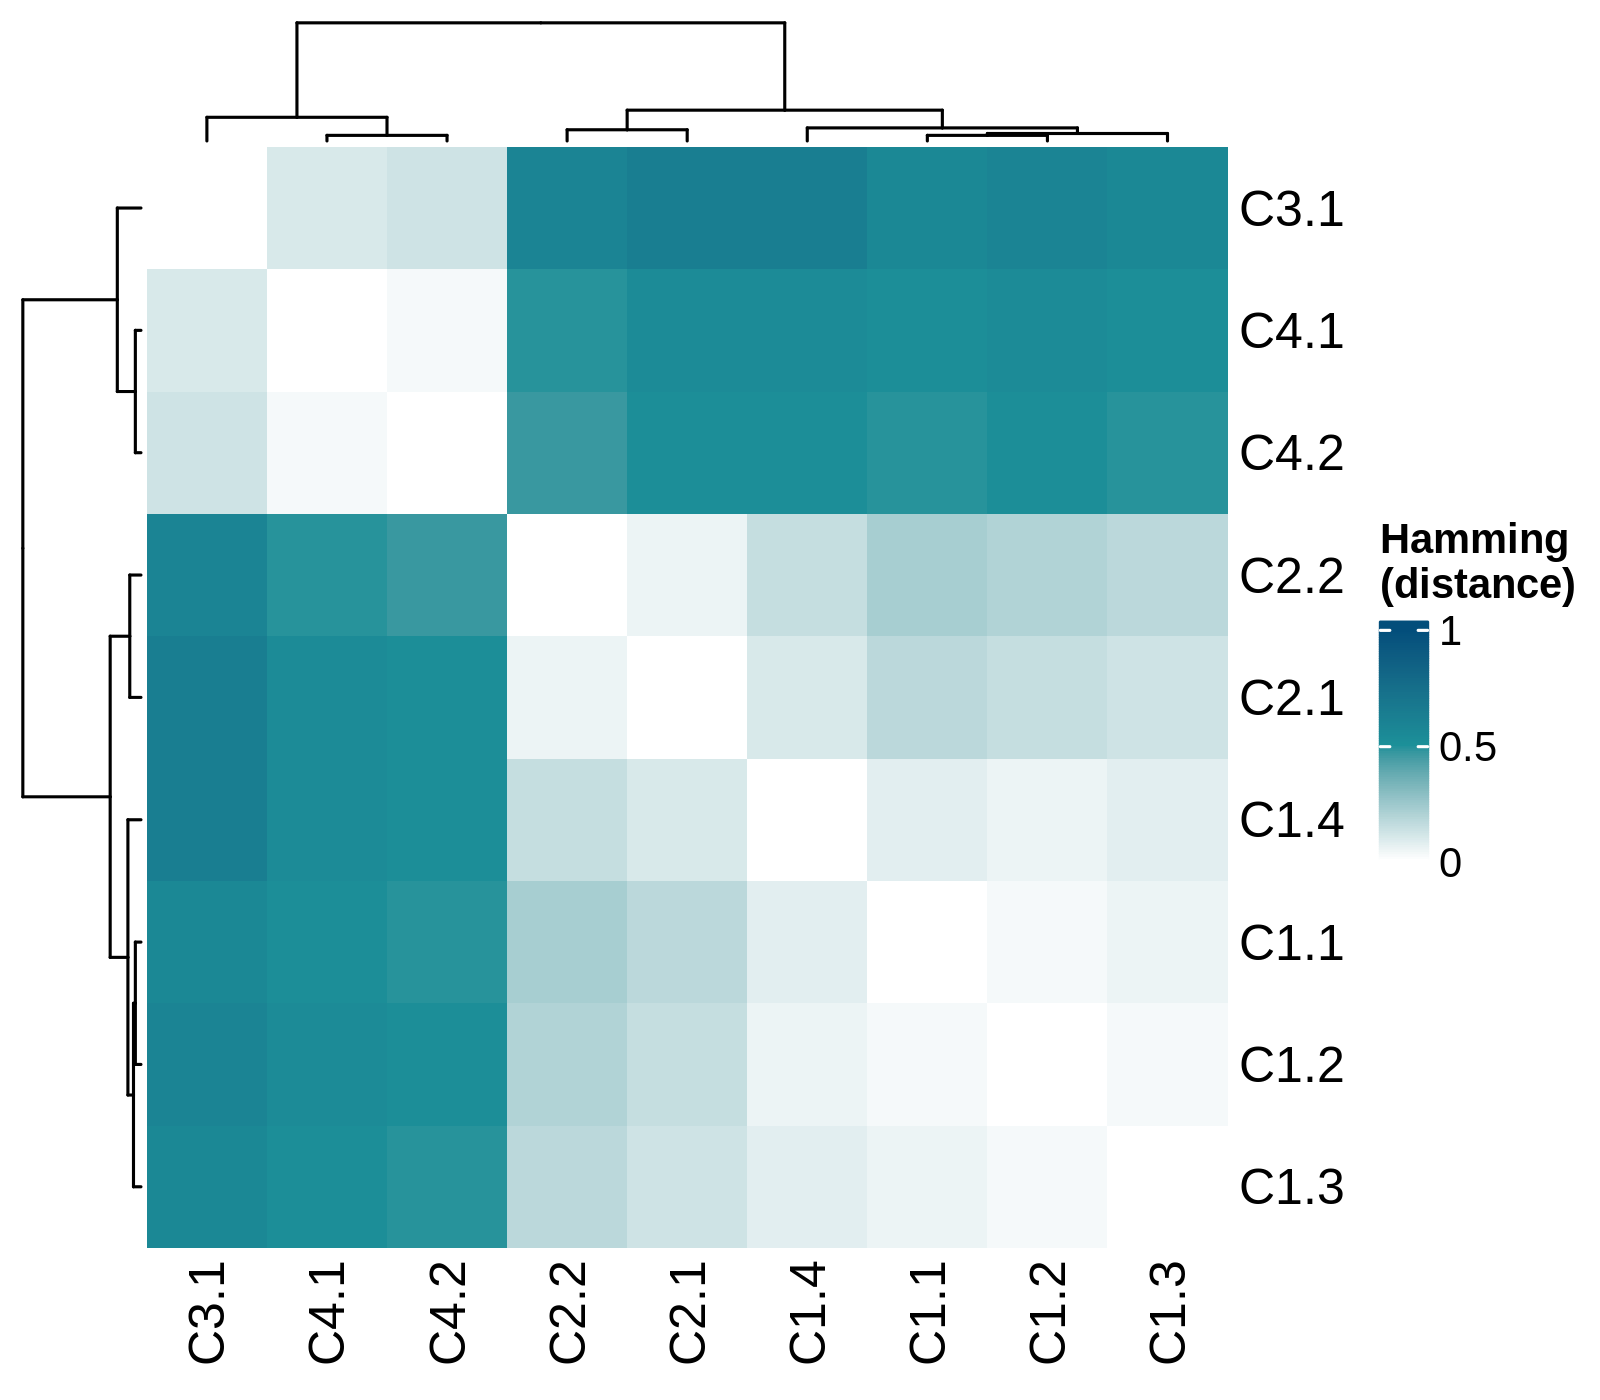

In [ ]:
display(Image(filename= out+"group_dist_map.png", width=600))

### Community shaping index

In [ ]:
%%R
M <- membership_from_ssd(ssd_grouping)
rownames(M) <- rownames(je0)

CSI <- compute_community_shaping_index(je0, M)

csi_res <- plot_CSI_heatmap(
  ssd_grouping = ssd_grouping,
  je = je0,
  M = M,
  CSI = CSI,
  order = order(ge0),
  device = c("png", "eps"),
  file = file.path(out,"csi"),
  width_in = 5.2,
  height_in = 5.2,
  res_dpi = 300
)

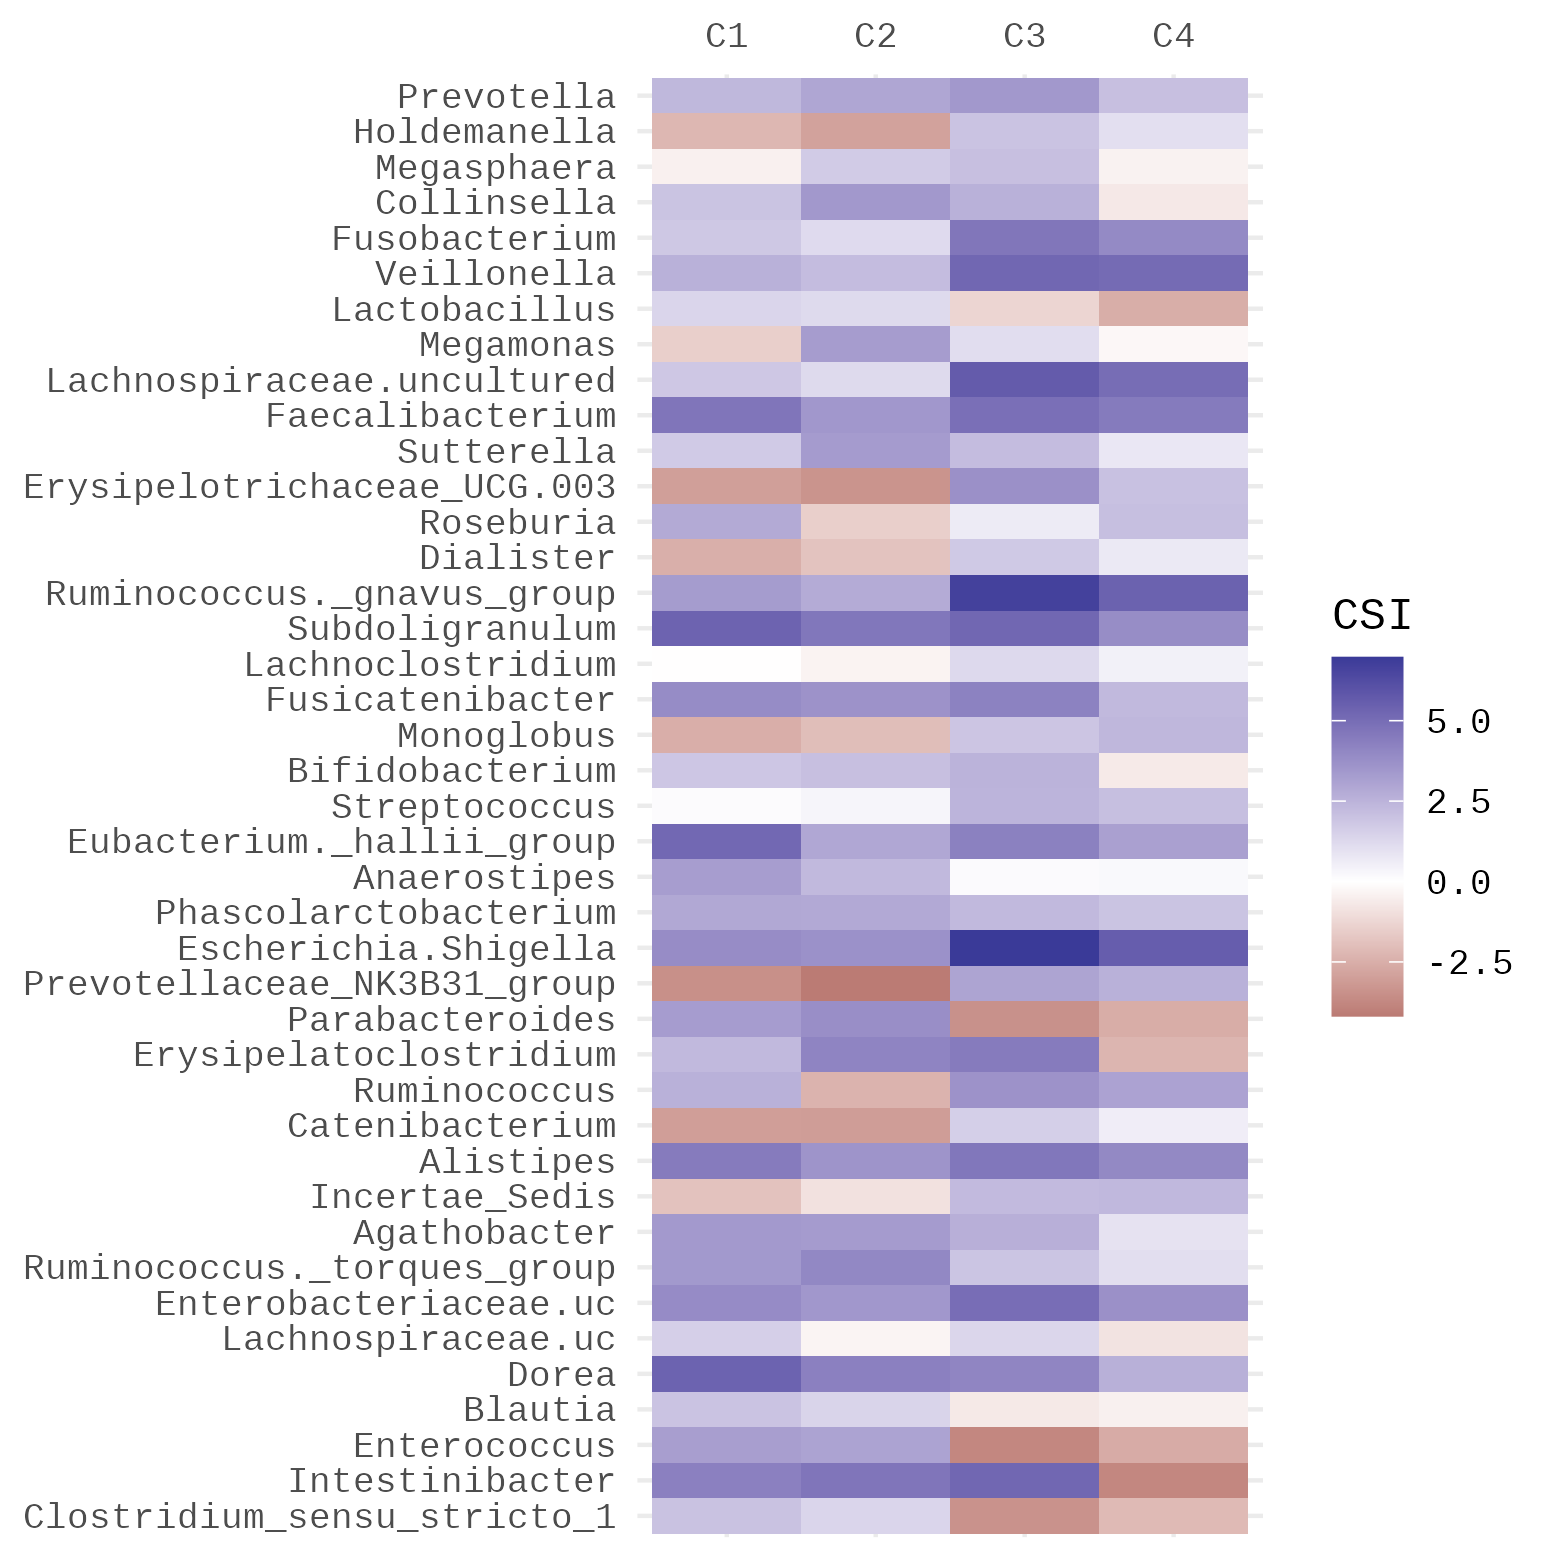

In [ ]:
display(Image(filename= out+"csi.png", width=600))

In [ ]:
%%R
M

                            C1 C2 C3 C4
Prevotellaceae_NK3B31_group  0  0  0  0
Enterococcus                 0  0  0  0
Incertae_Sedis               0  0  0  0
Lactobacillus                0  0  0  0
Dialister                    0  0  0  0
Clostridium_sensu_stricto_1  0  0  0  0
Erysipelatoclostridium       0  0  1  0
Ruminococcus                 1  0  0  0
Escherichia.Shigella         0  0  1  1
Megamonas                    0  1  0  0
Catenibacterium              0  0  0  0
Megasphaera                  0  1  0  0
Agathobacter                 1  1  0  0
Prevotella                   1  1  0  0
Intestinibacter              0  0  1  0
Erysipelotrichaceae_UCG.003  0  0  0  0
Monoglobus                   0  0  0  0
Veillonella                  0  0  1  1
Streptococcus                0  0  1  1
Holdemanella                 0  0  0  0
Roseburia                    1  0  0  0
Subdoligranulum              1  1  0  0
Fusobacterium                0  0  1  1
Enterobacteriaceae.uc        0  0  1  1


### CSI vs g_FAST

`geom_smooth()` using formula = 'y ~ x'


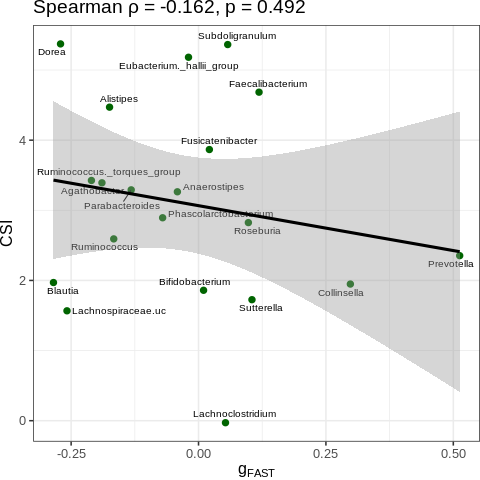

In [ ]:
%%R
library(ggrepel)

ci <- 1
mm <- M[,ci,drop=FALSE]
csi <- CSI[,ci,drop=FALSE]
csi <- csi[mm==1,,drop=FALSE]
ge <- ge0[mm==1,,drop=FALSE]

# Spearman correlation test
cor_test <- suppressWarnings(cor.test(csi, ge, method = "spearman"))
rho_val <- sprintf("%.3f", cor_test$estimate)
p_val   <- sprintf("%.3f", cor_test$p.value)

# Create data frame
csi.vs.ge_df <- data.frame(dCSI = csi, g_FAST = ge)

# Generate plot
ggplot(csi.vs.ge_df, aes(x = ge, y = csi)) +
  geom_point(color = "darkgreen", size = 2.5) +
  geom_text_repel(aes(label = rownames(csi.vs.ge_df)),
                  size = 3.5, max.overlaps = 50, box.padding = 0.3) +
  geom_smooth(method = "lm", color = "black", se = TRUE) +
  labs(
    x = expression(g[FAST]),
    y = "CSI",
    title = paste0(
      "Spearman \u03C1 = ", rho_val, ", p = ", p_val
    )
  ) +
  theme_bw(base_size = 16) +
  theme(
    plot.margin = margin(0, 0, 0, 0),
    plot.title = element_text(lineheight = 1.2)
  )


In [ ]:
%%R
csi_ge_res <- plot_CSI_gFAST_panels(
  M = M,
  CSI = CSI,
  ge = ge0,
  panel_ids = 1:8,
  panel_ncol = 4,
  panel_nrow = 2,
  device = c("png", "eps"),
  file = file.path(out,"csi_ge_panels"),
  width_px = 3600,
  height_px = 1950,
  res_dpi = 300
)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


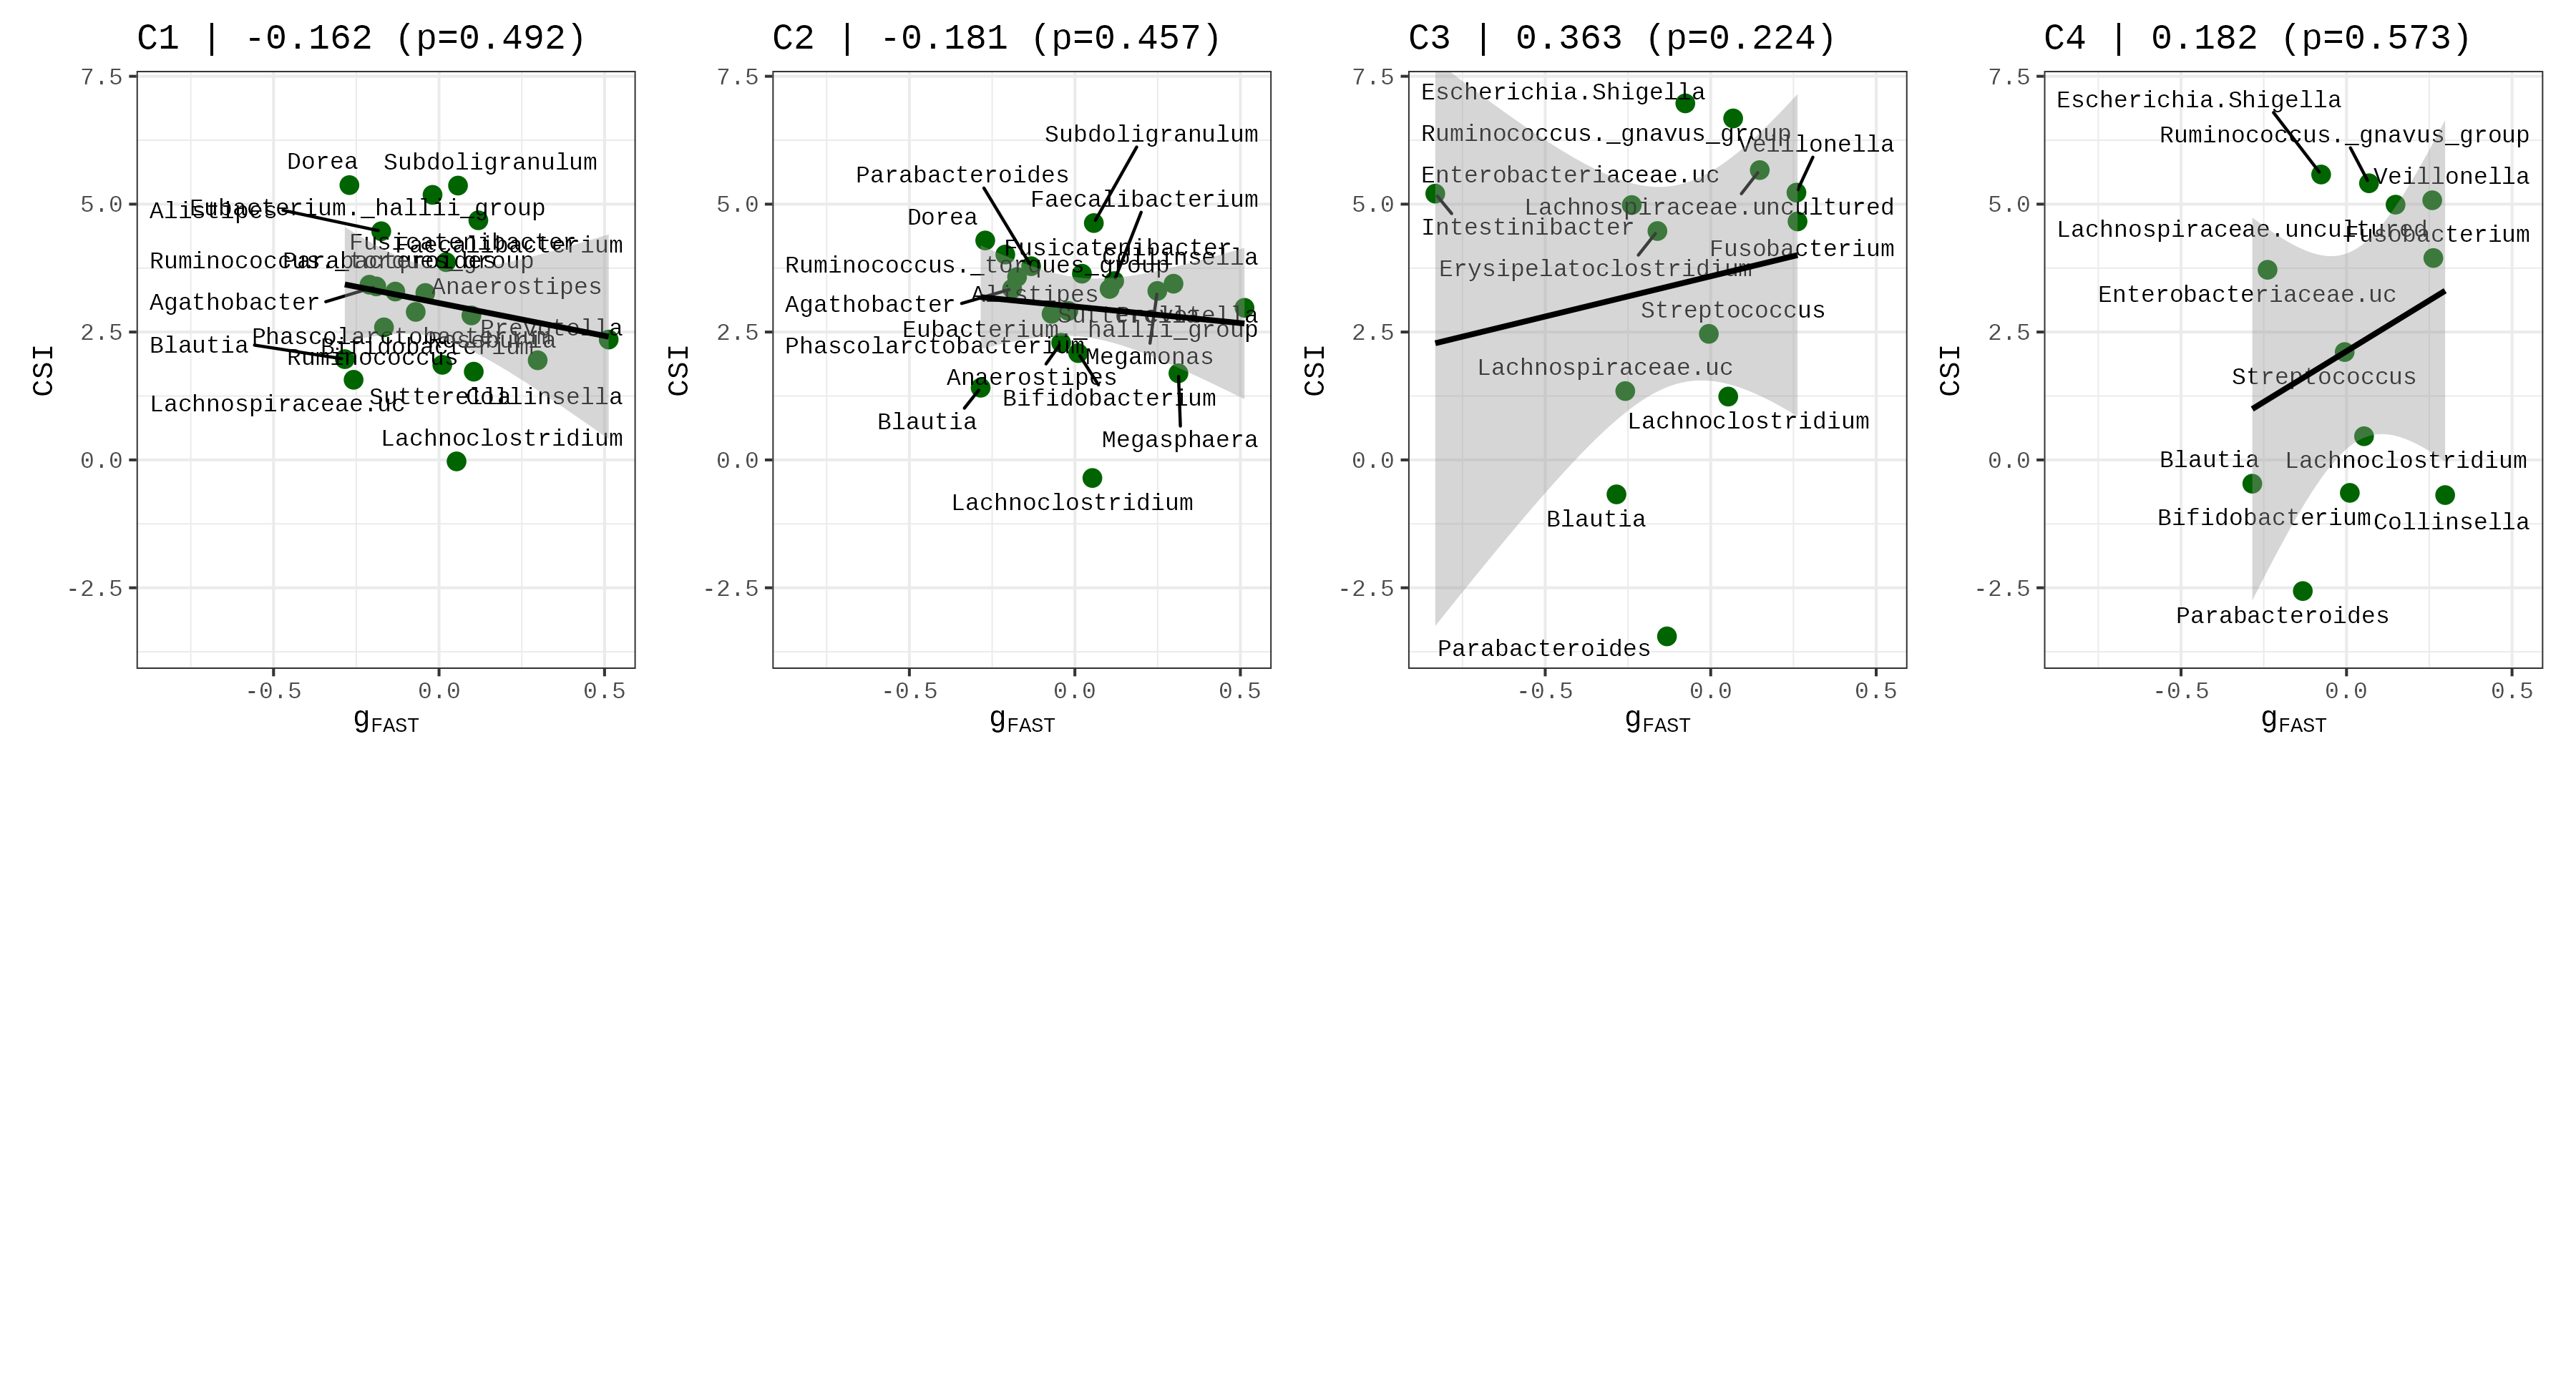

In [ ]:
display(Image(filename= out+"csi_ge_panels.png", width=1200))

### Energy vs FAST

In [ ]:
%%R
ene_res <- plot_energy_FAST_by_group(
  gstab = gstab,
  ssd_grouping = ssd_grouping,
  enmat_fastscore = enmat_fastscore_filtered,
  ocmat = ocmat_filtered,
  device = c("png", "eps"),
  file = file.path(out,"ene_env"),
  width_in = 5.2,
  height_in = 5.2,
  res_dpi = 300
)

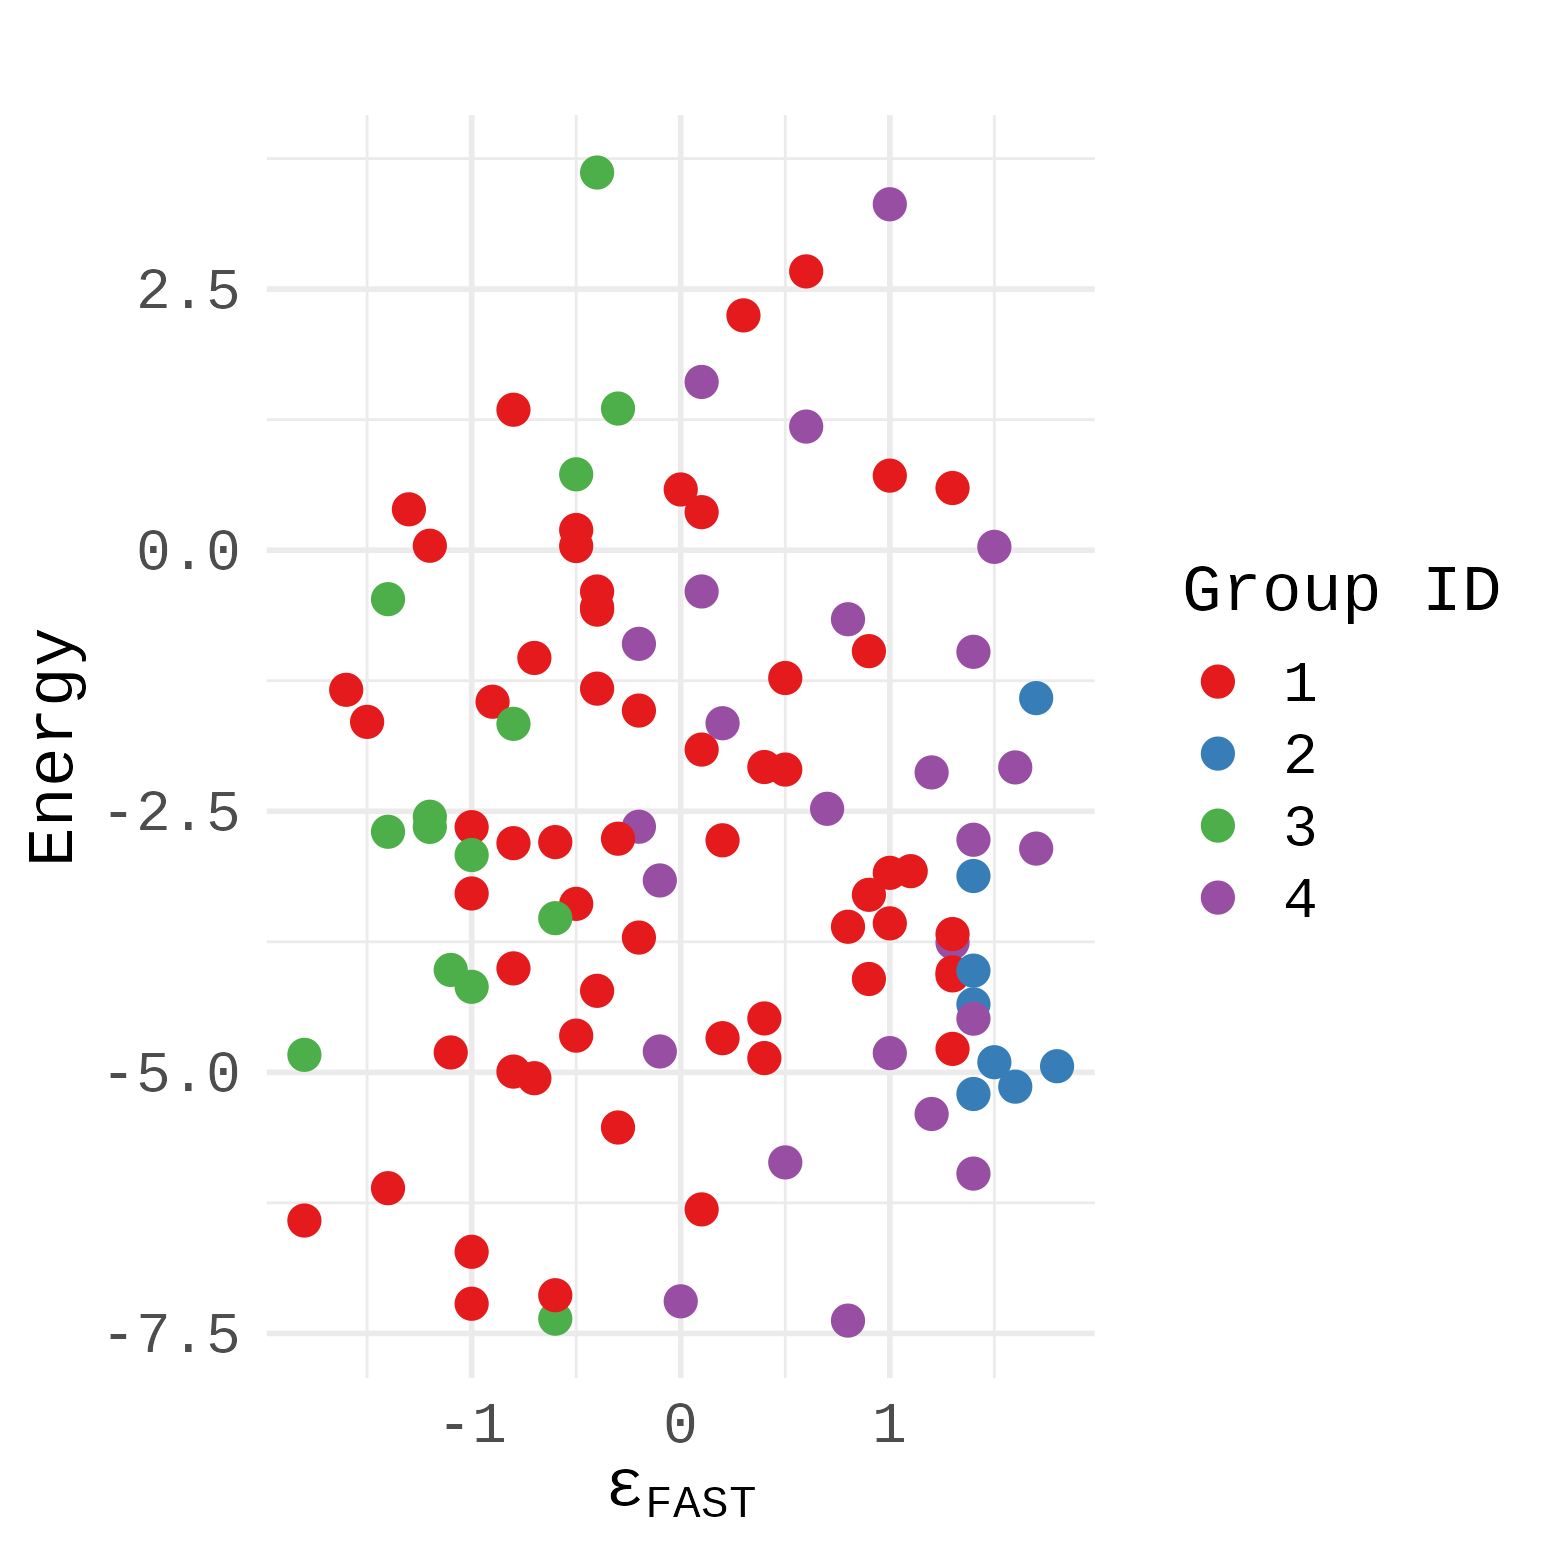

In [ ]:
display(Image(filename= out+"ene_env.png", width=400))

### Basin size

In [ ]:
%%R
basin_res <- plot_relative_basin_size(
  gela = gela,
  sa = sa,
  ssd_grouping = ssd_grouping,
  itr = 512,
  threads = 64,
  seed = 123,
  env_label_values = enmat_fastscore_filtered[, 1],
  x_break_by = 5,
  device = c("png", "eps"),
  file = file.path(out,"basin_size"),
  width_in = 5.8,
  height_in = 4.6,
  res_dpi = 300
)

Estimating basin sizes:
  environmental points: 41 
  trials per point: 512 
  threads: 64 
  SSD group signature entries: 9 
Group assignment summary:

    0     1     2     3     4 
 2093 10484  1571  2768  4076 


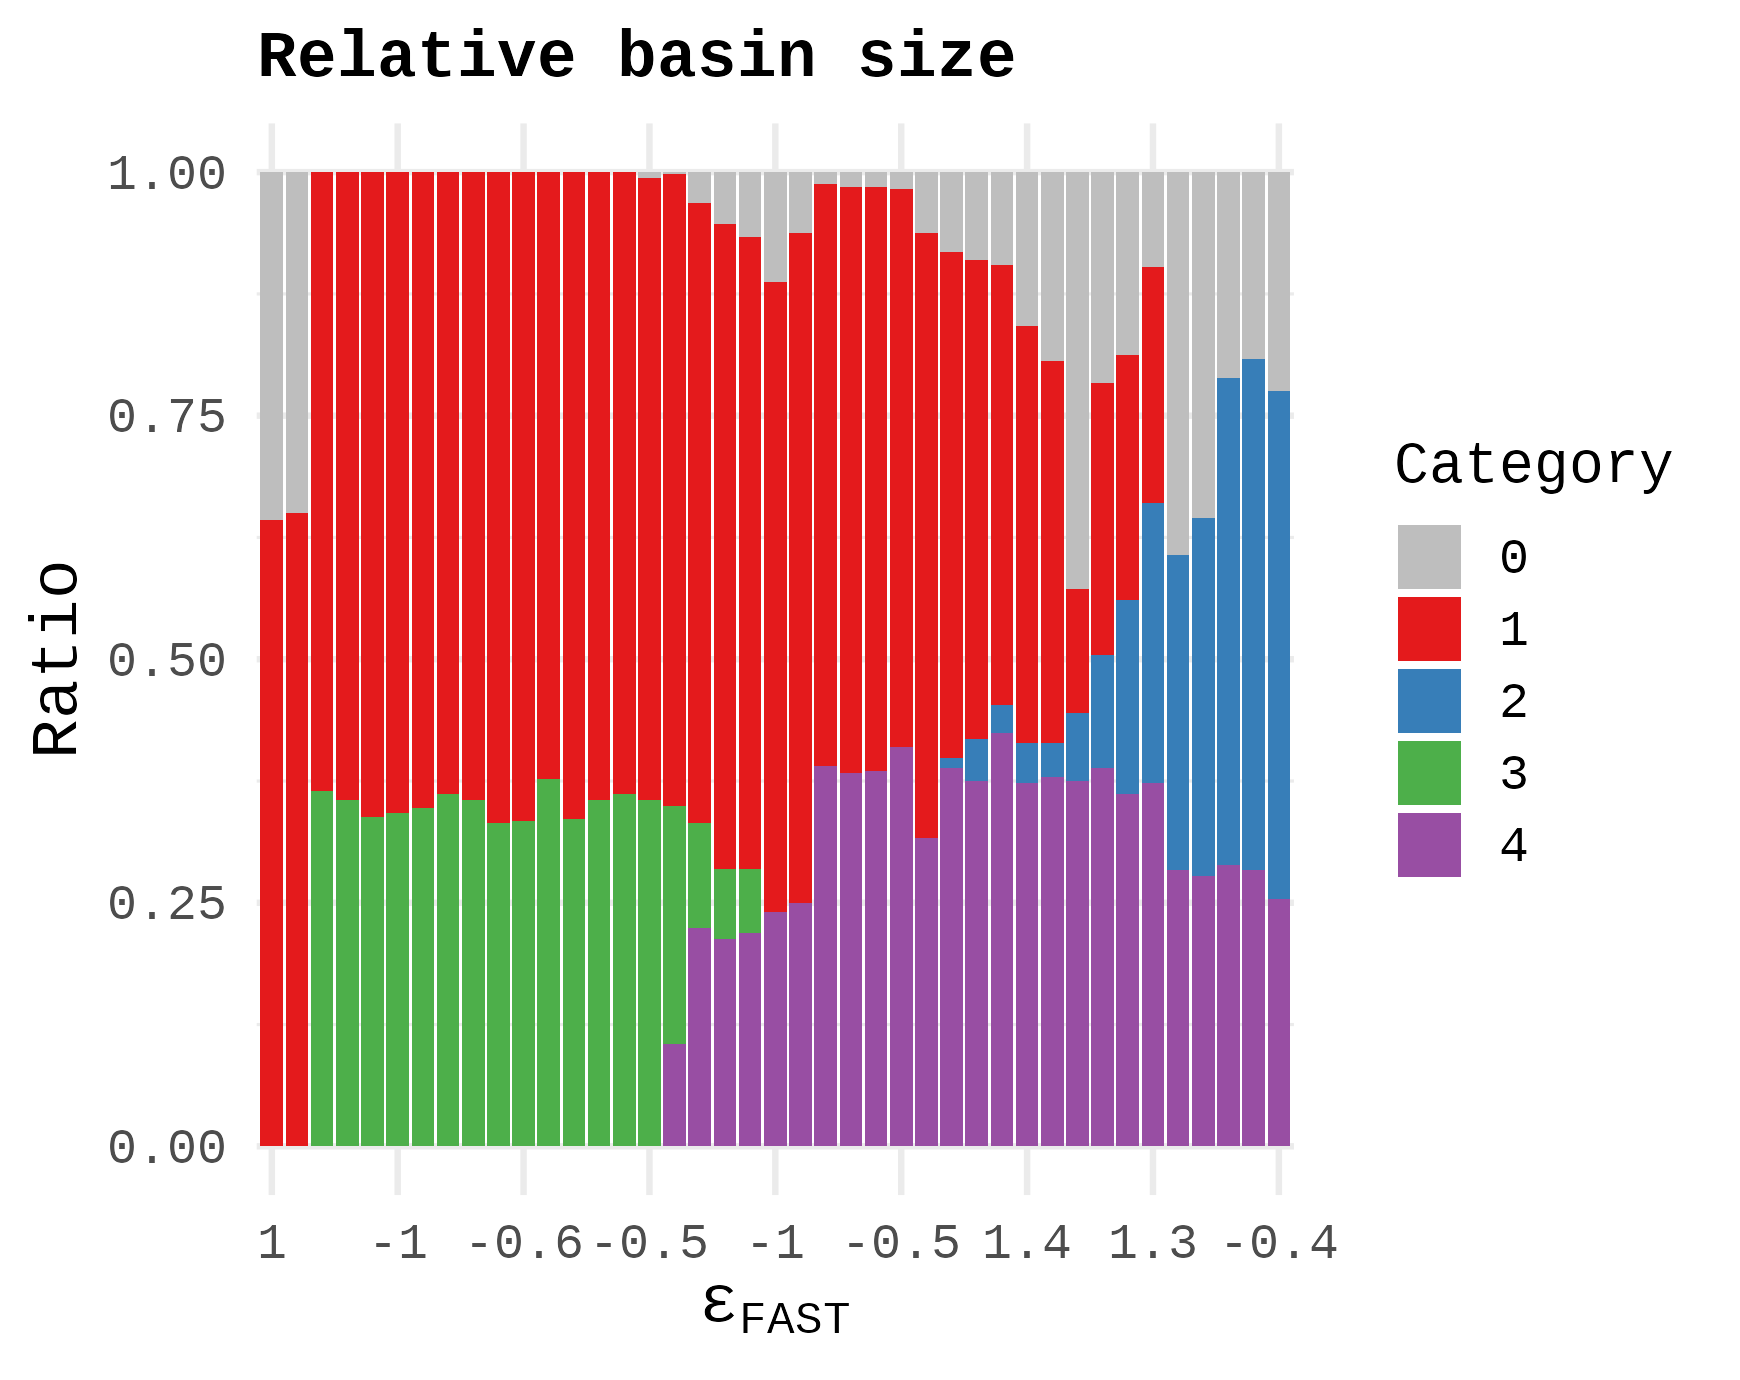

In [ ]:
display(Image(filename= out+"basin_size.png", width=400))

### 3Dplot

[1] "3" "1" "4" "2"
        3         1         4         2 
0.0000000 0.3615385 0.6846154 1.0000000 
$x_unit
[1] "SSD group"

$same_group_same_x
[1] TRUE

$order_policy
[1] "group-level distance ordering followed by rightward y-adjacency"

$w_adj
[1] 20

$w_energy
[1] 2

$w_mem
[1] 1

$w_gap
[1] 5

$adj_only
[1] TRUE

$adj_energy_scale
[1] "median"



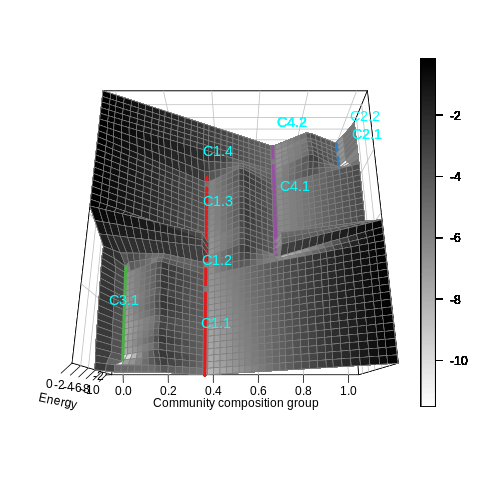

In [ ]:
%%R
## ============================================================
## Example
## ============================================================

gox <- GELSobj3(
  gela,
  sa,
  ssd_grouping,
  x_spline_points = 200,
  y_smooth_window = 3,
  x_offset_ratio = 0.05,
  pin_midpoints = TRUE,
  x_interp = "linear",

  ## group-level alignment policy
  w_adj = 20,
  w_energy = 2,
  w_mem = 1,
  w_gap = 5,
  adj_only = TRUE,
  adj_energy_scale = "median"
)

print(attr(gox$l3dx, "group_ordered"))
print(attr(gox$l3dx, "group2x"))
print(attr(gox$l3dx, "alignment_policy"))

p <- showGELS3D2(
  gox,
  theta = 0,
  phi = 70,
  mode = "shaded_gray",
  z_compress = 0.5,
  x_lab = "Community composition group",
  y_lab = expression(epsilon[FAST]),
  return_replayer = TRUE
)

In [ ]:
%%R
out_files <- save_replayer_multi(
  replayer = p,
  file = file.path(out,"GELS3D_surface"),
  device = c("png", "eps", "tiff"),
  width_px = 3600,
  height_px = 3600,
  res_dpi = 600
)

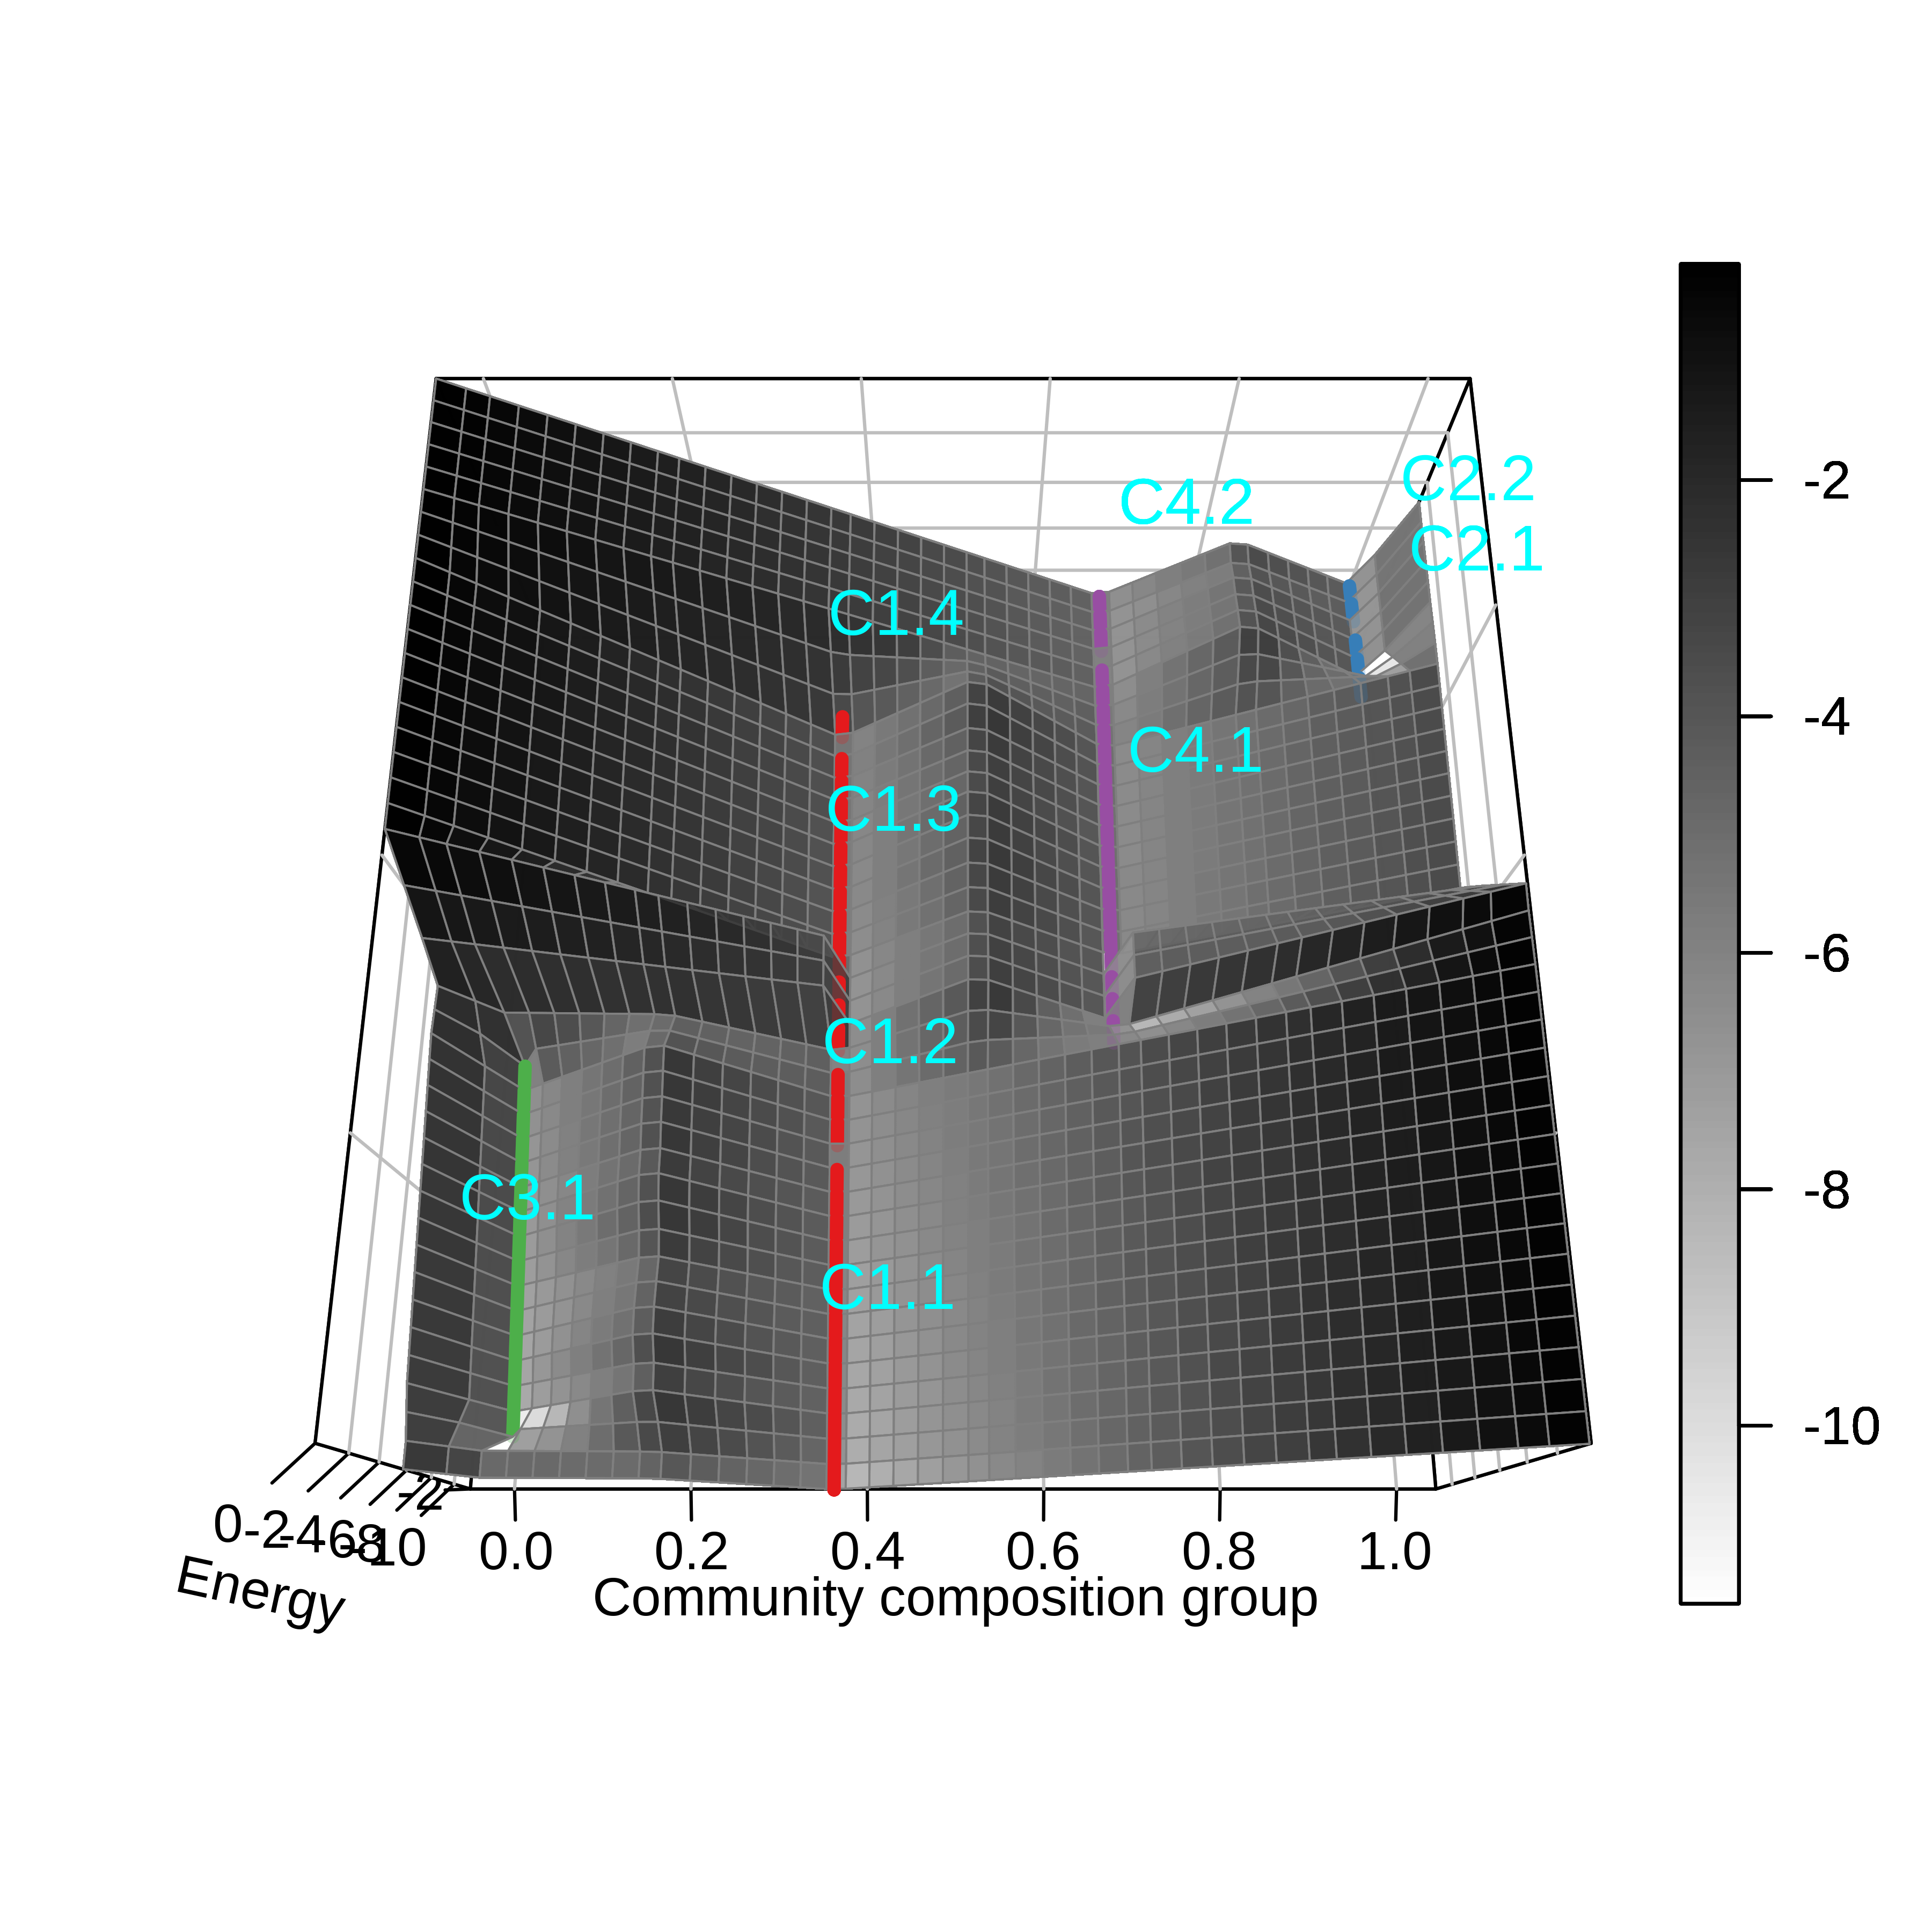

In [ ]:
display(Image(out+"GELS3D_surface.png", width=400))

## Integrative data analysis

### Association between taxonomic groups and FAST scores

The following shows the association of each taxonomic group to the FAST_score (**g_FASTscore**). Taxonomic groups with positive (negative) values are more likely to appear in samples with high (low) FAST scores.

In [ ]:
%%R
g_res <- plot_gFAST_bar(
  ge = ge0,
  score_col = "FAST_score",
  device = c("png", "eps"),
  file = file.path(out,"g_FAST_bar"),
  width_in = 6,
  height_in = 6,
  res_dpi = 300
)

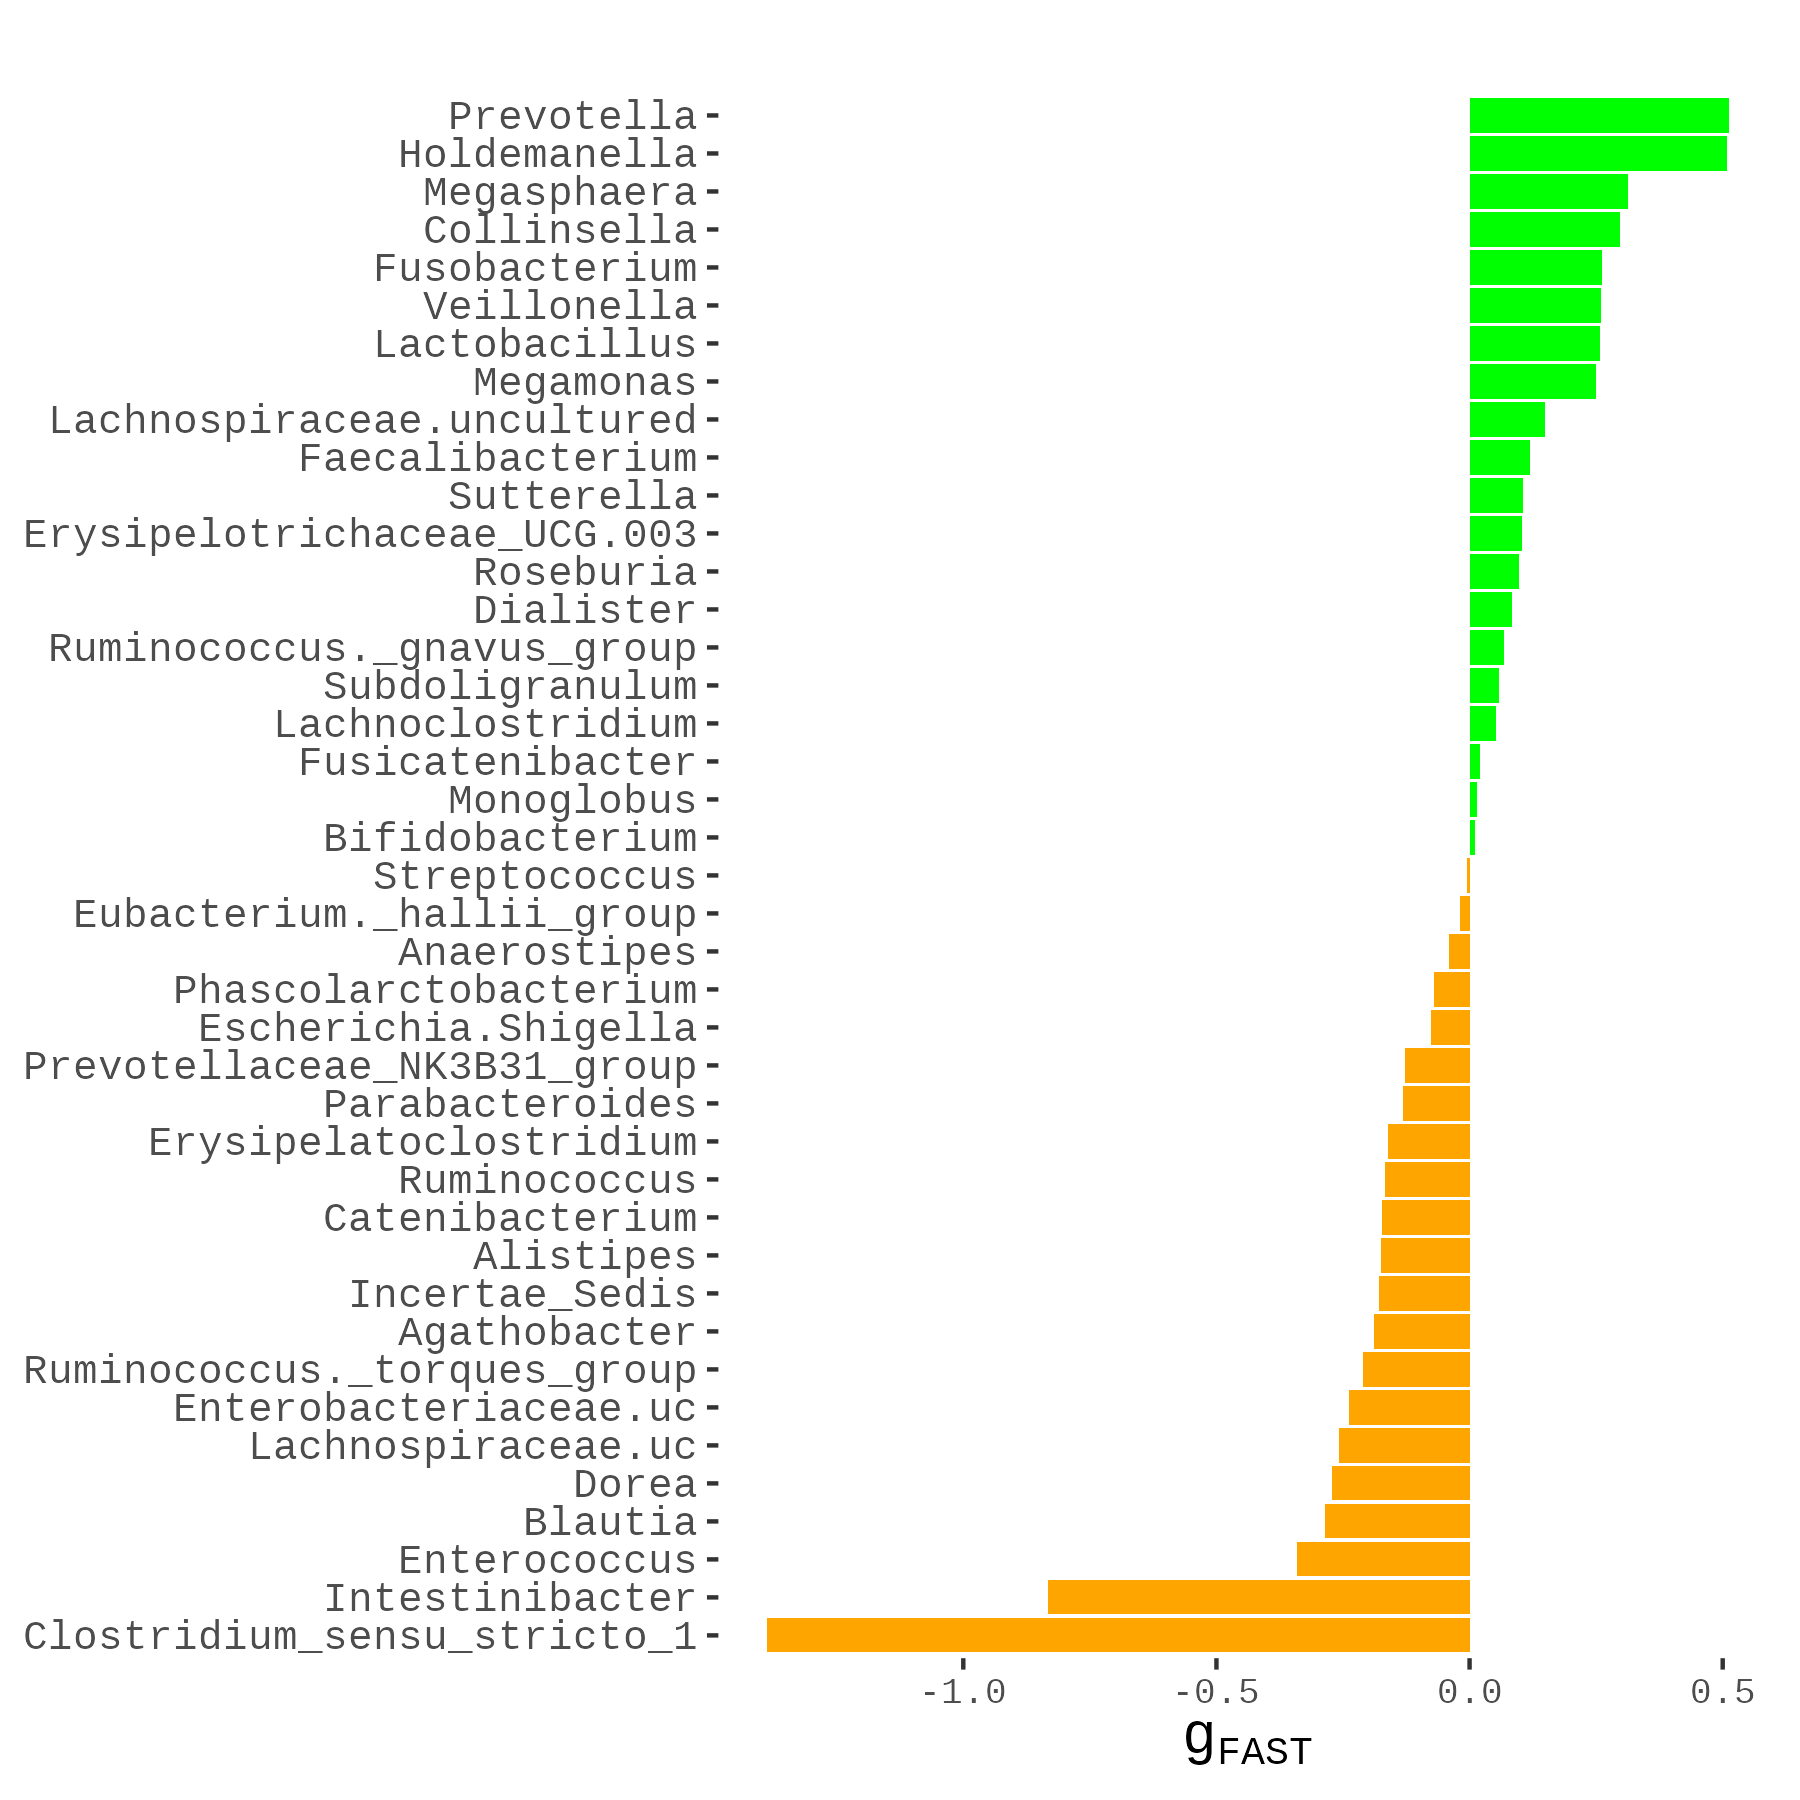

In [ ]:
display(Image(out+"g_FAST_bar.png", width=600))

Below, this result is compared with a simple correlation (Spearman's Rho) between the abundance of taxonomic groups and FAST scores ($\boldsymbol{\rho}$_FASTscore).

In [ ]:
%%R
# 0. Combining g_
corr <- result$correlation_table$SpearmanRho #need to run microbiome_continuous_analysis first #
#########
ge <- ge0 / 5 ### g_FASTscore is rescaled ##
#########
combined_df <- data.frame(label = rownames(ge0), g_FASTscore = as.numeric(ge), Correlation = corr)

# 1. Sort the samples by Correlation (descending) and fix the label order (top = highest)
combined_df <- combined_df %>%
  arrange(desc(Correlation)) %>%
  mutate(label = factor(label, levels = rev(label)))



In [ ]:
%%R
cor.test(combined_df$g_FASTscore, combined_df$Correlation, method = "spearman")


	Spearman's rank correlation rho

data:  combined_df$g_FASTscore and combined_df$Correlation
S = 2908, p-value = 1.848e-07
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.7466899 



The following shows the 2D plot of g_FASTscore and Correlation

In [ ]:
%%R
install.packages("ggrepel")

`geom_smooth()` using formula = 'y ~ x'


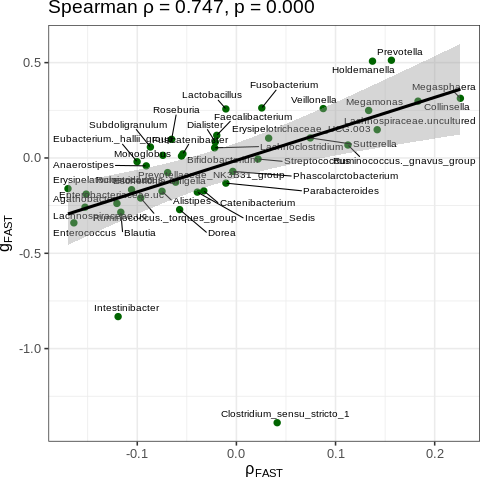

In [ ]:
%%R
library(ggrepel)

ge <- ge0

# Spearman correlation test
cor_test <- suppressWarnings(cor.test(corr, ge, method = "spearman"))
rho_val <- sprintf("%.3f", cor_test$estimate)
p_val   <- sprintf("%.3f", cor_test$p.value)

# Create data frame
corr.vs.ge_df <- data.frame(Correlation = corr, g_FAST = ge)

# Generate plot
corr.vs.ge_plot <- ggplot(corr.vs.ge_df, aes(x = Correlation, y = ge)) +
  geom_point(color = "darkgreen", size = 2.5) +
  geom_text_repel(aes(label = rownames(corr.vs.ge_df)),
                  size = 3.5, max.overlaps = 50, box.padding = 0.3) +
  geom_smooth(method = "lm", color = "black", se = TRUE) +
  labs(
    x = expression(rho[FAST]),
    y = expression(g[FAST]),
    title = paste0(
      "Spearman \u03C1 = ", rho_val, ", p = ", p_val
    )
  ) +
  theme_bw(base_size = 16) +
  theme(
    plot.margin = margin(0, 0, 0, 0),
    plot.title = element_text(lineheight = 1.2)
  )

# Display plot
corr.vs.ge_plot

`geom_smooth()` using formula = 'y ~ x'


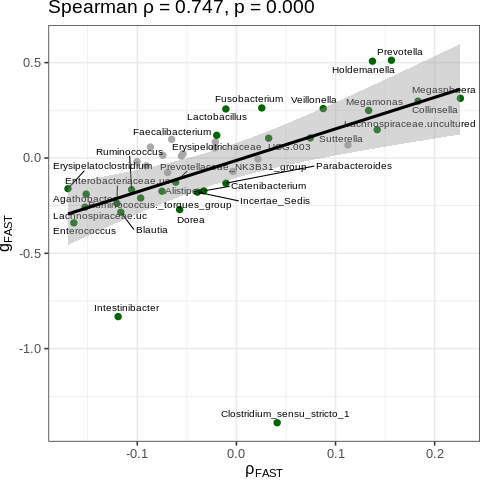

In [ ]:
%%R

# Add filtered label column to the data frame
corr.vs.ge_df$label <- ifelse(abs(corr.vs.ge_df$FAST_score) > 0.1,
                              rownames(corr.vs.ge_df), NA)

# Define point color based on label presence
corr.vs.ge_df$point_color <- ifelse(is.na(corr.vs.ge_df$label), "darkgray", "darkgreen")

# Plot
corr.vs.ge_plot <- ggplot(corr.vs.ge_df, aes(x = Correlation, y = ge)) +
  geom_point(aes(color = point_color), size = 2.5) +
  geom_text_repel(aes(label = label),
                  size = 3.5, max.overlaps = 50, box.padding = 0.3) +
  geom_smooth(method = "lm", color = "black", se = TRUE) +
  labs(
    x = expression(rho[FAST]),
    y = expression(g[FAST]),
    title = paste0("Spearman \u03C1 = ", rho_val, ", p = ", p_val)
  ) +
  scale_color_identity() +  # Use colors directly from 'point_color'
  theme_bw(base_size = 16) +
  theme(
    plot.margin = margin(0, 0, 0, 0),
    plot.title = element_text(lineheight = 1.2)
  )

# Display
corr.vs.ge_plot

### Netowork analysis

In [ ]:
%%R
# Assume 'mat' is a matrix
connectance <- function(mat) {
  n_possible <- prod(dim(mat))                 # Total number of possible links
  n_actual   <- sum(mat != 0, na.rm = TRUE)    # Non-zero entries = actual links
  return(n_actual / n_possible)                # Connectance = actual / possible
}

connectance(je0)

[1] 0.97442


Next, calculate the correlation matrix from the abundance table using SparCC.

In [ ]:
#%%R
# Interaction (association) network inference by sparCC (using SPIEC-EASI library)
#install.packages("devtools")
#devtools::install_github("zdk123/SpiecEasi", upgrade = "always")

In [ ]:
#%%R
#library(SpiecEasi)
#sparcc_res <- sparcc(abmat_filtered)
# SparCC correlation matrix
#sparcc_cor_mat <- sparcc_res$Cor
#colnames(sparcc_cor_mat) <- rownames(sparcc_cor_mat) <- specieslabel

Visualisation of J using a circular map

In [ ]:
%%R
network_res <- plot_interaction_network(
  cor_mat = as.matrix(je0),
  node_score = ge0,
  threshold_ratio = 0.8,
  device = c("png", "eps"),
  file = file.path(out,"network"),
  width_in = 6.5,
  height_in = 6.5,
  res_dpi = 300
)

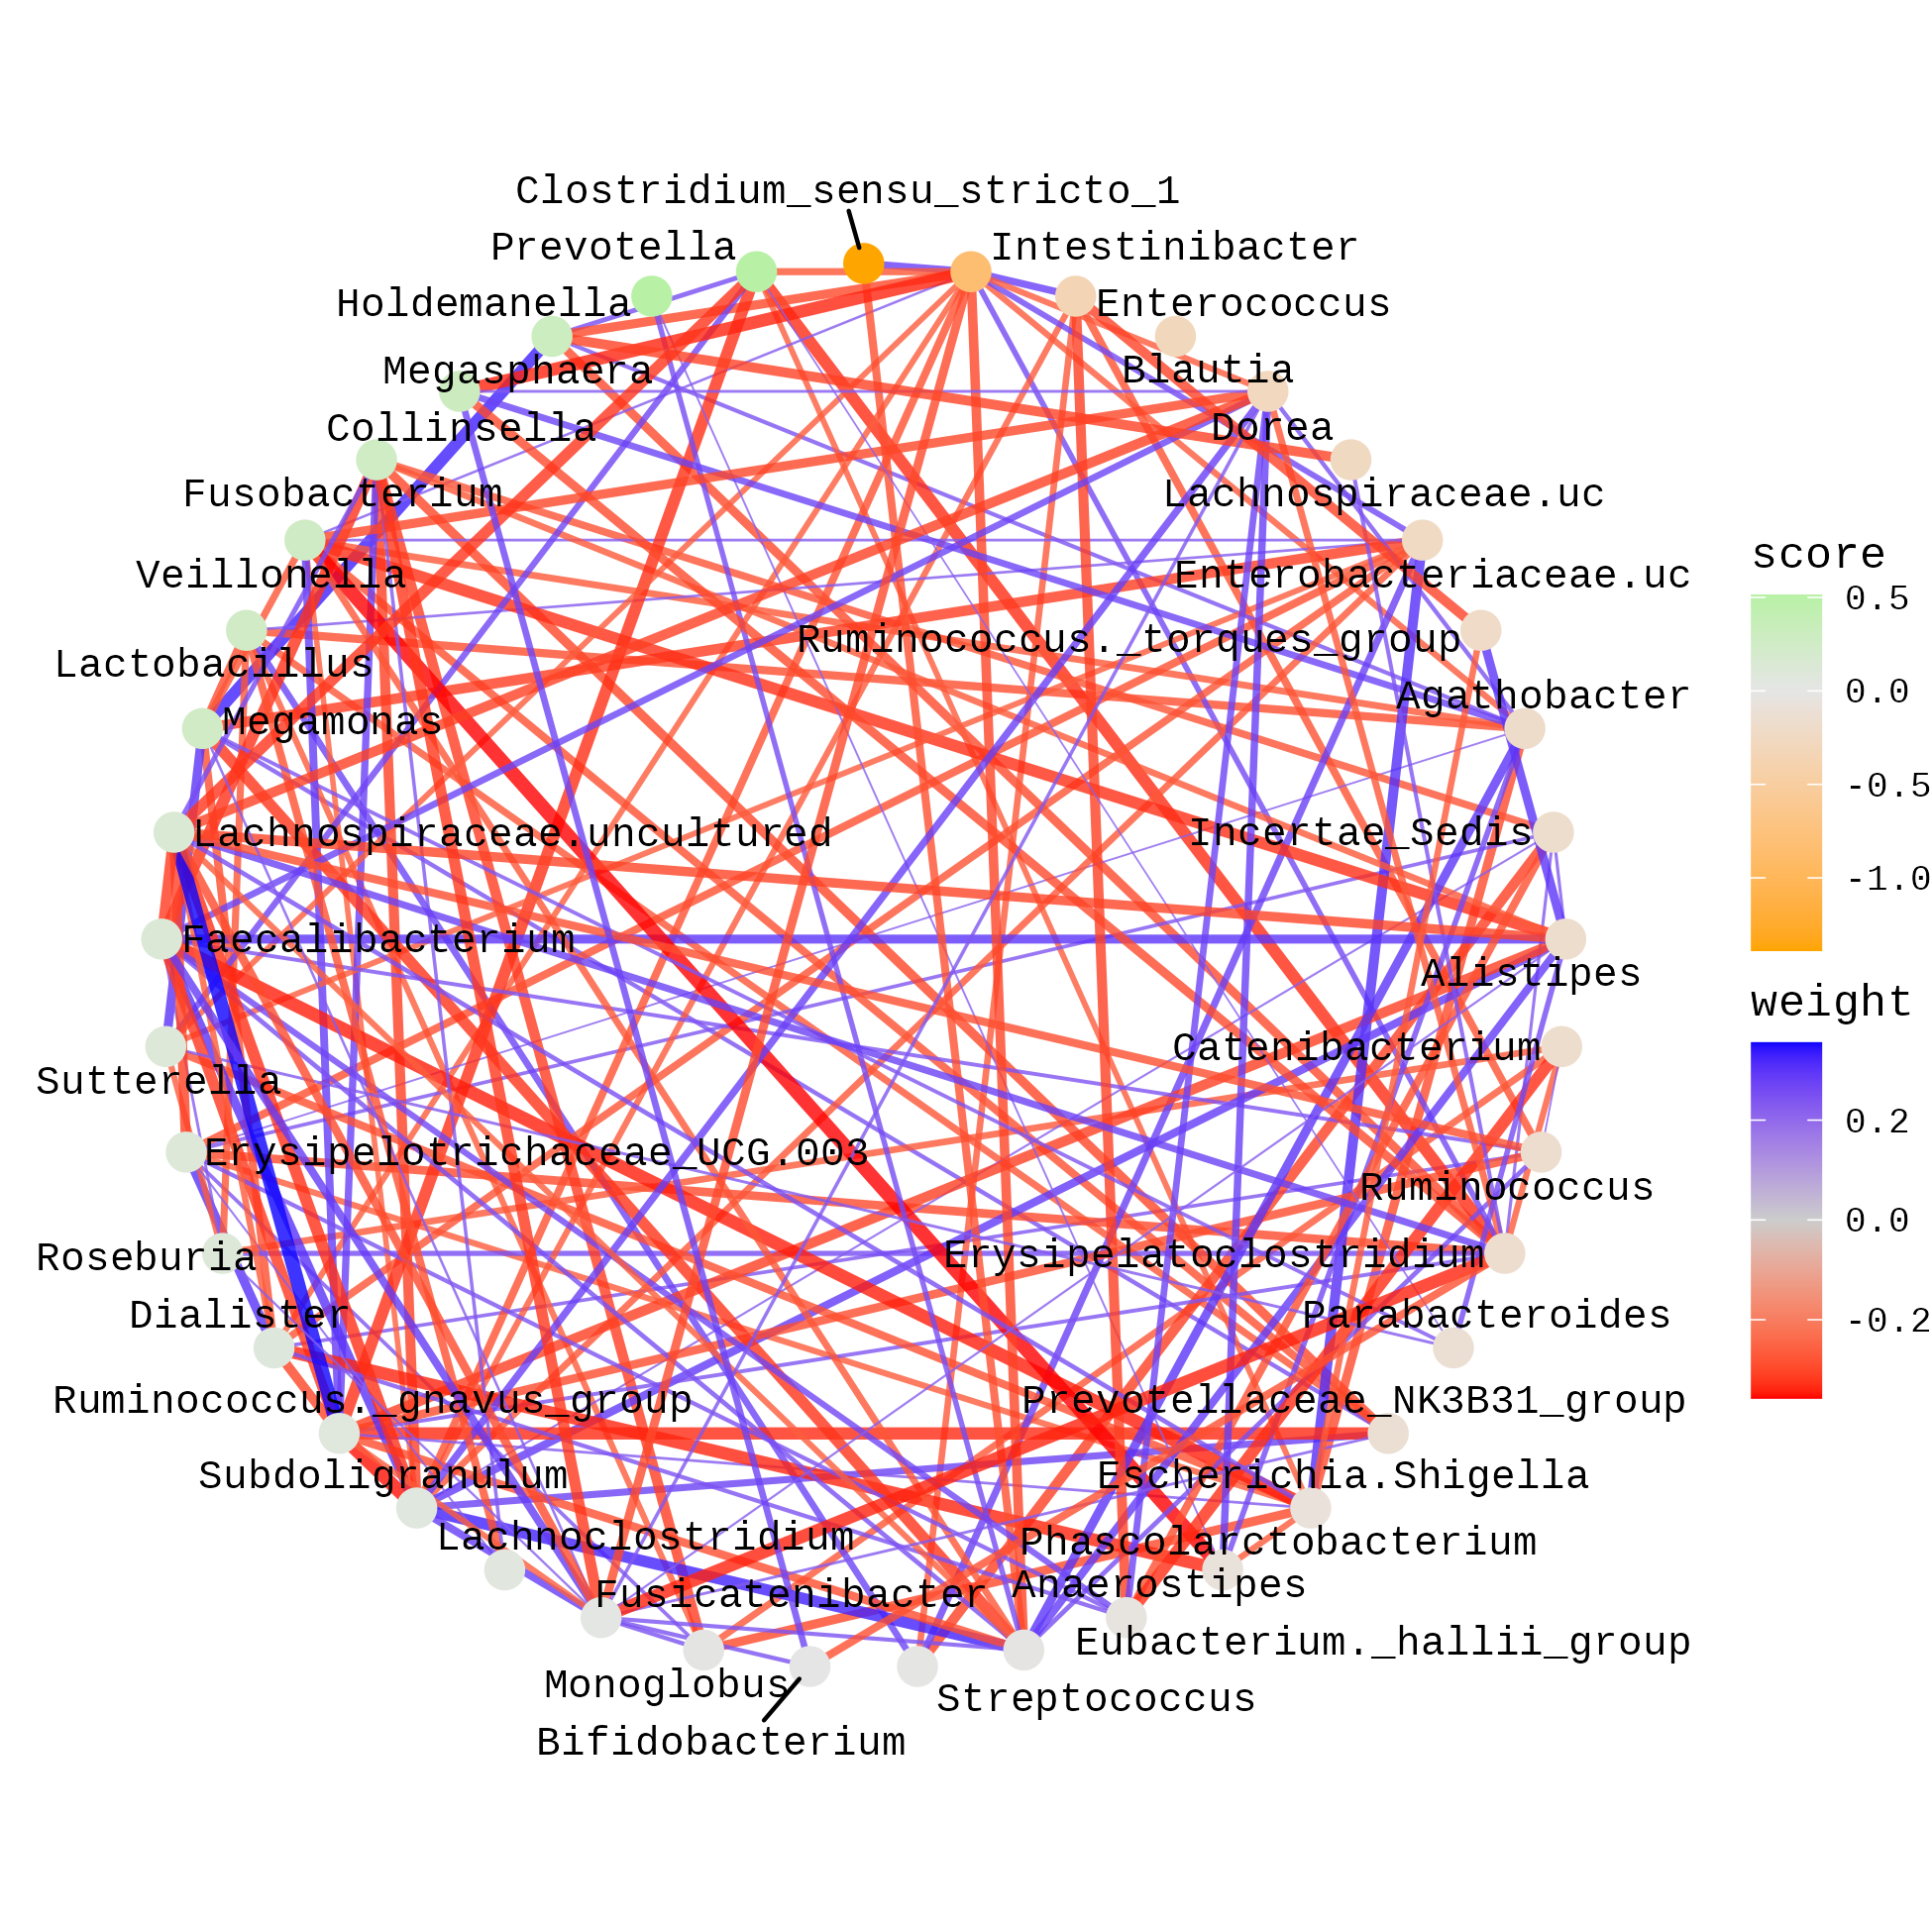

In [ ]:
display(Image(out+"network.png", width=600))

Below, it is tested whether the relationships between nodes with negative g_FAST values are biased toward positive relationships (J_ij > 0).

In [ ]:
%%R

## ============================================================
## Test whether taxa with similar g_FAST tend to have negative J
## ============================================================

set.seed(123)

## ------------------------------------------------------------
## 0. Threshold J matrix
## ------------------------------------------------------------

cor_mat <- threshold_correlation_matrix(as.matrix(je0), 0.)
diag(cor_mat) <- 0

edges <- which(abs(cor_mat) > 0 & upper.tri(cor_mat), arr.ind = TRUE)

edge_df <- data.frame(
  from   = rownames(cor_mat)[edges[, 1]],
  to     = colnames(cor_mat)[edges[, 2]],
  weight = cor_mat[edges],
  stringsAsFactors = FALSE
)

## ------------------------------------------------------------
## 1. Node scores: g_FAST
## ------------------------------------------------------------

if (is.matrix(ge0) || is.data.frame(ge0)) {
  node_score <- as.numeric(ge0[, 1])
  names(node_score) <- rownames(ge0)
} else {
  node_score <- as.numeric(ge0)
  names(node_score) <- rownames(cor_mat)
}

## Align to J matrix
node_score <- node_score[rownames(cor_mat)]

## ------------------------------------------------------------
## 2. Add g_FAST information to each edge
## ------------------------------------------------------------

edge_df$g_from <- node_score[edge_df$from]
edge_df$g_to   <- node_score[edge_df$to]

edge_df$g_distance <- abs(edge_df$g_from - edge_df$g_to)

## Similarity version:
## larger value = more similar environmental preference
edge_df$g_similarity <- -edge_df$g_distance

edge_df$edge_sign <- sign(edge_df$weight)

edge_df$same_g_sign <- (
  sign(edge_df$g_from) != 0 &
  sign(edge_df$g_to)   != 0 &
  sign(edge_df$g_from) == sign(edge_df$g_to)
)

edge_df$opposite_g_sign <- (
  sign(edge_df$g_from) != 0 &
  sign(edge_df$g_to)   != 0 &
  sign(edge_df$g_from) == -sign(edge_df$g_to)
)

edge_df$negative_J <- edge_df$weight < 0
edge_df$positive_J <- edge_df$weight > 0

## ------------------------------------------------------------
## 3. Continuous test
##
## Manuscript-consistent interpretation:
## If taxa with similar g_FAST tend to be mutually exclusive,
## then larger g_similarity should be associated with smaller J.
##
## Therefore, expected rho(g_similarity, J) < 0.
## ------------------------------------------------------------

observed_rho_similarity_J <- suppressWarnings(
  cor(
    edge_df$g_similarity,
    edge_df$weight,
    method = "spearman",
    use = "complete.obs"
  )
)

n_perm <- 1000

perm_rho_similarity_J <- replicate(n_perm, {
  permuted_scores <- setNames(
    sample(node_score),
    names(node_score)
  )

  g_from_p <- permuted_scores[edge_df$from]
  g_to_p   <- permuted_scores[edge_df$to]

  g_similarity_p <- -abs(g_from_p - g_to_p)

  suppressWarnings(
    cor(
      g_similarity_p,
      edge_df$weight,
      method = "spearman",
      use = "complete.obs"
    )
  )
})

## One-sided p-value:
## probability that random permutation gives rho <= observed rho
## because expected direction is negative.
p_value_similarity_negative <- mean(
  perm_rho_similarity_J <= observed_rho_similarity_J,
  na.rm = TRUE
)

## ------------------------------------------------------------
## 4. Sign-based test
##
## Coarse version of the same idea:
## taxa on the same side of g_FAST should more often have negative J.
## ------------------------------------------------------------

observed_negative_rate_same_sign <- with(
  edge_df,
  mean(negative_J[same_g_sign], na.rm = TRUE)
)

perm_negative_rate_same_sign <- replicate(n_perm, {
  permuted_scores <- setNames(
    sample(node_score),
    names(node_score)
  )

  sa <- sign(permuted_scores[edge_df$from])
  sb <- sign(permuted_scores[edge_df$to])

  same_sign_p <- (
    sa != 0 &
    sb != 0 &
    sa == sb
  )

  if (sum(same_sign_p, na.rm = TRUE) == 0) {
    return(NA_real_)
  }

  mean(edge_df$negative_J[same_sign_p], na.rm = TRUE)
})

## One-sided p-value:
## probability that random permutation gives negative-J rate >= observed rate
p_value_same_sign_negative <- mean(
  perm_negative_rate_same_sign >= observed_negative_rate_same_sign,
  na.rm = TRUE
)

## ------------------------------------------------------------
## 5. Optional: opposite-sign pairs
##
## This is not the main manuscript interpretation, but useful as a contrast.
## ------------------------------------------------------------

observed_negative_rate_opposite_sign <- with(
  edge_df,
  mean(negative_J[opposite_g_sign], na.rm = TRUE)
)

observed_positive_rate_opposite_sign <- with(
  edge_df,
  mean(positive_J[opposite_g_sign], na.rm = TRUE)
)

## ------------------------------------------------------------
## 6. Summary output
## ------------------------------------------------------------

summary_list <- list(
  n_edges = nrow(edge_df),

  continuous_test = list(
    hypothesis = "higher g_FAST similarity is associated with more negative J",
    observed_rho_similarity_J = observed_rho_similarity_J,
    p_value_one_sided_negative = p_value_similarity_negative
  ),

  sign_based_test = list(
    hypothesis = "same-sign g_FAST pairs are enriched for negative J",
    observed_negative_rate_same_sign = observed_negative_rate_same_sign,
    p_value_one_sided_enrichment = p_value_same_sign_negative
  ),

  contrast_opposite_sign = list(
    observed_negative_rate_opposite_sign = observed_negative_rate_opposite_sign,
    observed_positive_rate_opposite_sign = observed_positive_rate_opposite_sign
  ),

  edge_sign_table = table(
    edge_sign = edge_df$edge_sign,
    useNA = "ifany"
  ),

  same_sign_table = table(
    same_g_sign = edge_df$same_g_sign,
    negative_J = edge_df$negative_J,
    useNA = "ifany"
  )
)

summary_list

$n_edges
[1] 819

$continuous_test
$continuous_test$hypothesis
[1] "higher g_FAST similarity is associated with more negative J"

$continuous_test$observed_rho_similarity_J
[1] 0.1188303

$continuous_test$p_value_one_sided_negative
[1] 0.989


$sign_based_test
$sign_based_test$hypothesis
[1] "same-sign g_FAST pairs are enriched for negative J"

$sign_based_test$observed_negative_rate_same_sign
[1] 0.5213033

$sign_based_test$p_value_one_sided_enrichment
[1] 0.765


$contrast_opposite_sign
$contrast_opposite_sign$observed_negative_rate_opposite_sign
[1] 0.5404762

$contrast_opposite_sign$observed_positive_rate_opposite_sign
[1] 0.4595238


$edge_sign_table
edge_sign
 -1   1 
435 384 

$same_sign_table
           negative_J
same_g_sign FALSE TRUE
      FALSE   193  227
      TRUE    191  208



Using the Mantel test, we evaluate the similarity between the distance matrix calculated based on rho_FASTscore (g_FASTscore) and the SparCC correlation matrix (J). If this statistic is high, the SparCC correlation is strongly influenced by theassociation between abundance and FASTscore.

The following code may update several packages. Please run it with caution.

In [ ]:
%%R
# Interaction (association) network inference by sparCC (using SPIEC-EASI library)
options(repos = c(
  spieceasi = "https://bioc.r-universe.dev",
  CRAN = "https://cloud.r-project.org"
))

install.packages(
  "SpiecEasi",
  dependencies = TRUE
)

library(SpiecEasi)

In [ ]:
%%R
sparcc_res <- sparcc(abmat_filtered)
# SparCC correlation matrix
sparcc_cor_mat <- sparcc_res$Cor
colnames(sparcc_cor_mat) <- rownames(sparcc_cor_mat) <- specieslabel

In [ ]:
%%R
# 1. Compute distance matrix from sample_vector (e.g., Euclidean)
# 2. Compute distance matrix from sample_mat (e.g., Bray-Curtis)
# 3. Perform Mantel test between the two distance matrices

print("rho_FASTscore and SparCC")
dist_vector <- dist(as.vector(result$correlation_table$SpearmanRho), method = "euclidean")
dist_matrix <- sparcc_cor_mat
mantel_result <- mantel(dist_vector, dist_matrix, method = "pearson", permutations = 999)
print(mantel_result)

print("g_FASTscore and j")
dist_vector <- dist(as.vector(ge0), method = "euclidean")
dist_matrix <- threshold_correlation_matrix(as.matrix(je0), 0.8)
mantel_result <- mantel(dist_vector, dist_matrix, method = "pearson", permutations = 999)
print(mantel_result)

print("SparCC and j")
dist_vector <- threshold_correlation_matrix(sparcc_cor_mat, 0.8)
dist_matrix <- threshold_correlation_matrix(as.matrix(je0), 0.8)
mantel_result <- mantel(dist_vector, dist_matrix, method = "pearson", permutations = 999)
print(mantel_result)

In [ ]:
%%R
## ------------------------------------------------------------
## Threshold–Mantel sensitivity plot
##   1st row: Mantel r
##   2nd row: -log10(p)
##   3rd row: number of retained J links
## ------------------------------------------------------------

library(vegan)
library(ggplot2)

## If not already defined, define the thresholding function
threshold_correlation_matrix <- function(cor_mat, X_ratio = 0.2) {
  if (!is.matrix(cor_mat)) stop("Input must be a matrix.")
  if (X_ratio < 0 || X_ratio > 1) stop("X_ratio must be between 0 and 1.")

  cor_mat_filtered <- cor_mat

  ## Flatten the matrix excluding diagonal
  upper_vals <- cor_mat[upper.tri(cor_mat)]
  lower_vals <- cor_mat[lower.tri(cor_mat)]

  ## Positive values
  pos_vals <- upper_vals[upper_vals > 0]
  if (length(pos_vals) > 0) {
    pos_thresh <- as.numeric(
      quantile(pos_vals, probs = X_ratio, na.rm = TRUE)
    )
    cor_mat_filtered[cor_mat > 0 & cor_mat < pos_thresh] <- 0
  }

  ## Negative values
  neg_vals <- lower_vals[lower_vals < 0]
  if (length(neg_vals) > 0) {
    neg_thresh <- as.numeric(
      quantile(neg_vals, probs = 1 - X_ratio, na.rm = TRUE)
    )
    cor_mat_filtered[cor_mat < 0 & cor_mat > neg_thresh] <- 0
  }

  diag(cor_mat_filtered) <- 0

  return(cor_mat_filtered)
}

## ------------------------------------------------------------
## Settings
## ------------------------------------------------------------

thresholds <- seq(0., 0.9, 0.05)
nperm <- 999

## ------------------------------------------------------------
## Helper functions
## ------------------------------------------------------------

run_mantel_safe <- function(x, y, method = "pearson", permutations = 999) {
  res <- vegan::mantel(
    x,
    y,
    method = method,
    permutations = permutations
  )

  c(
    r = unname(res$statistic),
    p = res$signif
  )
}

count_j_links <- function(j_mat) {
  ## Count retained undirected links in the upper triangle.
  sum(abs(j_mat[upper.tri(j_mat)]) > 0, na.rm = TRUE)
}

count_j_positive_links <- function(j_mat) {
  sum(j_mat[upper.tri(j_mat)] > 0, na.rm = TRUE)
}

count_j_negative_links <- function(j_mat) {
  sum(j_mat[upper.tri(j_mat)] < 0, na.rm = TRUE)
}

## ------------------------------------------------------------
## Run sensitivity analysis across thresholds
## ------------------------------------------------------------

result_list <- lapply(thresholds, function(th) {

  ## J matrix after thresholding
  j_mat <- threshold_correlation_matrix(
    as.matrix(je0),
    X_ratio = th
  )

  ## Count retained J links
  n_j_links <- count_j_links(j_mat)
  n_j_pos_links <- count_j_positive_links(j_mat)
  n_j_neg_links <- count_j_negative_links(j_mat)

  ## 1) g_FASTscore vs J
  gfast_vec <- as.vector(ge0)
  gfast_dist <- dist(gfast_vec, method = "euclidean")

  res_gfast <- run_mantel_safe(
    x = gfast_dist,
    y = j_mat,
    method = "pearson",
    permutations = nperm
  )

  ## 2) SparCC vs J
  sparcc_mat <- threshold_correlation_matrix(
    as.matrix(sparcc_cor_mat),
    X_ratio = th
  )

  res_sparcc <- run_mantel_safe(
    x = sparcc_mat,
    y = j_mat,
    method = "pearson",
    permutations = nperm
  )

  data.frame(
    threshold = th,
    comparison = c("g_FASTscore vs J", "SparCC vs J"),
    mantel_r = c(res_gfast["r"], res_sparcc["r"]),
    p_value = c(res_gfast["p"], res_sparcc["p"]),
    n_j_links = n_j_links,
    n_j_positive_links = n_j_pos_links,
    n_j_negative_links = n_j_neg_links,
    stringsAsFactors = FALSE
  )
})

mantel_df <- do.call(rbind, result_list)

## Avoid Inf in -log10(p)
mantel_df$neglog10_p <- -log10(
  pmax(mantel_df$p_value, .Machine$double.xmin)
)

print(mantel_df)

## ------------------------------------------------------------
## Prepare plotting data
## ------------------------------------------------------------

plot_df_r <- data.frame(
  threshold = mantel_df$threshold,
  comparison = mantel_df$comparison,
  metric = "Mantel r",
  value = mantel_df$mantel_r,
  stringsAsFactors = FALSE
)

plot_df_p <- data.frame(
  threshold = mantel_df$threshold,
  comparison = mantel_df$comparison,
  metric = "-log10(p)",
  value = mantel_df$neglog10_p,
  stringsAsFactors = FALSE
)

plot_df <- rbind(plot_df_r, plot_df_p)

plot_df$comparison <- factor(
  plot_df$comparison,
  levels = c("g_FASTscore vs J", "SparCC vs J")
)

plot_df$metric <- factor(
  plot_df$metric,
  levels = c("Mantel r", "-log10(p)")
)

## J link count data:
## one row per threshold is enough, so remove duplicated rows
j_link_df <- unique(
  mantel_df[, c(
    "threshold",
    "n_j_links",
    "n_j_positive_links",
    "n_j_negative_links"
  )]
)

## Reference line only for the p-value panel
ref_df <- data.frame(
  metric = factor("-log10(p)", levels = levels(plot_df$metric)),
  yint = -log10(0.05)
)

## ------------------------------------------------------------
## Plot panels separately and combine
## ------------------------------------------------------------

p_r <- ggplot(
  subset(plot_df, metric == "Mantel r"),
  aes(x = threshold, y = value, color = comparison)
) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2.5) +
  scale_color_manual(
    values = c(
      "g_FASTscore vs J" = "#D55E00",
      "SparCC vs J" = "#0072B2"
    )
  ) +
  labs(
    x = NULL,
    y = "Mantel r",
    color = NULL
  ) +
  theme_bw(base_size = 13) +
  theme(
    legend.position = "top"
  )

p_p <- ggplot(
  subset(plot_df, metric == "-log10(p)"),
  aes(x = threshold, y = value, color = comparison)
) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2.5) +
  geom_hline(
    yintercept = -log10(0.05),
    linetype = "dashed",
    color = "gray40"
  ) +
  scale_color_manual(
    values = c(
      "g_FASTscore vs J" = "#D55E00",
      "SparCC vs J" = "#0072B2"
    )
  ) +
  labs(
    x = NULL,
    y = expression(-log[10](p)),
    color = NULL
  ) +
  theme_bw(base_size = 13) +
  theme(
    legend.position = "none"
  )

p_links <- ggplot(
  j_link_df,
  aes(x = threshold, y = n_j_links)
) +
  geom_line(color = "black", linewidth = 0.9) +
  geom_point(color = "black", size = 2.5) +
  scale_y_continuous(limits = c(0, NA)) +
  labs(
    x = "Threshold",
    y = "Retained J links"
  ) +
  theme_bw(base_size = 13) +
  theme(
    legend.position = "none"
  )

## Combine vertically
if (!requireNamespace("patchwork", quietly = TRUE)) {
  install.packages("patchwork")
}

p <- p_r / p_p / p_links +
  patchwork::plot_layout(heights = c(1, 1, 0.8)) +
  patchwork::plot_annotation(
    title = "Threshold–Mantel sensitivity plot"
  )

print(p)

## ------------------------------------------------------------
## Save
## ------------------------------------------------------------

ggsave(
  "threshold_mantel_sensitivity.png",
  plot = p,
  width = 6.5,
  height = 8.5,
  dpi = 300,
  bg = "white"
)

if (capabilities("cairo")) {
  ggsave(
    "threshold_mantel_sensitivity.eps",
    plot = p,
    device = function(...) {
      grDevices::cairo_ps(
        ...,
        onefile = FALSE,
        fallback_resolution = 300
      )
    },
    width = 6.5,
    height = 8.5,
    units = "in",
    bg = "white"
  )
} else {
  ggsave(
    "threshold_mantel_sensitivity.eps",
    plot = p,
    device = "eps",
    width = 6.5,
    height = 8.5,
    units = "in",
    bg = "white"
  )
}

### Prediction of FAST score from microbiome

In [ ]:
%%R
# Load required packages
##install.packages('randomForest')
install.packages('xgboost')
install.packages('ranger')
install.packages('e1071')
install.packages('Metrics')
##library(randomForest)
library(xgboost)
library(ranger)
library(e1071)
library(Metrics)  # for rmse, r-squared

The `evaluate_models_cv` function performs a comprehensive comparison of predictive modeling techniques using microbiome composition data to predict a continuous target variable (e.g., an environmental or clinical parameter). The function operates as follows:

* **Cross-validation setup:** Implements a 10-fold cross-validation repeated 5 times, ensuring robust performance estimates across different data splits.
* **Model training and evaluation:** For each fold, four regression models are trained—Linear Regression, Support Vector Regression (SVR), Random Forest (via `ranger`), and XGBoost. Predictions are made on test sets for each model.
* **Performance metrics:** Depending on the selected `metric` ("correlation", "rmse", or "rsq"), model performance is evaluated using Pearson correlation, Root Mean Square Error, or R-squared, respectively.
* **External results integration:** Optionally, external performance scores can be supplied and included in the final visualization.
* **Visualization:** A boxplot with jittered points is generated using `ggplot2` to display the cross-validated performance of each model across all folds.

This function is particularly useful for benchmarking regression models that predict continuous variables from high-dimensional microbiome data, supporting metric flexibility and visual comparison.


In [ ]:
%%R
evaluate_models_cv <- function(microbiome_mat, metadata_mat, target_index, external_scores = NULL, metric = c("correlation", "rmse", "rsq")) {

  metric <- match.arg(metric)

  common_samples <- intersect(rownames(microbiome_mat), rownames(metadata_mat))
  if (length(common_samples) == 0) {
    stop("Error: No matching sample IDs between microbiome data and metadata.")
  }
  microbiome_sub <- microbiome_mat[common_samples, , drop=FALSE]
  metadata_sub   <- metadata_mat[common_samples, , drop=FALSE]

  target_vals <- as.numeric(metadata_sub[, target_index])
  complete_idx <- complete.cases(microbiome_sub) & !is.na(target_vals)
  microbiome_sub <- microbiome_sub[complete_idx, , drop=FALSE]
  target_vals    <- target_vals[complete_idx]

  set.seed(123)
  n <- nrow(microbiome_sub)
  K <- 10 # k-folds
  n_rep <- 20
  folds_list <- list()

  for (rep in 1:n_rep) {
    idx_shuffled <- sample(n)
    fold_sizes <- rep(floor(n / K), K)
    remainder <- n %% K
    if (remainder > 0) {
      fold_sizes[1:remainder] <- fold_sizes[1:remainder] + 1
    }
    start <- 1
    for (k in 1:K) {
      end <- start + fold_sizes[k] - 1
      test_idx <- idx_shuffled[start:end]
      train_idx <- setdiff(seq_len(n), test_idx)
      folds_list[[paste0("Rep", rep, "_Fold", k)]] <- list(train = train_idx, test = test_idx)
      start <- end + 1
    }
  }

  corr_results <- list(LR = c(), SVR = c(), RF = c())#, XGB = c())

  for (fold_name in names(folds_list)) {
    idx_train <- folds_list[[fold_name]]$train
    idx_test  <- folds_list[[fold_name]]$test

    X_train <- microbiome_sub[idx_train, , drop=FALSE]
    y_train <- target_vals[idx_train]
    X_test  <- microbiome_sub[idx_test, , drop=FALSE]
    y_test  <- target_vals[idx_test]

    train_df <- data.frame(target = y_train, X_train)
    lm_model <- lm(target ~ ., data = train_df)
    lm_pred  <- predict(lm_model, newdata = data.frame(X_test))

    svr_model <- svm(x = X_train, y = y_train, type = "eps-regression")
    svr_pred  <- predict(svr_model, X_test)

    train_df_rf <- data.frame(target = y_train, X_train)
    rf_model <- ranger(target ~ ., data = train_df_rf)
    rf_pred  <- predict(rf_model, data = data.frame(X_test))$predictions

    #dtrain <- xgb.DMatrix(data = as.matrix(X_train), label = y_train)
    #dtest  <- xgb.DMatrix(data = as.matrix(X_test), label = y_test)
    #xgb_model <- xgboost(data = dtrain, objective = "reg:squarederror", nrounds = 100, verbose = 0)
    #xgb_pred  <- predict(xgb_model, newdata = dtest)

    for (method in c("LR", "SVR", "RF")) {#, "XGB")) {
      pred <- switch(method,
                     LR  = lm_pred,
                     SVR = svr_pred,
                     RF  = rf_pred)#,XGB = xgb_pred)

      if (length(y_test) > 1) {
        score <- switch(metric,
                        correlation = cor(y_test, pred, method = "spearman"),
                        rmse        = sqrt(mean((y_test - pred)^2)),
                        rsq         = {
                          ss_res <- sum((y_test - pred)^2)
                          ss_tot <- sum((y_test - mean(y_test))^2)
                          1 - ss_res / ss_tot
                        })
        corr_results[[method]] <- c(corr_results[[method]], score)
      }
    }
  }

  method_names <- names(corr_results)
  results_df <- data.frame(
    Method = factor(rep(method_names, times = sapply(corr_results, length)), levels = method_names),
    MetricValue = unlist(corr_results, use.names = FALSE)
  )

  if (!is.null(external_scores)) {
    colnames(external_scores) <- c("Method", "MetricValue")
    external_scores$Method <- factor(external_scores$Method, levels = union(levels(results_df$Method), unique(external_scores$Method)))
    results_df$Method <- factor(results_df$Method, levels = levels(external_scores$Method))
    results_df <- rbind(results_df, external_scores)
  }

  y_label <- switch(metric,
                    correlation = "Spearman Correlation",
                    rmse        = "RMSE",
                    rsq         = "R-squared")

  p <- ggplot(results_df, aes(x = Method, y = MetricValue, fill = Method)) +
    geom_boxplot(alpha = 0.7, outlier.shape = NA) +
    geom_jitter(width = 0.2, color = "gray40", alpha = 0.6) +
    scale_y_continuous(name = y_label) +
    labs(x = "Model") +
    theme_bw(base_size = 16) +
    theme(
      axis.title.x = element_text(size = 18),
      axis.title.y = element_text(size = 18),
      axis.text.x  = element_text(size = 16),
      axis.text.y  = element_text(size = 16),
      legend.position = "none"
    )

  # Summarize statistics per model
  results_df_summary <- aggregate(MetricValue ~ Method, data = results_df, FUN = function(x) {
    c(mean = mean(x), sd = sd(x), min = min(x), Q1 = quantile(x, 0.25),
      median = median(x), Q3 = quantile(x, 0.75), max = max(x))
  })

  # Expand into wide format
  results_df_summary <- do.call(data.frame, results_df_summary)
  colnames(results_df_summary) <- c("Method", "Mean", "SD", "Min", "Q1", "Median", "Q3", "Max")

  return(list(plot = p, summary_table = results_df_summary))
}


$plot

$summary_table
  Method       Mean        SD        Min          Q1      Median        Q3
1     LR 0.12439005 0.3168171 -0.6219628 -0.06032834 0.143342490 0.3462505
2    SVR 0.08537143 0.3067836 -0.7790453 -0.10604067 0.094086989 0.2818182
3     RF 0.03060111 0.2815703 -0.6524512 -0.16049938 0.009090909 0.2242424
        Max
1 0.8545455
2 0.8545455
3 0.8181818



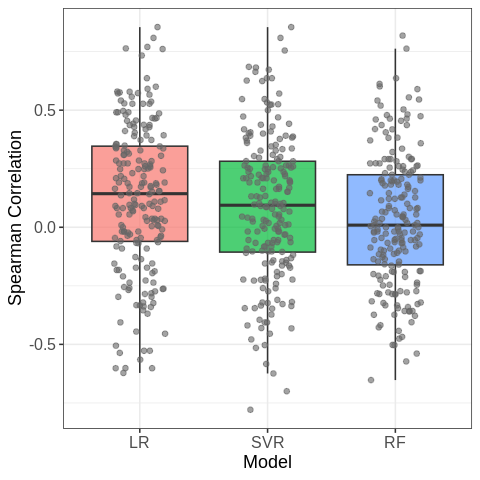

In [ ]:
%%R
# test 1
evaluate_models_cv(abmat_filtered, enmat_p_filtered, 1, metric = "correlation")

$plot

$summary_table
  Method      Mean        SD       Min        Q1    Median       Q3      Max
1     LR 1.2270074 0.2719217 0.4922364 1.0614864 1.2174819 1.371868 2.959860
2    SVR 1.0088506 0.1451524 0.5918264 0.9189530 0.9977482 1.115287 1.509193
3     RF 0.9972114 0.1434845 0.6625221 0.8966604 0.9944546 1.107329 1.456646



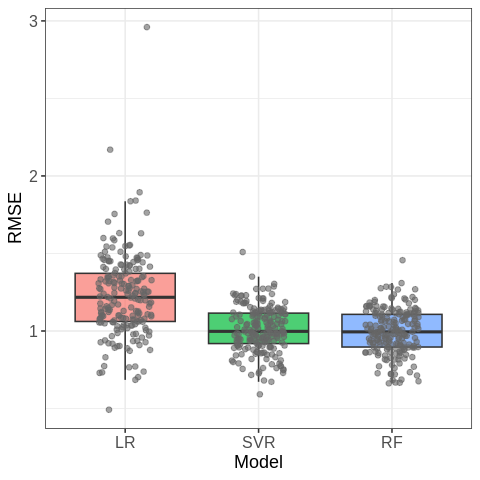

In [ ]:
%%R
# test 2
evaluate_models_cv(abmat_filtered, enmat_p_filtered, 1, metric = "rmse")

In [ ]:
%%R
## To group species with the same presence/absence pattern into one group,
##set grouping to 1 and specify a number between 0 and 1 for grouping_th.
## If 0, only species with the same presence/absence pattern will be grouped together.
#list[ocmat, abmat, enmat, samplelabel, specieslabel, factorlabel] <-
#  Formatting(baseabtable, basemetadata, normalize=1, parameters=c(0.01, 0.05, 0.95, 0.), grouping=1, grouping_th=0.)
#
#enmat_p <- data.frame(FAST_score = as.numeric(enmat[, 27]) ** 0.5, PPI = as.numeric(enmat[, 790]))
#rownames(enmat_p) <- samplelabel
#
#rows_to_keep <- !is.na(enmat_p[, 1]) & enmat_p[, 2] != 1
#
## remove the corresponding columns from data matrices
#enmat_p_filtered <- enmat_p[rows_to_keep, , drop = FALSE]
#enmat_fastscore_filtered <- as.matrix(enmat_p_filtered[, 1, drop = FALSE])
#ocmat_filtered <- ocmat[rows_to_keep, , drop = FALSE]
#abmat_filtered <- abmat[rows_to_keep, , drop = FALSE]
#samplelabel_filtered <- samplelabel[rows_to_keep]

NULL


In [ ]:
%%R

cv_ela_evaluate <- function(ocmat, enmat, method = c("correlation", "rmse", "rsq")) {
  # Ensure reproducible random folds (you can change the seed value as needed)
  set.seed(123)

  # Determine number of samples
  n <- nrow(ocmat)
  if (n != nrow(enmat)) {
    stop("ocmat and enmat must have the same number of rows")
  }

  # If enmat is a matrix (possibly with one column), convert to numeric vector of outputs
  actual_values <- as.numeric(enmat)

  # Setup for k-fold CV repeated n times
  nfolds <- 10 #k
  nrepeats <- 20 #n

  # Initialize vector to collect correlation values
  metric_values <- numeric(nfolds * nrepeats)
  index <- 1  # index for storing correlation results

  # Repeated cross-validation
  for (rep in 1:nrepeats) {
    # Randomly assign each sample to one of k folds
    # (replicate fold IDs 1:k across all samples, then shuffle)
    fold_ids <- sample(rep(1:nfolds, length.out = n))

    # Perform k-fold CV for this repeat
    for (fold in 1:nfolds) {
      # Split into training and testing indices
      test_idx  <- which(fold_ids == fold)
      train_idx <- setdiff(seq_len(n), test_idx)

      # Subset training and testing data
      train_oc <- ocmat[train_idx, , drop = FALSE]
      train_en <- actual_values[train_idx]
      test_oc  <- ocmat[test_idx, , drop = FALSE]
      test_en  <- actual_values[test_idx]

      # Train the model with Simulated Annealing on the training data
      # (using fixed internal parameters totalit, lambda, we)
      sa_result <- runSA(train_oc, train_en, rep = 32, threads=32,
                         getall=FALSE,intv=200,totalit=9600,lambda = 3.8, we = 1e-5, reporting=FALSE)####

      # Extract the model parameters from the SA result
      list[he0,je0,ge0,hge0] <- sa2params(sa_result,0)
      list[he1,je1,ge1,hge1] <- sa2params(sa_result,1)

      # Predict energy values for the test data using the Energy function
      # (assuming Energy can take the test input and parameters to compute predictions)
      predicted <- apply(test_oc, 1, function(x) Energy(x, hge1, je1) - Energy(x, he0,je0))

      # Calculate Pearson correlation between predicted and actual test outputs
      metric_val <- switch(method,
        correlation = - cor(predicted, test_en, method = "spearman"),
        rmse = sqrt(mean((predicted - test_en)^2)),
        rsq = {
          ss_res <- sum((predicted - test_en)^2)
          ss_tot <- sum((test_en - mean(test_en))^2)
          1 - ss_res / ss_tot
        }
      )

      # Store the correlation result
      metric_values[index] <- metric_val
      index <- index + 1
    }
  }

  # Create a data frame with Method and MetricValue columns
  results_df <- data.frame(
    Method      = rep("ELA", length(metric_values)),
    MetricValue = metric_values,
    stringsAsFactors = FALSE  # keep Method as character, not factor
  )

  return(results_df)
}

cv_cor_evaluate <- function(ocmat, abmat, enmat, method = c("correlation", "rmse", "rsq")) {
  # Ensure reproducible random folds (you can change the seed value as needed)
  set.seed(123)

  # Determine number of samples
  n <- nrow(ocmat)
  if (n != nrow(enmat)) {
    stop("ocmat and enmat must have the same number of rows")
  }

  # If enmat is a matrix (possibly with one column), convert to numeric vector of outputs
  actual_values <- as.numeric(enmat)

  # Setup for k-fold CV repeated n times
  nfolds <- 10 #k
  nrepeats <- 20 #n

  # Initialize vector to collect correlation values
  metric_values <- numeric(nfolds * nrepeats)
  index <- 1  # index for storing correlation results

  # Repeated cross-validation
  for (rep in 1:nrepeats) {
    # Randomly assign each sample to one of k folds
    # (replicate fold IDs 1:k across all samples, then shuffle)
    fold_ids <- sample(rep(1:nfolds, length.out = n))

    # Perform k-fold CV for this repeat
    for (fold in 1:nfolds) {
      # Split into training and testing indices
      test_idx  <- which(fold_ids == fold)
      train_idx <- setdiff(seq_len(n), test_idx)

      # Subset training and testing data
      train_oc <- ocmat[train_idx, , drop = FALSE]
      train_ab <<- abmat[train_idx, , drop = FALSE]
      train_en <<- actual_values[train_idx]
      test_oc  <- ocmat[test_idx, , drop = FALSE]
      test_ab <<- abmat[test_idx, , drop = FALSE]
      test_en  <- actual_values[test_idx]

      # Train the model with Simulated Annealing on the training data
      # (using fixed internal parameters totalit, lambda, we)
      rho <- numeric(ncol(train_ab))
      for(i in seq_along(rho)) {
        xi <- train_ab[,i]
        test <- suppressWarnings(cor.test(xi, train_en, method="spearman"))
        rho[i] <- if(!is.null(test$estimate)) test$estimate else NA
      }
      correlation_table <<- data.frame(
        Taxon = colnames(train_ab),
        SpearmanRho = rho,
        stringsAsFactors = FALSE
      )

      # Extract the model parameters from the SA result
      gcor <<- correlation_table$SpearmanRho

      # Predict energy values for the test data using the Energy function
      # (assuming Energy can take the test input and parameters to compute predictions)
      predicted <- apply(test_oc, 1, function(x) gcor %*% x)

      # Calculate Spearman correlation between predicted and actual test outputs
      metric_val <- switch(method,
        correlation = cor(predicted, test_en, method = "spearman"),
        rmse = sqrt(mean((predicted - test_en)^2)),
        rsq = {
          ss_res <- sum((predicted - test_en)^2)
          ss_tot <- sum((test_en - mean(test_en))^2)
          1 - ss_res / ss_tot
        }
      )

      # Store the correlation result
      metric_values[index] <- metric_val
      index <- index + 1
    }
  }

  # Create a data frame with Method and MetricValue columns
  results_df <- data.frame(
    Method      = rep("COR", length(metric_values)),
    MetricValue = metric_values,
    stringsAsFactors = FALSE  # keep Method as character, not factor
  )

  return(results_df)
}

In [ ]:
%%R
# evaluation of ela based prediction
ela_score <- cv_ela_evaluate(ocmat_filtered, as.matrix(enmat_fastscore_filtered), "correlation")

In [ ]:
%%R
# use simple sum of Spearman correlation as a reference
ela_score_ref <- cv_cor_evaluate(ocmat_filtered, abmat_filtered, as.matrix(enmat_fastscore_filtered), "correlation")
ela_score_ref_oc <- cv_cor_evaluate(ocmat_filtered, ocmat_filtered, as.matrix(enmat_fastscore_filtered), "correlation")

In [ ]:
%%R
combined_score <- rbind(ela_score_ref, ela_score)
combined_score_oc <- rbind(ela_score_ref_oc, ela_score)

In [ ]:
#%%R
#p <- evaluate_models_cv(ocmat_filtered, enmat_p_filtered, 1, metric = "correlation", external_scores=combined_score_oc)
#ggsave("evaluate_models_cv_oc.png", plot = p$plot, width = 6.5, height = 6.5, dpi = 300)

In [ ]:
#display(Image("evaluate_models_cv_oc.png", width=400))

In [ ]:
%%R
# comparison to machine learning methods
p <- evaluate_models_cv(abmat_filtered, enmat_p_filtered, 1, metric = "correlation", external_scores=combined_score)
ggsave(file.path(out, "evaluate_models_cv.png"), plot = p$plot, width = 6.5, height = 6.5, dpi = 600)
ggsave(file.path(out, "evaluate_models_cv.eps"), plot = p$plot, device = "eps", width = 6.5, height = 6.5)
ggsave(file.path(out, "evaluate_models_cv.pdf"), plot = p$plot, device = grDevices::cairo_pdf, width = 6.5, height = 6.5, bg="white")

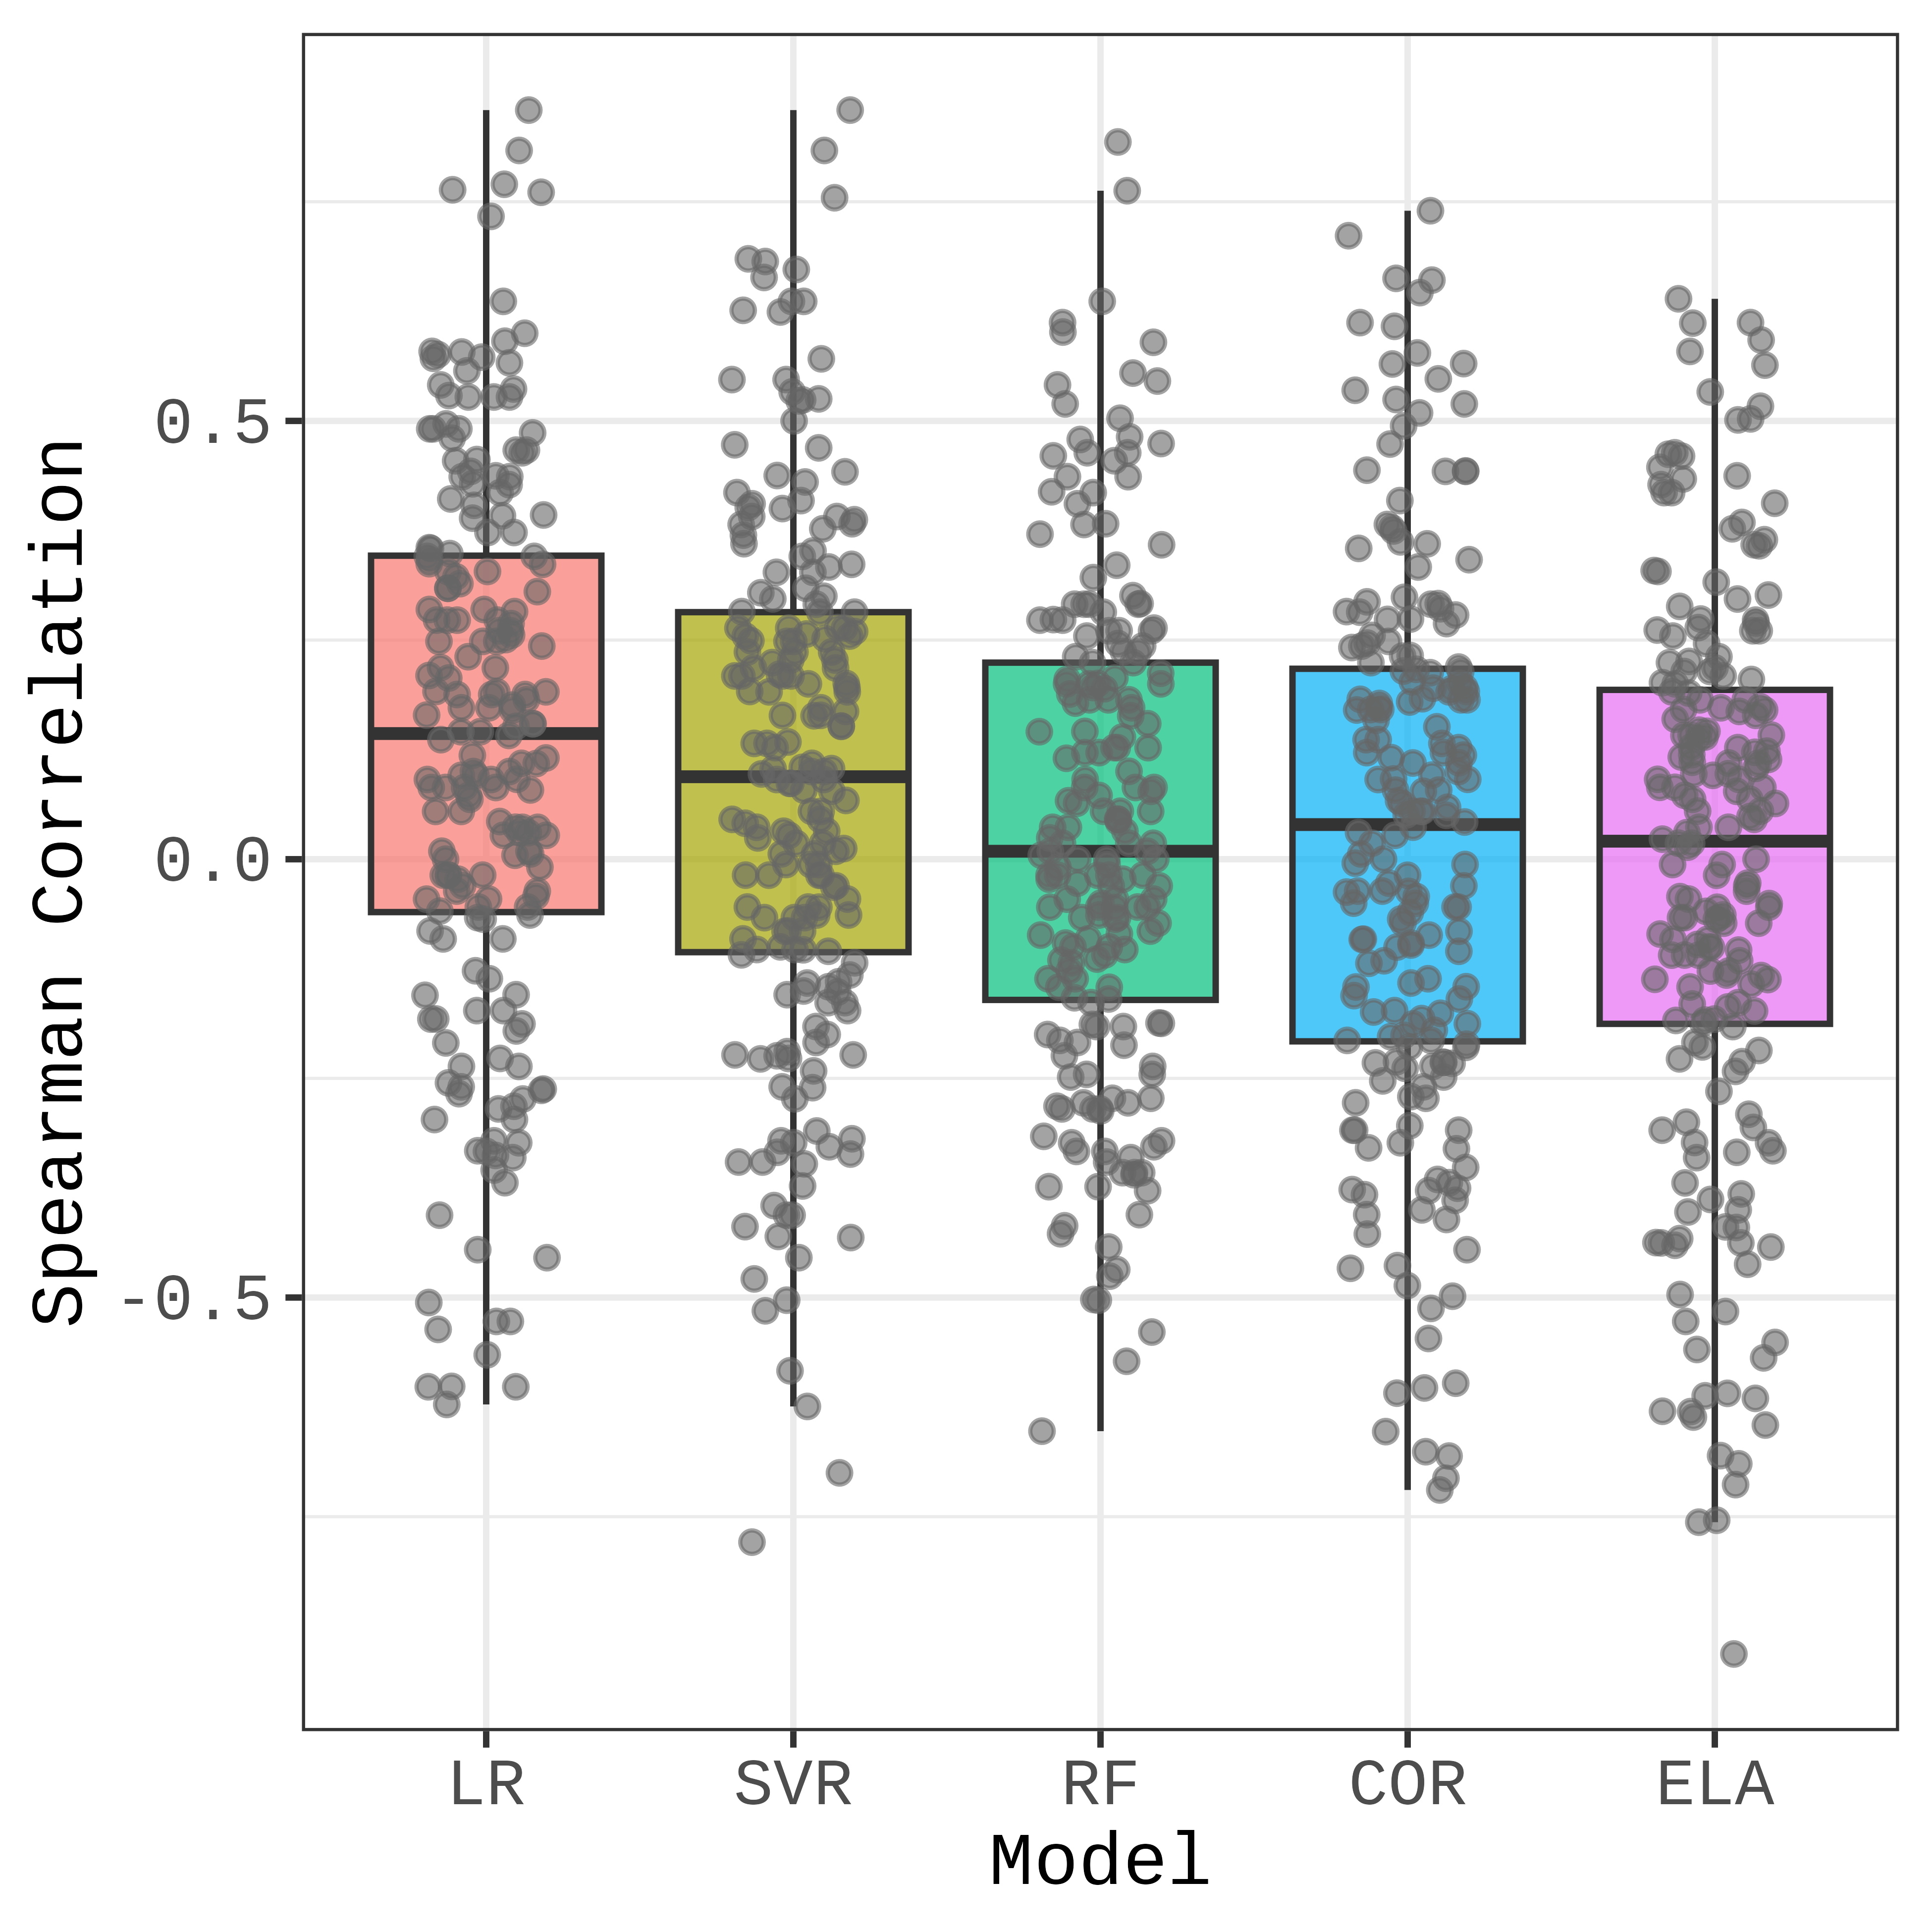

In [ ]:
display(Image(out+"evaluate_models_cv.png", width=400))

===================================================================================

FASK-based Causal Analysis
- Run the following two cells. This will save the information needed for the next steps.
- Next, run the following cell to install openjdk-21-jdk.
- Once these steps are complete, restart the runtime. This will set up the environment for causal analysis. Please note that this operation will discard any local variables set so far.
- The cells below can be run independently of the other cells in this notebook.
- The results are saved to the current folder in Google Colab, so please download and use them as needed.

In [ ]:
%%R
mem <- membership_from_ssd(ssd_grouping)
rownames(mem) <- specieslabel
tmem <- t(mem)

In [ ]:
%%R
abmat.df <- as.data.frame(abmat_filtered)
write.csv(abmat.df, "abundance.csv", row.names = TRUE)
write.csv(enmat_fastscore_filtered, "fast_score.csv", row.names = TRUE)
write.csv(tmem, "community_membership.csv", row.names = TRUE)

In [ ]:
!apt-get update -y
!apt-get install -y openjdk-21-jdk

Get:1 https://cli.github.com/packages stable InRelease [4,685 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [112 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.8 MB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [44.3 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:14 ht

In [ ]:
## RESTART SESSION ##

In [ ]:
import pandas as pd
import numpy as np
import subprocess
import glob
import os
import re
from scipy.stats import gmean

In [ ]:
membership = pd.read_csv("community_membership.csv", index_col=0)
membership

,Prevotellaceae_NK3B31_group,Enterococcus,Incertae_Sedis,Lactobacillus,Dialister,Clostridium_sensu_stricto_1,Erysipelatoclostridium,Ruminococcus,Escherichia.Shigella,Megamonas,...,Collinsella,Dorea,Lachnoclostridium,Parabacteroides,Lachnospiraceae.uc,Lachnospiraceae.uncultured,Fusicatenibacter,Bifidobacterium,Ruminococcus._torques_group,Blautia
C1,0,0,0,0,0,0,0,1,0,0,...,1,1,1,1,1,0,1,1,1,1
C2,0,0,0,0,0,0,0,0,0,1,...,1,1,1,1,0,0,1,1,1,1
C3,0,0,0,0,0,0,1,0,1,0,...,0,0,1,1,1,1,0,0,0,1
C4,0,0,0,0,0,0,0,0,1,0,...,1,0,1,1,0,1,0,1,0,1


In [ ]:
abundance = pd.read_csv("abundance.csv", index_col=0)          # samples × taxa
fast = pd.read_csv("fast_score.csv", index_col=0)  # samples
membership = pd.read_csv("community_membership.csv", index_col=0)  # communities × taxa


In [ ]:
def clr_transform(x, eps=1e-6):
    x = x + eps
    return np.log(x / gmean(x))

In [ ]:
JAR = "causal-cmd-7.6.8-jar-with-dependencies.jar"

import os, glob, subprocess, tempfile

def run_fask(df):
    df = df.copy()
    df.columns = [c.replace(".", "_") for c in df.columns]
    df.to_csv("data_for_tetrad.csv", index=False)

    # 一時ディレクトリを作成
    outdir = tempfile.mkdtemp(prefix="fask_")

    subprocess.run([
        "java", "-jar", JAR,
        "--algorithm", "fask",
        "--dataset", "data_for_tetrad.csv",
        "--data-type", "continuous",
        "--delimiter", "comma",
        "--score", "sem-bic-score",
        "--alpha", "0.05",
        "--faskDelta", "0.2",
        "--skewEdgeThreshold", "0.05",
        "--out", outdir
    ], check=True)

    txt_files = glob.glob(os.path.join(outdir, "fask_*_out.txt"))
    if len(txt_files) != 1:
        raise RuntimeError(f"Expected 1 fask output, got {txt_files}")

    return txt_files[0]

import re

def parse_fask_result(txt_path):
    edges = []
    with open(txt_path) as f:
        lines = f.readlines()

    edge_section = False
    for line in lines:
        line = line.strip()

        if line.startswith("Graph Edges"):
            edge_section = True
            continue

        if edge_section:
            if not line or line.startswith("===="):
                break

            # 例: "1. A --> B"
            m = re.match(r"\d+\.\s*(\S+)\s*-->\s*(\S+)", line)
            if m:
                edges.append((m.group(1), m.group(2)))

    return edges

In [ ]:
def community_index(abundance_df, member_taxa):
    in_group = abundance_df[member_taxa].sum(axis=1)
    out_group = abundance_df.drop(columns=member_taxa).sum(axis=1)
    return in_group / (in_group + out_group + 1e-9)

def community_index_excluding_taxon(abundance_df, member_taxa, exclude_taxon):
    in_taxa = [t for t in member_taxa if t != exclude_taxon]
    if len(in_taxa) == 0:
        return None
    in_group = abundance_df[in_taxa].sum(axis=1)
    out_group = abundance_df.drop(columns=in_taxa).sum(axis=1)
    return in_group / (in_group + out_group + 1e-9)

from sklearn.preprocessing import StandardScaler

def zscore_df(df):
    scaler = StandardScaler()
    df[df.columns] = scaler.fit_transform(df.values)
    return df

In [ ]:
# unremove
results = []

for comm in membership.index:
    print(f"\n=== Community: {comm} ===")
    member_taxa = membership.columns[membership.loc[comm] == 1].tolist()

    # community index（※この段階ではまだ taxon を除いていない）
    ci = community_index(abundance, member_taxa)

    for taxon in member_taxa:
        # CLR 変換（compositional preprocessing）
        x = clr_transform(abundance[taxon])

        df = pd.DataFrame({
            "FAST_score": fast["FAST_score"],
            taxon: x,
            "community_index": ci
        }).dropna()

        # 正規化
        df = zscore_df(df)

        try:
            txt = run_fask(df)
            edges = parse_fask_result(txt)
            print(edges)
        except Exception:
            edges = []

        direction = {
            "FAST_score": "-",
            "community_index": "-"
        }

        taxon_safe = taxon.replace(".", "_")

        for src, dst in edges:
            if src == taxon_safe and dst in direction:
                direction[dst] = "->"
            if dst == taxon_safe and src in direction:
                direction[src] = "<-"

        results.append({
            "community": comm,
            "taxon": taxon,
            "FAST_score": direction["FAST_score"],
            "community_index": direction["community_index"]
        })



=== Community: C1 ===

=== Community: C2 ===

=== Community: C3 ===

=== Community: C4 ===


In [ ]:
df = pd.DataFrame(results)
df_C1 = df[df["community"] == "C1"].copy()
print(df_C1)

   community                        taxon FAST_score community_index
0         C1                 Ruminococcus          -               -
1         C1                 Agathobacter          -               -
2         C1                   Prevotella          -               -
3         C1                    Roseburia          -               -
4         C1              Subdoligranulum          -               -
5         C1                    Alistipes          -               -
6         C1                   Sutterella          -               -
7         C1             Faecalibacterium          -               -
8         C1        Phascolarctobacterium          -               -
9         C1    Eubacterium._hallii_group          -               -
10        C1                 Anaerostipes          -               -
11        C1                  Collinsella          -               -
12        C1                        Dorea          -               -
13        C1            Lachnoclos

In [ ]:
df = pd.DataFrame(results)
df_C3 = df[df["community"] == "C3"].copy()
print(df_C3)

   community                       taxon FAST_score community_index
39        C3      Erysipelatoclostridium          -               -
40        C3        Escherichia.Shigella          -               -
41        C3             Intestinibacter          -               -
42        C3                 Veillonella          -               -
43        C3               Streptococcus          -               -
44        C3               Fusobacterium          -               -
45        C3       Enterobacteriaceae.uc          -               -
46        C3  Ruminococcus._gnavus_group          -               -
47        C3           Lachnoclostridium          -               -
48        C3             Parabacteroides          -               -
49        C3          Lachnospiraceae.uc          -               -
50        C3  Lachnospiraceae.uncultured          -               -
51        C3                     Blautia          -               -


In [ ]:
df = pd.DataFrame(results)
df_C2 = df[df["community"] == "C2"].copy()
print(df_C2)

   community                        taxon FAST_score community_index
20        C2                    Megamonas          -               -
21        C2                  Megasphaera          -               -
22        C2                 Agathobacter          -               -
23        C2                   Prevotella          -               -
24        C2              Subdoligranulum          -               -
25        C2                    Alistipes          -               -
26        C2                   Sutterella          -               -
27        C2             Faecalibacterium          -               -
28        C2        Phascolarctobacterium          -               -
29        C2    Eubacterium._hallii_group          -               -
30        C2                 Anaerostipes          -               -
31        C2                  Collinsella          -               -
32        C2                        Dorea          -               -
33        C2            Lachnoclos

In [ ]:
df = pd.DataFrame(results)
df_C4 = df[df["community"] == "C4"].copy()
print(df_C4)

   community                       taxon FAST_score community_index FAST-Ci
52        C4        Escherichia.Shigella          -               -       -
53        C4                 Veillonella          -               -       -
54        C4               Streptococcus          -               -       -
55        C4               Fusobacterium          -               -       -
56        C4       Enterobacteriaceae.uc          -               -       -
57        C4  Ruminococcus._gnavus_group          -               -       -
58        C4                 Collinsella          -               -       -
59        C4           Lachnoclostridium          -               -       -
60        C4             Parabacteroides          -               -       -
61        C4  Lachnospiraceae.uncultured          -               -       -
62        C4             Bifidobacterium          -               -       -
63        C4                     Blautia          -               -       -


In [ ]:
# removed
results = []

def summarize_flag(flag_set):
    if flag_set == {"->"}:
        return "->"
    if flag_set == {"<-"}:
        return "<-"
    if flag_set == {"->", "<-"}:
        return "<->"
    return "-"

for comm in membership.index:
    print(f"\n=== Community: {comm} ===")
    member_taxa = membership.columns[membership.loc[comm] == 1].tolist()

    for taxon in member_taxa:

        # community index（focal taxon を除外）
        ci = community_index_excluding_taxon(
            abundance,
            member_taxa,
            exclude_taxon=taxon
        )
        if ci is None:
            continue

        # CLR transform
        x = clr_transform(abundance[taxon])

        # DataFrame 作成
        df = pd.DataFrame({
            "FAST_score": fast["FAST_score"],
            taxon: x,
            "community_index": ci
        }).dropna()

        # 正規化
        df = zscore_df(df)

        try:
            txt = run_fask(df)
            edges = parse_fask_result(txt)
            print(edges)
        except Exception:
            edges = []

        # --- フラグ初期化（3ペア） ---
        flags = {
            "taxon_FAST": set(),
            "taxon_Ci": set(),
            "FAST_Ci": set()
        }

        taxon_safe = taxon.replace(".", "_")

        # --- edges を走査してフラグを立てる ---
        for src, dst in edges:

            # taxon ↔ FAST_score
            if src == taxon_safe and dst == "FAST_score":
                flags["taxon_FAST"].add("->")
            if src == "FAST_score" and dst == taxon_safe:
                flags["taxon_FAST"].add("<-")

            # taxon ↔ community_index
            if src == taxon_safe and dst == "community_index":
                flags["taxon_Ci"].add("->")
            if src == "community_index" and dst == taxon_safe:
                flags["taxon_Ci"].add("<-")

            # FAST_score ↔ community_index
            if src == "FAST_score" and dst == "community_index":
                flags["FAST_Ci"].add("->")
            if src == "community_index" and dst == "FAST_score":
                flags["FAST_Ci"].add("<-")

        # --- 集約 ---
        direction = {
            "FAST_score": summarize_flag(flags["taxon_FAST"]),
            "community_index": summarize_flag(flags["taxon_Ci"]),
            "FAST-Ci": summarize_flag(flags["FAST_Ci"])
        }

        results.append({
            "community": comm,
            "taxon": taxon,
            "FAST_score": direction["FAST_score"],
            "community_index": direction["community_index"],
            "FAST-Ci": direction["FAST-Ci"]
        })



=== Community: C1 ===

=== Community: C2 ===

=== Community: C3 ===

=== Community: C4 ===


In [ ]:
df = pd.DataFrame(results)
df_C6 = df[df["community"] == "C6"].copy()
print(df_C6)

Empty DataFrame
Columns: [community, taxon, FAST_score, community_index, FAST-Ci]
Index: []


In [ ]:
df = pd.DataFrame(results)
df_C3 = df[df["community"] == "C3"].copy()
print(df_C3)

   community                       taxon FAST_score community_index FAST-Ci
39        C3      Erysipelatoclostridium          -               -       -
40        C3        Escherichia.Shigella          -               -       -
41        C3             Intestinibacter          -               -       -
42        C3                 Veillonella          -               -       -
43        C3               Streptococcus          -               -       -
44        C3               Fusobacterium          -               -       -
45        C3       Enterobacteriaceae.uc          -               -       -
46        C3  Ruminococcus._gnavus_group          -               -       -
47        C3           Lachnoclostridium          -               -       -
48        C3             Parabacteroides          -               -       -
49        C3          Lachnospiraceae.uc          -               -       -
50        C3  Lachnospiraceae.uncultured          -               -       -
51        C3

In [ ]:
df = pd.DataFrame(results)
df_C2 = df[df["community"] == "C2"].copy()
print(df_C2)

   community                        taxon FAST_score community_index FAST-Ci
20        C2                    Megamonas          -               -       -
21        C2                  Megasphaera          -               -       -
22        C2                 Agathobacter          -               -       -
23        C2                   Prevotella          -               -       -
24        C2              Subdoligranulum          -               -       -
25        C2                    Alistipes          -               -       -
26        C2                   Sutterella          -               -       -
27        C2             Faecalibacterium          -               -       -
28        C2        Phascolarctobacterium          -               -       -
29        C2    Eubacterium._hallii_group          -               -       -
30        C2                 Anaerostipes          -               -       -
31        C2                  Collinsella          -               -       -

In [ ]:
print(df)

   community                       taxon FAST_score community_index FAST-Ci
0         C1                Ruminococcus          -               -       -
1         C1                Agathobacter          -               -       -
2         C1                  Prevotella          -               -       -
3         C1                   Roseburia          -               -       -
4         C1             Subdoligranulum          -               -       -
..       ...                         ...        ...             ...     ...
59        C4           Lachnoclostridium          -               -       -
60        C4             Parabacteroides          -               -       -
61        C4  Lachnospiraceae.uncultured          -               -       -
62        C4             Bifidobacterium          -               -       -
63        C4                     Blautia          -               -       -

[64 rows x 5 columns]


In [ ]:
results_df = pd.DataFrame(results)
results_df.to_csv(out+"fask_summary.csv", index=False)

======================================================